# **Algiers in 24 Hours - Tourist Optimizer**

---


# **SECTION 0 - Imports and Global Configuration**

This section initializes the execution environment, defines global constraints for the optimization problem, and imports necessary libraries for data processing, mathematical modeling, and visualization.

### **Global Constants**
- `TMAX_FULL`: Maximum time budget for a full day (480 minutes / 8 hours).
- `TMAX_HALF`: Maximum time budget for a half-day trip (240 minutes / 4 hours).
- `STARTING_TIME`: The default starting time of the tour (480 minutes, representing 08:00 AM).

### **Library Breakdown**
- **Data Handling**: `pandas` and `numpy` for dataset manipulation and matrix operations.
- **Optimization Utilities**: `random`, `math`, `typing` , `time`,and `itertools` for stochastic processes and permutations.
- **Visualization**: `matplotlib` and `seaborn` for performance analysis and itinerary plotting.
- **Domain Logic**: Custom utilities for loading landmarks, hotels, and the pre-computed time-distance matrix.

In [ ]:
TMAX_FULL = 480
TMAX_HALF = 240
STARTING_TIME = 480   # 8 am 

## Imports

In [8]:
from pathlib import Path
import random, time, math, os , itertools , sys
from typing import List, Dict, Any,  Tuple, Set, Union, Literal

import pandas as pd
import numpy as np
import seaborn as sns

from utils.data_loader import get_landmarks, get_hotels, get_time_matrix

import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')


import csv
from collections import Counter
import random
import json
import requests
from requests import status_codes


In [4]:
%pip install matplotlib seaborn pandas numpy
%pip install nbdime
!nbdime config-git --enable

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


---
# **SECTION 1 - Data Collection**


## 1.1 - Landmarks Dataset



We gathered - clean - data about  **+60 attractions/landmarks in Algiers**, including the following attributes:  
* __Attraction/landmark name.__
* __Description (__ short description __)__  
* __Type of attraction/landmark (__ Monument, Park/Garden, Historical site ... etc __)__  
* __Rating (/10)__ 
* __GPS coordinates (__ longitude, latitude __)__
* __Estimated visit duration (__ in minutes  __)__
* __Opening Hours__
* __Images__



In [5]:
# path to the landmarks CSV file
LANDMARK_PATH = "./dataset/landmarks/Algiers_Landmarks.csv"

with open(LANDMARK_PATH, newline='', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))

ratings = [float(r['Rating']) for r in rows]
types = Counter(r['Type'] for r in rows)


print(f"Total landmarks : {len(rows)}")
print(f"Average rating  : {sum(ratings)/len(ratings):.2f}")
print(f"Highest rating  : {max(ratings)}")
print(f"Lowest rating   : {min(ratings)}")
print(f"Unique types    : {len(types)}")


print("\nCount by type: ")
for t, c in types.most_common():
    print(f"  {t:<25} {c}")


print("\nTop 10 landmarks: ")
for i, r in enumerate(sorted(rows, key=lambda x: float(x['Rating']), reverse=True)[:10], 1):
    print(f"  {i:>2}. {r['Name']} - {r['Rating']}")

print("\nBottom 5 landmarks: ")
for i, r in enumerate(sorted(rows, key=lambda x: float(x['Rating']))[:5], 1):
    print(f"  {i}. {r['Name']} - {r['Rating']}")

Total landmarks : 66
Average rating  : 7.42
Highest rating  : 9.7
Lowest rating   : 3.8
Unique types    : 11

Count by type: 
  Cultural Center & Event Venue 11
  Museum                    9
  Mosque                    8
  Public Square             7
  Park                      7
  Historical Site           6
  Nature                    5
  Beach                     5
  Shopping/Mall             4
  Monument                  2
  Cathedral                 2

Top 10 landmarks: 
   1. Great Mosque - 9.7
   2. Botanical Garden Hamma - 9.6
   3. Martyrs' Memorial - 9.5
   4. Casbah - 9.5
   5. La Grande Poste - 9.3
   6. Palais des Raïs - 9.2
   7. Garden City Mall - 9.2
   8. Notre Dame d'Afrique - 9.1
   9. Ketchaoua Mosque - 9.1
  10. National Museum of Fine Arts - 9

Bottom 5 landmarks: 
  1. Monument to the Dead - 3.8
  2. Zeralda Beach - 4
  3. Dounia Park - 4
  4. Ben Aknoun Zoo - 4.2
  5. El Kettani Beach - 4.5


## 1.2 - Hotels Dataset

We gathered a dataset of __+180 hotels__ across Algiers province, collected from Google Maps.

In [6]:
# path to 'Algiers_hotels.csv'
HOTELS_PATH = "./dataset/hotels/Algiers_hotels.csv"

with open(HOTELS_PATH, newline='', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))
 
print(f"Total hotels: {len(rows)} hotel(s).")

# Select 7 random hotels
num_hotels_to_print = min(7, len(rows))
random_hotels = random.sample(rows, num_hotels_to_print)

print(f"\n{num_hotels_to_print} hotels:")
for i, hotel in enumerate(random_hotels, 1):
    print(f"{i}. {hotel['name']}")

Total hotels: 181 hotel(s).

7 hotels:
1. Hotel Amirouche
2. Kyriad Prestige Le Patio
3. El Forssane Hotel
4. Résidence Marina
5. Hôtel El Sahel
6. Sheraton Club des Pins Resort
7. Hôtel Amsterdam



## 1.3 - Time Matrix

Generated via the OSRM public API (router.project-osrm.org) using the driving profile.

- `time_matrix.npy` — (247 × 247) numpy array of travel times in minutes
- `time_matrix_named.csv` — same matrix with landmark/hotel names as row and column headers

Rows and columns are ordered: landmarks first (83), hotels second (184).

**Note:** The public OSRM API enforces a 100-coordinate limit per request,
so the matrix is built in batches. Results reflect road-network driving time
and may not account for real-time traffic.


In [21]:

landmarks = pd.read_csv(LANDMARK_PATH)
hotels    = pd.read_csv(HOTELS_PATH)

names = list(landmarks["Name"]) + list(hotels["name"])

all_coords = (
    [(row["Longitude"], row["Latitude"]) for _, row in landmarks.iterrows()] +
    [(row["longitude"], row["latitude"]) for _, row in hotels.iterrows()]
)

OSRM_BASE = "http://router.project-osrm.org/table/v1/driving"
BATCH     = 100  # public OSRM hard limit

n = len(all_coords)
time_matrix = np.zeros((n, n), dtype=float)

for i in range(0, n, BATCH):
    for j in range(0, n, BATCH):
        src_slice = all_coords[i:i+BATCH]
        dst_slice = all_coords[j:j+BATCH]

        combined = src_slice + dst_slice
        coords_str = ";".join(f"{lon},{lat}" for lon, lat in combined)

        sources = ";".join(str(k) for k in range(len(src_slice)))
        destinations = ";".join(str(k + len(src_slice)) for k in range(len(dst_slice)))

        r = requests.get(
            f"{OSRM_BASE}/{coords_str}",
            params={"annotations": "duration", "sources": sources, "destinations": destinations},
            timeout=120
        )
        r.raise_for_status()
        block = np.array(r.json()["durations"], dtype=float) / 60  # seconds → minutes

        time_matrix[i:i+len(src_slice), j:j+len(dst_slice)] = block

# Store output files in ./utils directory
np.save("./utils/time_matrix.npy", time_matrix)
df = pd.DataFrame(time_matrix.round(1), index=names, columns=names)
df.to_csv("./utils/time_matrix_named.csv")

# Confirmation Message 
print(f"Done. Matrix shape: {time_matrix.shape}")
print(f"Files saved in ./utils/ directory")

Done. Matrix shape: (247, 247)
Files saved in ./utils/ directory


The CSV file `time_matrix_named.csv` is converted into a JSON file `time_matrix.json`

In [6]:
# load the existing matrix CSV
df = pd.read_csv("./utils/time_matrix_named.csv", index_col=0)

# convert to nested dict {start: {end: minutes}}
time_dict = {}
for start in df.index:
    time_dict[start] = {}
    for end in df.columns:
        time_dict[start][end] = round(float(df.loc[start, end]), 1)

# save as JSON
with open("./utils/time_matrix.json", "w", encoding="utf-8") as f:
    json.dump(time_dict, f, ensure_ascii=False, indent=2)

# Confirmation message
print("Done. Saved to ./utils/time_matrix.json")

Done. Saved to ./utils/time_matrix.json


---
# **SECTION 2 -  Core Classes**




To model the tourism ecosystem of Algiers, we use an Object-Oriented approach. These classes serve as the data structures for all search and optimization algorithms.


### **2.1 - Landmark Class**
The `Landmark` object represents a point of interest (POI). It encapsulates:
- **Spatial Data**: Longitude and latitude for distance calculations.
- **Temporal Constraints**: `opening_hours` (binary schedule) and `visit_duration`.
- **Optimization Weight**: `interest_score` used as the primary objective function to maximize.



In [5]:
class Landmark:
    """
    Represents a single tourist landmark or attraction.

    Attributes:
        id (int): A unique numerical identifier for the landmark.
        name (str): The name of the landmark.
        lon (float): Longitude coordinate.
        lat (float): Latitude coordinate.
        interest_score (float): The rating or user interest score.
        opening_hours (dict[str, list[int]]): A dictionary mapping days of the week
            (e.g., 'Monday') to a list of 24 integers representing hours.
            1 means open, 0 means closed. Example: {'Monday': [0,0,...,1,1,0]}
        visit_duration (int): Estimated time spent at the landmark in minutes.
        landmark_type (str): The category of the landmark (e.g., 'Museum', 'Park').
    """

    def __init__(
        self,
        id: int,
        name: str,
        lon: float,
        lat: float,
        interest_score: float,
        opening_hours: dict[str, list[int]],
        visit_duration: int,
        landmark_type: str,
    ):

        self.id = id
        self.name = name
        self.lon = lon
        self.lat = lat
        self.interest_score = interest_score
        self.opening_hours = opening_hours
        self.visit_duration = visit_duration
        self.landmark_type = landmark_type

    # check this , since we will be working with minutes and time matrix is in minutes we wont be doing conversion from min to hours

    def is_open(self, day: str, arrival_minutes: float) -> bool:
        """
        Checks if the landmark is open for the entire visit duration.
    
        Args:
            day(str): Day abbreviation e.g. 'mon', 'tue'
            arrival_minutes (float): Arrival time in minutes from midnight
                                    e.g. 540 = 09:00, 545.7 = 09:05:42

        Returns:
            bool: True if landmark is open for every hour slot of the visit
        """
        opening = self.opening_hours[day]
       
        if opening is None:
            print("no openning hour provided")
            return False

        finish_minutes = arrival_minutes + self.visit_duration

        # which hour slot do we arrive in?
        arrival_hour = int(arrival_minutes // 60)

        # which hour slot are we still INSIDE at the end?
        # subtract 1 so that finishing exactly on the hour (e.g. 600 = 10:00)
        # does not count as being inside the next slot (hour 10)
        finish_hour = int((finish_minutes - 1) // 60)

        for hour in range(arrival_hour, finish_hour + 1):
            if opening[hour % 24] == 0:
                
                return False
        
        return True


### **2.2 - Hotel Class**
The `Hotel` object acts as the **Anchor Point** for every itinerary. In this problem formulation, the hotel serves as both the `Initial State` (Start) and the `Goal Condition` (Return), ensuring the agent completes a circuit within the time budget.

In [6]:
#this class represent single hotel

class Hotel:
    """
    Single Hotel Object 

    Attributes:

        id : name of the hotel from the dataset
           
    """

    def __init__(self, name, lon, lat):
        self.id = name
        self.name = name
        self.lon = lon
        self.lat = lat

### **2.3 - Data Loader Fnuctions**

In [7]:

# .resolve() guarantees a full absolute path
_BASE_DIR = Path.cwd().parent.parent 

# Path to CSV files 
LANDMARKS_PATH = _BASE_DIR / "dataset" / "landmarks" / "Algiers_Landmarks.csv"
HOTELS_PATH = _BASE_DIR / "dataset" / "hotels" / "Algiers_hotels.csv"
TIME_MATRIX_PATH = _BASE_DIR / "utils" / "time_matrix.json" 

def get_landmarks(landmarks_path=LANDMARKS_PATH)->List[Landmark]:
    """
    Reads a CSV file containing landmark data, sets the first column as the index,
    and returns the data as a dictionary of dictionaries.

    Args:
        landmarks_path (str): Path to the landmarks CSV file.

    Returns:
        dict: Dictionary where each key is the value from the first column (index),
              and each value is another dictionary of column name -> value for that row.
    """
    df = pd.read_csv(landmarks_path)
    df['Hours'] = df['Hours'].apply(lambda x: json.loads(x.replace("'", '"')))  # Convert string to dict
    landmarks = []
    for idx, row in df.iterrows():
        landmark = Landmark(
            id=row['ID'],
            name=row['Name'],
            lon=row['Longitude'],
            lat=row['Latitude'],
            landmark_type=row['Type'],
            opening_hours=row['Hours'],
            visit_duration=row['EstimatedTime (min)'],
            interest_score=row['Rating']
        )
        landmarks.append(landmark)
       
    return landmarks

def get_hotels(hotels_path=HOTELS_PATH)->List[Hotel]:
    """
    Reads a CSV file containing hotel data, sets the first column as the index,
    and returns the data as a dictionary of dictionaries.

    Args:
        hotels_path (str): Path to the hotels CSV file.

    Returns:
        dict: Same structure as get_landmarks().
    """
    df = pd.read_csv(hotels_path)
    hotels = []
    for idx, row in df.iterrows():
        hotel = Hotel(
            name=row['name'],
            lon=row['longitude'],
            lat=row['latitude']
        )
        hotels.append(hotel)
    return hotels


def get_time_matrix(time_matrix_path=TIME_MATRIX_PATH):
    """
    Reads a JSON file containing a time matrix and returns it as a dictionary.

    Args:
        time_matrix_path (str): Path to the time matrix JSON file."""
    time_matrix = pd.read_json(time_matrix_path, orient='index').to_dict()
    return time_matrix


---
# **SECTION 3 -  Problem Formulation**

## **3.1 - State Representation**

### ***Informed Search***
 


Every moment in the search is captured as a 3-tuple:
 
```
state = (current_position, visited_landmarks, current_time)
```
 
| Field | Type | Example |
|-------|------|---------|
| `current_position` | `str` | `"Hotel Sofitel"` |
| `visited_landmarks` | `frozenset[str]` | `frozenset({"Casbah", "Martyrs Square"})` |
| `current_time` | `int` (minutes from midnight) | `600` = 10:00 AM |
 
> **Why `frozenset`?** It is immutable and hashable, making states safe to use as dictionary keys or in sets — essential for graph-search algorithms.

### ***Local Search***



Every moment in the search is captured as a complete itinerary (a sequence):

`state = [hotel, landmark_1, landmark_2, ..., landmark_k, hotel]`

| Field | Type | Example |
|-------|------|---------|
| `state_sequence` | `list[Node]` | `[Hotel_Aurassi, Casbah, Bardo_Museum, Hotel_Aurassi]` |

> **Why a full list?** Unlike Informed Search which builds a path step-by-step, Local Search operates on **complete candidate solutions**. The algorithm evaluates the entire tour and tries to improve it by tweaking the sequence.

### ***CSP***


 explanation and tuples of all the variable

In [47]:

class CSP:
    """
    Abstract CSP.

    Subclasses set:
        self.variables  : list of variable names
        self.domains    : dict  var → [values]
        self.neighbors  : dict  var → [vars that share a binary constraint]
    and override:
        constraint(Xi, vi, Xj, vj) → bool
    """

    def __init__(self):
        self.variables:    List           = []
        self.domains:      Dict[Any, List] = {}
        self.neighbors:    Dict[Any, List] = {}
        self.nassigns:     int             = 0
        self.curr_domains: Optional[Dict]  = None   
        
    def constraint(self, Xi, vi, Xj, vj) -> bool:
        raise NotImplementedError

    def assign(self, var, val, assignment: dict):
        assignment[var] = val
        self.nassigns += 1

    def unassign(self, var, assignment: dict):
        assignment.pop(var, None)

    def nconflicts(self, var, val, assignment: dict) -> int:
        """Number of neighbours whose current value conflicts with (var=val)."""
        return sum(
            1 for nb in self.neighbors[var]
            if nb in assignment
            and not self.constraint(var, val, nb, assignment[nb])
        )

    def support_pruning(self):
        """Copy domains into curr_domains on first call."""
        if self.curr_domains is None:
            self.curr_domains = {v: list(self.domains[v]) for v in self.variables}

    def suppose(self, var, value) -> List[Tuple]:
        """
        Restrict curr_domains[var] to [value].
        Returns the list of (var, pruned_val) pairs for later restore().
        """
        self.support_pruning()
        removals = [(var, a) for a in self.curr_domains[var] if a != value]
        self.curr_domains[var] = [value]
        return removals

    def prune(self, var, value, removals: Optional[List]):
        """Remove value from curr_domains[var]; record it in removals."""
        if value in self.curr_domains[var]:
            self.curr_domains[var].remove(value)
            if removals is not None:
                removals.append((var, value))

    def choices(self, var) -> List:
        """Live values for var (curr_domains if pruning is active)."""
        return (self.curr_domains if self.curr_domains else self.domains)[var]

    def restore(self, removals: List[Tuple]):
        """Undo pruning by putting values back into curr_domains."""
        for var, val in removals:
            self.curr_domains[var].append(val)


### ***Ant Colony System (ACS)***



Unlike standard search trees, ACS requires a **dual-state representation** to separate the single agent from the collective world.

**1. The Agent State (The Ant's Memory):**
`ant_state = (current_node, visited_landmarks, path_sequence, current_time)`

| Field | Type | Example |
|-------|------|---------|
| `current_node` | `Node Object` | `Casbah` |
| `visited_landmarks` | `set[str]` | `{"Casbah", "Martyrs Square"}` |
| `path_sequence` | `list[Node]` | `[Hotel_Aurassi, Casbah]` |
| `current_time` | `float` | `540` = 09:00 AM |

> **Design Choice:** We use a `set` for `visited_landmarks` to guarantee lightning-fast $O(1)$ lookups when filtering out illegal moves, while maintaining the exact sequential itinerary in a standard `list`.

**2. The Environment State (The Map's Memory):**
`environment_state = pheromone_matrix`

| Field | Type | Example |
|-------|------|---------|
| `pheromone_matrix` | `dict[str, dict[str, float]]` | `{"Casbah": {"Bardo": 1.05}}` |

## **3.2 - Class For Problem Formulation**

## Main ONES

###  **Problem Definition — Informed Search**


 
#### What is this class?
`TravelProblem_InformedSearch class` defines the **formal problem structure** that all informed search algorithms (Greedy, A*) will operate on.  
Think of it as the *rulebook* of the trip-planning game — it does **not** search; it only answers questions like:  
*"What can I do from here?"*, *"Where do I end up if I do X?"*, *"How good is this move?"*
 
---
 
#### Problem Components
 
##### 🔵 `actions(state)` — What can I do?
Returns a list of legal moves from the current state.  
A landmark is only legal if **all three** conditions hold:
 
```
1. Not yet visited
2. Landmark is OPEN when we arrive  →  landmark.is_open(day, arrival_time)
3. We can still return to hotel in time  →  return_time ≤ end_time
```
 
If nothing is reachable → forces `("return", hotel)`.
 
---
 
#### 🟢 `result(state, action)` — Where do I end up?
 
Applies an action and returns the new state.  
Time is updated as:
 
| Action type | Clock advances by |
|-------------|-------------------|
| `"visit"` | `travel_time + visit_duration` |
| `"return"` | `travel_time` only |
 
---
 
#### 🟡 `heuristic(parent, child)` — How good is this move?
 
$$h(n) = \frac{travel\_forward + travel\_back}{interest\_score}$$
 
Lower h(n) = better candidate.  
Special case: returning to hotel → h = 0 (no further value to estimate).
 
---
 
#### 🔴 `path_cost(state)` — How much time have I spent?
 
$$g(n) = current\_time - starting\_time$$
 
Used by cost-sensitive algorithms like **A\*** as the `g(n)` component of `f(n) = g(n) + h(n)`.
 
---
 
#### Time Budget Diagram
 
```
starting_time                          end_time
     │                                     │
480 ─┼──────────────────────────────────── 1200
     │◄──────── time_budget = 720 ────────►│
     │                                     │
   08:00                                 20:00
```
 
All trips must finish (return to hotel) before `end_time`.


In [13]:
class TravelProblem_InformedSearch:
    """
    Formal problem definition for the Travel Guide task — designed for
    informed (heuristic) search algorithms such as Greedy Best-First or A*.
 
    The agent starts at a hotel, visits landmarks within a time budget,
    and must return to the hotel before the budget expires.
 
    State layout
    ------------
    (current_position: str, visited_landmarks: frozenset[str], current_time: int)
    """
 
    def __init__(
        self,
        hotel: Hotel,
        landmarks: list[Landmark],
        type_filter: list[str],
        time_matrix: dict[str, dict[str, float]],
        time_budget: int,
        starting_time: int,
        visiting_day: str,
    ):
        """
        Parameters
        ----------
        hotel : Hotel
            Departure and return base for the trip.
        landmarks : list[Landmark]
            Full pool of candidate landmarks from the data source.
        type_filter : list[str]
            Whitelist of landmark types e.g. ["museum", "park"].
            Pass [] to include every landmark.
        time_matrix : dict[str, dict[str, float]]
            Pairwise travel times in minutes.
            Usage: time_matrix[origin_name][destination_name] → float
        time_budget : int
            Total trip duration in minutes (e.g. 720 = 12 hours).
        starting_time : int
            Trip start as minutes from midnight (e.g. 480 = 08:00).
        visiting_day : str
            Lowercase day string for opening-hour checks ("mon"…"sun").
        """
        self.hotel = hotel
 
        # Apply optional type filter (case-insensitive comparison)
        if len(type_filter) > 0:
            lower_filter   = [t.lower() for t in type_filter]
            self.landmarks = [
                lm for lm in landmarks
                if lm.landmark_type.lower() in lower_filter
            ]
        else:
            self.landmarks = landmarks   # no filter → use all
 
        # Fast O(1) name → Landmark lookup (built from unfiltered list so
        # result() and heuristic() can always resolve any location name)
        self.landmark_map = {l.name: l for l in landmarks}
 
        self.time_matrix   = time_matrix
        self.time_budget   = time_budget
        self.starting_time = starting_time
        self.end_time      = starting_time + time_budget   # hard return deadline
        self.visiting_day  = visiting_day
 
        # Initial state: agent is at the hotel, nothing visited, clock at start
        self.initial_state = (self.hotel.name, frozenset(), self.starting_time)
 
    # ── Helpers ───────────────────────────────────────────────────────────────
 
    def get_landmark_by_name(self, name: str) -> Landmark | None:
        """Return the Landmark object for a given name, or None if not found."""
        return self.landmark_map.get(name)
 
    # ── Core interface ────────────────────────────────────────────────────────
 
    def actions(self, state: tuple) -> list[tuple[str, str]]:
        """
        Return all legal actions from state.
 
        A landmark qualifies only if:
          1. Not already visited
          2. Open on arrival  →  landmark.is_open(day, arrival_time)
          3. Round-trip fits  →  arrival + visit_duration + travel_back ≤ end_time
 
        Returns at least [("return", hotel_name)] when nothing else is feasible.
        """
        current_position, visited_landmarks, current_time = state
        possible_actions = []
 
        for landmark in self.landmarks:
            if landmark.name in visited_landmarks:
                continue    # already visited → skip
 
            travel_forward = self.time_matrix[current_position][landmark.name]
            arrival_time   = current_time + travel_forward
 
            travel_back  = self.time_matrix[landmark.name][self.hotel.name]
            return_time  = arrival_time + travel_back + landmark.visit_duration
 
            # Some landmarks may not have opening hours for every day (e.g. missing 'sun').
            # Treat a missing day as "closed" rather than crashing.
            try:
                is_open = landmark.is_open(self.visiting_day, arrival_time)
            except KeyError:
                is_open = False

            if is_open and return_time <= self.end_time:
                possible_actions.append(("visit", landmark.name))
 
        # Fallback: if no landmark is reachable, the only option is to go home
        if not possible_actions:
            possible_actions.append(("return", self.hotel.name))
 
        return possible_actions
 
    def result(self, state: tuple, action: tuple[str, str]) -> tuple:
        """
        Apply action to state and return the resulting new state.
 
        Clock advances by (travel_time + visit_duration) for "visit" actions,
        or by travel_time only for "return" actions.
        """
        current_position, visited_landmarks, current_time = state
        travel_type, next_position = action
 
        travel_forward        = self.time_matrix[current_position][next_position]
        new_visited_landmarks = visited_landmarks
        visit_duration        = 0
 
        if travel_type == "visit":
            # Extend the visited frozenset (creates a new immutable frozenset)
            new_visited_landmarks = visited_landmarks | frozenset([next_position])
            visit_duration        = self.get_landmark_by_name(next_position).visit_duration
 
        new_current_time = current_time + travel_forward + visit_duration
        return (next_position, new_visited_landmarks, new_current_time)
 
    def heuristic(self, parent_state: tuple, child_state: tuple) -> float:
        """
        Estimate the desirability of moving to child_state (lower = better).
 
        Formula: (travel_forward + travel_back) / interest_score
          - Rewards nearby landmarks (low travel cost)
          - Rewards high-interest landmarks (high score in denominator)
        Returning to hotel always returns 0 (no further exploration value).
        """
        parent_position, _, _ = parent_state
        child_position,  _, _ = child_state
 
        if child_position == self.hotel.name:
            return 0    # terminal state → no heuristic cost
 
        travel_forward = self.time_matrix[parent_position][child_position]
        travel_back    = self.time_matrix[child_position][self.hotel.name]
        landmark_score = self.get_landmark_by_name(child_position).interest_score
 
        return (travel_forward + travel_back) / landmark_score
 
    def path_cost(self, state: tuple) -> int:
        """
        Return elapsed minutes since trip start — used as g(n) in A*.
        """
        _, _, current_time = state
        return current_time - self.starting_time
 

### **Local Search — Problem Definition**



#### What is this class?
`TravelProblem_LocalSearch` class defines the **formal problem structure** for permutation-based algorithms (Simulated Annealing, Hill Climbing). 
Think of it as the *editing room* — it does **not** search; it only answers: 
*"What small changes can I make to this itinerary?"*, *"Is this new sequence valid?"*, *"Does this new sequence score better than the old one?"*

---

#### Problem Components

##### 🔵 `generate_neighbors(state)` — What small tweaks can I make?
Returns a list of neighboring states (or a single random neighbor) generated from the current state. A neighbor is created using one of two primary operators:

1. **SWAP** → Changes the order of two visited landmarks to reduce travel time.
   `[H, A, B, C, H]` becomes `[H, B, A, C, H]`
             
2. **REPLACE** → Drops a landmark and inserts a new, unvisited one from the dataset.
   `[H, A, B, C, H]` becomes `[H, A, X, C, H]`

---

##### 🟢 `is_valid(state)` — Is this a legal trip?
Checks the structural integrity of the sequence. Returns `True` only if:
1. The first and last elements are the exact same `Hotel` object.
2. There are no duplicate landmarks in the middle (no revisiting).

---

##### 🟡 `evaluate_state(state)` — How good is this entire trip?

$$Objective\_Score = 7 * \sum (interest\_score) - Penalty(Time\_Violation)$$

Higher score = better candidate (Unlike $h(n)$ in A*, we want to **maximize** this). If the total time of the sequence exceeds the 24-hour time budget, a severe mathematical penalty is applied to ensure the algorithm quickly discards overtime itineraries.

---

#### State Modification Diagram

Current State:  Hotel ──(20m)──► Museum ──(45m)──► Park ──(10m)──► Hotel  [Total Time: 75m]
                                      │
                                 SWAP OPERATOR
                                      ▼
New State:      Hotel ──(15m)──► Park ──(15m)──► Museum ──(30m)──► Hotel  [Total Time: 60m]

Result: The same landmarks are visited, but 15 minutes of travel time are saved!

In [14]:
from requests import status_codes


class TravelProblem_LocalSearch:
    """
    This class represents the travel guide problem formulation for Local Search algorithms.
    It manages state validation, neighbor generation, and state evaluation for a 24-hour trip.
    """

    def __init__(self, landmarks: List['Landmark'], travel_information: Dict[str, Any]):
        """
        Initializes the travel problem with landmarks and user preferences.

        Args:
            landmarks: A list of Landmark objects available to visit.
            travel_information: A dictionary containing user preferences and constraints.
                Expected keys:
                - 'hotel': Hotel object (starting and ending point).
                - 'Travel_day': three lettter string  (e.g., 'mon' , 'fri' ).
                - 'Travel_Time': float (Max travel time allowed in hours).
                - 'type_filter': list[str] (Allowed categories, e.g., ['Museum', 'Park']).
                - 'time_matrix': dict (Precomputed travel times in minutes between locations).
                - 'trip_start_time': int ( the starting hour of the trip )

        """
        if not landmarks:
            raise ValueError("No list of landmarks provided!")
        
        self.landmarks = landmarks
        self.landmarks_list = [landmark.name for landmark in landmarks]
        
        # Extract user preferences and constraints
        self.hotel = travel_information['hotel']
        self.Travel_day = travel_information['Travel_day']
        self.max_travel_time = travel_information['Travel_Time'] 
        if self.max_travel_time > 24 :
            raise ValueError("travel time should be less than 24 hours !")

      
        self.type_filter = travel_information['type_filter']

        self.trip_start_time = travel_information['trip_start_time']
        # Important: The time matrix must be passed in to calculate real road travel times
        self.time_matrix = travel_information['time_matrix']
        self.trip_start_time = travel_information['trip_start_time']

        # Generate the initial starting state (must be done AFTER setting rules)
        self.initial_state = self._generate_random_state()


    def valid_state(self, state: List['Landmark'], hard_constraints: bool = True, is_building: bool = False) -> bool:
        """
        Validates an itinerary based on time limits, opening hours, and category filters.
        Checks if the trip starts and ends at the hotel.
        """
        # 1. Quick Failure Checks: Null values or duplicate landmarks
        if not state:
            return False
        if None in state: 
            return False
        if len(set(lm.id for lm in state)) != len(state): 
            return False

        # Current time with minutes  
        current_time = self.trip_start_time * 60

        # 2. Iterate through the itinerary to track time and check constraints
        for i, landmark in enumerate(state):
            # Add travel time to get to this landmark
            if i == 0:
                # Travel from hotel to first landmark
                travel_mins = self.time_matrix[self.hotel.id][landmark.name]
               
            else:
                # Travel between landmarks
                travel_mins = self.time_matrix[state[i-1].name][landmark.name]
                            
            # Arrival time in minutes 
            current_time += travel_mins

            # Check if landmark is open at arrival
            if not landmark.is_open(self.Travel_day, (current_time % 1440)):
                return False
            
            if self.type_filter and landmark.landmark_type not in self.type_filter: 
                return False

              
            # Add the duration spent visiting the landmark (in minutes)
            current_time += landmark.visit_duration 

        # 3. Add the return trip to the hotel (Ensures it ends at hotel)
        return_mins = self.time_matrix[state[-1].name][self.hotel.id]
        current_time += return_mins 
        
        return_hour = current_time / 60
        
        # 4. Hard Constraint: Did the total trip exceed the user's allowed time?
        if hard_constraints:

            duration = return_hour - self.trip_start_time
            if duration > self.max_travel_time :        
                return False
            
            if not is_building:
                if duration < max(0, self.max_travel_time - 2):
                    return False
            
        return True
    


    def _generate_random_state(self) -> List['Landmark']:
        """
        Generates a valid, random initial state to kick off the search.
        
        """
        # using the landmark number if provided 
        

        # without using the landmark number    
        
        state = []

        failure = 0 
        while failure < 500: 
            try_state =  state.copy()
            item = random.choice(self.landmarks)
            if item not in state : 
                try_state.append(item)
            else :
                continue

            if not self.valid_state(try_state, is_building=True) : 
                    failure +=1 
                    continue
                
            state = try_state 
     
        return state
    

    
    def generate_neighbors(self, state: List['Landmark']) -> List[List['Landmark']]:
        """
        Generates all legally valid neighbors using two strategies:
        1. Replacement: Swapping an existing landmark for an unused one.
        2. Internal Swap: Changing the order of current landmarks.
        3. If the itinerary size is dynamic, also uses Add and Remove.
        """
        neighbors = set()
        current_ids = [landmark.id for landmark in state]

        # --- Strategy 1: Replacement Neighbors ---
        for i, landmark in enumerate(state):
            for new_item in self.landmarks:
                if new_item.id not in current_ids:
                    state_copy = state[:]  
                    state_copy[i] = new_item
                    
                    if self.valid_state(state_copy): 
                        neighbors.add(tuple(state_copy))

                        

        # --- Strategy 2: Internal Swap Neighbors ---
        for i in range(len(state)):
            for j in range(i + 1, len(state)):
                state_copy = state[:]
                # Swap the positions
                state_copy[i], state_copy[j] = state_copy[j], state_copy[i]
                
                if self.valid_state(state_copy):
                    neighbors.add(tuple(state_copy))


      
            
        # --- Strategy 3: ADD a landmark ---
        for new_item in self.landmarks:
                if new_item.id not in current_ids:
                    # Try inserting the new item at every possible step of the trip
                    # range(len(state) + 1) allows us to put it at the very start, middle, or very end
                    for insert_index in range(len(state) + 1):
                        state_copy = state[:]
                        state_copy.insert(insert_index, new_item)
                        
                        if self.valid_state(state_copy):
                            neighbors.add(tuple(state_copy))

        # --- Strategy 4: REMOVE a landmark ---
         # We should only allow removing if the trip has more than 1 stop left!
        if len(state) > 1:
                for i in range(len(state)):
                    state_copy = state[:]
                    state_copy.pop(i)  # Remove the landmark at index i
                    
                    if self.valid_state(state_copy):
                        neighbors.add(tuple(state_copy))            

        return [list(s) for s in neighbors]
    


    def _generate_random_neighbor(self, state: List['Landmark']) -> List['Landmark']:
        """Returns one random valid neighbor from the current state."""
        neighbors = self.generate_neighbors(state)
        # Fallback if no neighbors are found (rare, but prevents crashes)
        if not neighbors:
            return state 
        return random.choice(neighbors)
    
    def _generate_random_neighbor_fast(self, state: List["Landmark"]) -> List["Landmark"]:
        """Generates JUST ONE valid neighbor on the fly for Swarm Intelligence speed."""

        # 1. Use a set for O(1) lookups and pre-filter unused landmarks ONCE
        current_ids = {landmark.id for landmark in state}
        unused_landmarks = [lm for lm in self.landmarks if lm.id not in current_ids]

        # Try up to 50 times to find a valid random tweak.
        for _ in range(200):
            state_copy = state[:]
            modified = False

            # 2. Dynamically pick ONLY from strategies that are actually possible right now
            available_strategies = []
            if len(state_copy) > 0 and unused_landmarks:
                available_strategies.append("REPLACE")
            if len(state_copy) > 1:
                available_strategies.extend(["SWAP", "REMOVE"])
            if unused_landmarks:
                available_strategies.append("ADD")

            # If absolutely no strategies are valid (very rare), break early
            if not available_strategies:
                break

            strategy = random.choice(available_strategies)

            # 3. Apply the chosen strategy (guaranteed to make a change now)
            if strategy == "REPLACE":
                i = random.randrange(len(state_copy))
                state_copy[i] = random.choice(unused_landmarks)
                modified = True

            elif strategy == "SWAP":
                i, j = random.sample(range(len(state_copy)), 2)
                state_copy[i], state_copy[j] = state_copy[j], state_copy[i]
                modified = True

            elif strategy == "ADD":
                insert_index = random.randint(0, len(state_copy))
                state_copy.insert(insert_index, random.choice(unused_landmarks))
                modified = True

            elif strategy == "REMOVE":
                i = random.randrange(len(state_copy))
                state_copy.pop(i)
                modified = True

            # 4. ONLY run the expensive validation if the state was actually modified
            if modified and self.valid_state(state_copy):
                return state_copy

        # Fallback: If it failed 50 times to find a valid tweak, just return the original
        return state
    def evaluate(self, state: List['Landmark']) -> float:
        """ 
        The Fitness Function. 
        Maximizes the interest score while relative to distance.
        A higher resulting float indicates a better itinerary.
        """ 
        total_rating = 0
        total_travel_time = 0 

        for i, landmark in enumerate(state):
            total_rating += landmark.interest_score
            
            # Travel time from hotel to first landmark, or between landmarks
            if i == 0:
                total_travel_time += self.time_matrix[self.hotel.id][landmark.name]
            else:
                total_travel_time += self.time_matrix[state[i-1].name][landmark.name]

        # Travel time from final landmark back to the hotel
        total_travel_time += self.time_matrix[state[-1].name][self.hotel.id]

        # Standard Comparative Score: 
        # Focus on maximizing Interest Score (heavily weighted) 
        # while subtracting travel time costs.
        RATING_WEIGHT = 7 # I tested with 7 and 5 and I didn't see a big change
        # Invert the logic: (Rating * Weight) - travel_time - Maximizing 
        score = (RATING_WEIGHT * total_rating) - total_travel_time
        
        return score
    
    def distance(self, loc1: Any, loc2: Any) -> float:
        """
        Calculates the Great-Circle (Haversine) distance
        Accepts both Landmark and Hotel objects (duck typing) since both have .lat and .lon.
        """
        
        # radius of earth in kilometers 
        R = 6371.0
        lat1 = math.radians(loc1.lat)
        lon1 = math.radians(loc1.lon)
        lat2 = math.radians(loc2.lat)
        lon2 = math.radians(loc2.lon)

        dlon = lon2 - lon1
        dlat = lat2 - lat1

        a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos( lat2) * math.sin(dlon / 2)**2
        c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

        distance_km = R * c
        
        return distance_km

## OPTIONAL ONES

#### **CSP Problem Class**

code fully documented and commented

In [50]:
from __future__ import annotations

import sys
import os
import time
from collections import deque
from typing import Any, Dict, List, Optional, Tuple

# sys.path.insert(0, os.path.dirname(os.path.dirname(__file__)))

from core.Node_Classes import Landmark, Hotel
from core.Problem_LocalSearch import TravelProblem_LocalSearch

SKIP = "__SKIP__"

class TravelCSP(CSP):
    """
    CSP encoding of the tourist-routing problem.

    Variables : slots [0, 1, …, n-1]
    Domains   : D(i) = {candidate landmarks} ∪ {SKIP}
    Constraints (binary):
        C1 – AllDifferent  no two non-SKIP slots hold the same landmark
        C2 – SKIP-last     a SKIP slot cannot be followed by a non-SKIP slot
    Temporal constraints enforced inside inference (domain reduction):
        C3 – Time windows  landmark must be open at computed arrival time
        C4 – Budget        visit + return ≤ T_max
        C5 - Quota 
    """

    def __init__(
        self,
        problem:          TravelProblem_LocalSearch,
        inference_method: str             = "fc",    # 'fc' | 'mac'
        var_heuristic:    str             = "mrv",   # 'mrv' | 'none'
        val_heuristic:    str             = "lcv",   # 'lcv' | 'none'
        time_limit_s:     float           = 60.0,
        type_quota:       Optional[Dict[str, int]] = None,
    ):
        """
        Parameters
        ----------
        problem          : TravelProblem_LocalSearch instance.
        inference_method : 'fc' (Forward Checking) or 'mac' (MAC / AC-3).
        var_heuristic    : 'mrv' or 'none'.
        val_heuristic    : 'lcv' or 'none'.
        time_limit_s     : wall-clock seconds before giving up (0 = no limit).
        type_quota       : optional dict of minimum counts per landmark type.
                           e.g. {"mall": 2, "cultural": 3, "historical": 1}
                           means the solution must contain AT LEAST 2 malls,
                           3 cultural landmarks, and 1 historical landmark.
                           An error is raised if the quota is impossible to
                           satisfy (not enough candidates of a required type).
        """
        super().__init__()

        self.problem          = problem
        self.inference_method = inference_method
        self.var_heuristic    = var_heuristic
        self.val_heuristic    = val_heuristic
        self.time_limit_s     = time_limit_s
        self.type_quota: Dict[str, int] = type_quota or {}

        if problem.type_filter:
            self.candidates: List[Landmark] = [
                lm for lm in problem.landmarks
                if lm.landmark_type in problem.type_filter
            ]
        else:
            self.candidates = list(problem.landmarks)

        self.candidates.sort(key=lambda lm: lm.interest_score, reverse=True)

        if self.type_quota:
            available_by_type: Dict[str, int] = {}
            for lm in self.candidates:
                available_by_type[lm.landmark_type] = (
                    available_by_type.get(lm.landmark_type, 0) + 1
                )
            for lm_type, required in self.type_quota.items():
                available = available_by_type.get(lm_type, 0)
                if available < required:
                    raise ValueError(
                        f"type_quota cannot be satisfied: need {required} "
                        f"landmark(s) of type '{lm_type}' but only "
                        f"{available} candidate(s) exist."
                    )

        self.candidates.sort(key=lambda lm: lm.interest_score, reverse=True)

        n = len(self.candidates)
        self.variables = list(range(n))

        self.domains = {i: self.candidates + [SKIP] for i in self.variables}

        self.neighbors = {
            i: [j for j in self.variables if j != i]
            for i in self.variables
        }

        self._solution:  Optional[dict] = None
        self._timed_out: bool           = False
        self.nassigns:   int            = 0


    def constraint(self, Xi: int, vi, Xj: int, vj) -> bool:
        """
        C1 – AllDifferent: two non-SKIP slots must hold different landmarks.
        C2 – SKIP-last   : if the earlier of Xi/Xj is SKIP, the later must
                           also be SKIP (consecutive slots only).
        """
        if vi is not SKIP and vj is not SKIP and vi == vj:
            return False

        if abs(Xi - Xj) == 1:
            earlier_val = vi if Xi < Xj else vj
            later_val   = vj if Xi < Xj else vi
            if earlier_val is SKIP and later_val is not SKIP:
                return False

        return True

    def _reconstruct_time(self, up_to_slot: int, assignment: dict) -> float:
        current_time = self.problem.trip_start_time * 60.0
        prev_lm: Optional[Landmark] = None

        for s in range(up_to_slot):
            if s not in assignment or assignment[s] is SKIP:
                continue
            lm = assignment[s]
            src    = self.problem.hotel.id if prev_lm is None else prev_lm.name
            travel = self.problem.time_matrix[src][lm.name]
            arrival = current_time + travel

            try:
                is_open = lm.is_open(self.problem.Travel_day, arrival % 1440)
            except KeyError:
                current_time = arrival + lm.visit_duration
                prev_lm = lm
                continue

            if not is_open:
                opening = lm.opening_hours.get(self.problem.Travel_day)
                if opening:
                    hour = int(arrival // 60) + 1
                    while hour < 24:
                        if opening[hour % 24] == 1:
                            arrival = float(hour * 60)
                            break
                        hour += 1

            current_time = arrival + lm.visit_duration
            prev_lm = lm

        return current_time


    def _is_temporally_feasible(
        self, slot: int, landmark: Landmark, assignment: dict
    ) -> bool:
        current_time = self._reconstruct_time(slot, assignment)

        prev_lm: Optional[Landmark] = None
        for s in range(slot - 1, -1, -1):
            if s in assignment and assignment[s] is not SKIP:
                prev_lm = assignment[s]
                break

        src     = self.problem.hotel.id if prev_lm is None else prev_lm.name
        travel  = self.problem.time_matrix[src][landmark.name]
        arrival = current_time + travel

        try:
            is_open = landmark.is_open(self.problem.Travel_day, arrival % 1440)
        except KeyError:
            return False   

        if not is_open:
            opening = landmark.opening_hours.get(self.problem.Travel_day)
            if opening is None:
                return False
            hour   = int(arrival // 60) + 1
            opened = False
            while hour < 24:
                if opening[hour % 24] == 1:
                    arrival = float(hour * 60)
                    opened  = True
                    break
                hour += 1
            if not opened:
                return False

        ret     = self.problem.time_matrix[landmark.name][self.problem.hotel.id]
        finish  = arrival + landmark.visit_duration + ret
        elapsed = (finish / 60.0) - self.problem.trip_start_time
        return elapsed <= self.problem.max_travel_time

    def _prune_temporal(self, slot: int, assignment: dict,
                         removals: List) -> bool:
        """
        Remove from D(slot) every non-SKIP value that is temporally
        infeasible given the current assignment prefix.
        Returns False if the domain is wiped out.
        """
        self.support_pruning()
        for lm in list(self.curr_domains[slot]):
            if lm is SKIP:
                continue
            if not self._is_temporally_feasible(slot, lm, assignment):
                self.prune(slot, lm, removals)
        return bool(self.curr_domains[slot])


    def _quota_feasible(self, assignment: dict) -> bool:
        """
        Forward-looking check for C5 (type quota).

        For each required type t with quota q:
          • already_assigned[t]  = non-SKIP landmarks of type t already in
                                   the assignment.
          • still_possible[t]    = distinct landmarks of type t that appear
                                   in at least one UNASSIGNED slot's live domain.

        If already_assigned[t] + still_possible[t] < q for any t, the quota
        can never be reached from this partial assignment → return False.

        This is called inside every INFERENCE step, giving the same early-
        failure behaviour as forward checking but for a global constraint.
        """
        if not self.type_quota:
            return True

        assigned_counts: Dict[str, int] = {}
        for lm in assignment.values():
            if lm is not SKIP:
                assigned_counts[lm.landmark_type] = (
                    assigned_counts.get(lm.landmark_type, 0) + 1
                )

        possible_by_type: Dict[str, set] = {}
        for slot in self.variables:
            if slot in assignment:
                continue
            for lm in self.choices(slot):
                if lm is SKIP:
                    continue
                if lm.landmark_type not in possible_by_type:
                    possible_by_type[lm.landmark_type] = set()
                possible_by_type[lm.landmark_type].add(lm.id)


        for lm_type, required in self.type_quota.items():
            have     = assigned_counts.get(lm_type, 0)
            possible = len(possible_by_type.get(lm_type, set()))
            if have + possible < required:
                return False

        return True

    def _quota_satisfied(self, assignment: dict) -> bool:
        """
        Goal test for C5: checks that the complete assignment actually meets
        every minimum-count requirement.

        Called by backtracking_search when the assignment is complete.
        Returns False if any required type is under-represented, so the
        search backtracks and continues looking.
        """
        if not self.type_quota:
            return True

        counts: Dict[str, int] = {}
        for lm in assignment.values():
            if lm is not SKIP:
                counts[lm.landmark_type] = counts.get(lm.landmark_type, 0) + 1

        return all(
            counts.get(lm_type, 0) >= required
            for lm_type, required in self.type_quota.items()
        )

    def _inference_fc(self, csp: "TravelCSP", var: int, value,
                      assignment: dict, removals: List) -> bool:
        """
        FORWARD-CHECKING for C1/C2, temporal pruning on the next slot,
        and quota feasibility check for C5.
        """
        if not forward_checking(csp, var, value, assignment, removals):
            return False
        next_slot = var + 1
        if next_slot in csp.variables and next_slot not in assignment:
            if not csp._prune_temporal(next_slot, assignment, removals):
                return False
        if not csp._quota_feasible(assignment):
            return False
        return True

    def _inference_mac(self, csp: "TravelCSP", var: int, value,
                       assignment: dict, removals: List) -> bool:
        """
        MAC for C1/C2, temporal pruning on the next slot, and quota check.
        """
        if not mac(csp, var, value, assignment, removals):
            return False
        next_slot = var + 1
        if next_slot in csp.variables and next_slot not in assignment:
            if not csp._prune_temporal(next_slot, assignment, removals):
                return False
        # C5: can the remaining live domains still satisfy the quota?
        if not csp._quota_feasible(assignment):
            return False
        return True

    def solve(self) -> List[Landmark]:
        """Run BACKTRACKING-SEARCH and return the itinerary found."""
        var_fn = mrv           if self.var_heuristic    == "mrv" else first_unassigned
        val_fn = lcv           if self.val_heuristic    == "lcv" else identity_order
        inf_fn = self._inference_mac if self.inference_method == "mac" else self._inference_fc

        self._solution = backtracking_search(
            csp=self,
            select_unassigned_variable=var_fn,
            order_domain_values=val_fn,
            inference=inf_fn,
            goal_test=self._quota_satisfied,   # C5: accept only quota-meeting solutions
        )

        if not self._solution:
            return []
        return [
            self._solution[s]
            for s in sorted(self._solution)
            if self._solution[s] is not SKIP
        ]

    def stats(self) -> dict:
        itinerary = self.solve.__self__ and [
            self._solution[s]
            for s in sorted(self._solution or {})
            if (self._solution or {}).get(s) is not SKIP
        ] or []
        return {
            "landmarks_visited" : len(itinerary),
            "itinerary"         : [lm.name for lm in itinerary],
            "total_score"       : sum(lm.interest_score for lm in itinerary),
            "total_time_h"      : round(self._elapsed_hours(self._solution or {}), 2),
            "assignments_made"  : self.nassigns,
            "inference"         : self.inference_method,
            "var_heuristic"     : self.var_heuristic,
            "val_heuristic"     : self.val_heuristic,
        }

    def _elapsed_hours(self, assignment: dict) -> float:
        itinerary = [
            assignment[s]
            for s in sorted(k for k in assignment if assignment[k] is not SKIP)
        ]
        if not itinerary:
            return 0.0
        total = self.problem.time_matrix[self.problem.hotel.id][itinerary[0].name]
        for i, lm in enumerate(itinerary):
            total += lm.visit_duration
            if i < len(itinerary) - 1:
                total += self.problem.time_matrix[lm.name][itinerary[i + 1].name]
        total += self.problem.time_matrix[itinerary[-1].name][self.problem.hotel.id]
        return total / 60.0

### **ACS and ACS's Environment Class**


#### What is this class?
The `ACSEnvironment` class defines the **physical constraints of the world**. 
While the algorithm (defined later) decides *how* ants move, this class acts as the referee that tells the ants *where* they are legally allowed to go.

---

#### Problem Components (The "World Engine")

##### 🔵 `get_valid_next_moves(current_node, current_time, visited)` 
The core constraint validator. Before an ant takes a step, the environment filters the dataset and returns a pool of legal destinations. A node is only returned if:
1. It is not inside the `visited` set.
2. The agent has enough time to travel to it, complete the visit, **and** still return to the base Hotel before the global `time_budget_hours` expires.

##### 🟢 `get_travel_time(node_A, node_B)`
Acts as the spatial distance oracle. It securely queries the 2D `time_matrix` dataset to return the exact travel duration in minutes between two locations, handling edge cases where `node_A` and `node_B` might be the same.

##### 🔴 Global State Modification
Instead of maintaining a massive search tree, the environment uses an in-place `matrix` update. When a trip is finalized, the environment overwrites specific dictionary values within the `pheromone_matrix` to globally alter the "map" for the next generation of agents.

---

#### Architectural Separation Diagram

```text
┌───────────────────────┐             ┌───────────────────────┐
│     The Algorithm     │             │    The Environment    │
│    (Decision Maker)   │             │      (The Referee)    │
│                       │             │                       │
│ 1. Checks heuristics  ├────Asks────►│ Validates time limits │
│ 2. Rolls probability  │             │ Validates open hours  │
│ 3. Chooses a path     │◄──Replies───┤ Returns allowed moves │
└───────────────────────┘             └───────────────────────┘

In [51]:
class ACSEnvironment:
    """
    Acts as the 'Map' or 'Game Engine' for the Ant Colony System.
    Manages the travel times, time constraints, and the Pheromone Matrix memory.
    """

    def __init__(
        self,
        hotel: Hotel,
        landmarks: List[Landmark],
        time_matrix: Dict[str, Dict[str, float]],
        time_budget_hours: float,    
        trip_start_time_hours: float, 
        visiting_day: str,
    ) -> None:
        """
        Initializes the Ant Colony Environment.
        
        Args:
            hotel (Hotel): The starting and ending location of the trip.
            landmarks (List[Landmark]): A list of all available Landmark objects.
            time_matrix (Dict[str, Dict[str, float]]): 2D dictionary of travel times in minutes.
            time_budget_hours (float): Total allowed duration of the trip in hours.
            trip_start_time_hours (float): Starting time of the trip (0.0 to 23.99).
            visiting_day (str): The day of the week (e.g., 'mon', 'tue').
        """
        self.hotel: Hotel = hotel
        self.landmarks: List[Landmark] = landmarks
        self.time_matrix: Dict[str, Dict[str, float]] = time_matrix

        # Convert time units from hours to minutes for internal calculations
        self.time_budget: float = time_budget_hours * 60.0 
        self.starting_time: float = trip_start_time_hours * 60.0 
        self.visiting_day: str = visiting_day.lower()
        
        # Initialize the Pheromone Matrix
        self.matrix: Dict[str, Dict[str, float]] = self._initialize_pheromones()

    def _initialize_pheromones(self) -> Dict[str, Dict[str, float]]:
        """
        Creates the memory bank for the ants. Uses node names as dictionary keys.
        
        Returns:
            Dict[str, Dict[str, float]]: A 2D dictionary initialized with default pheromone levels (1.0).
        """
        matrix: Dict[str, Dict[str, float]] = {}
        all_nodes: List[Union[Hotel, Landmark]] = [self.hotel] + self.landmarks
        
        for from_node in all_nodes:
            matrix[from_node.name] = {}
            for to_node in all_nodes:
                if from_node.name != to_node.name:
                    matrix[from_node.name][to_node.name] = 1.0 # Default baseline smell
        return matrix

    def get_travel_time(self, from_node: Union[Hotel, Landmark], to_node: Union[Hotel, Landmark]) -> float:
        """
        Retrieves the travel time between two nodes.
        
        Args:
            from_node (Hotel | Landmark): The starting node object.
            to_node (Hotel | Landmark): The destination node object.
            
        Returns:
            float: The travel time in minutes.
        """
        return self.time_matrix[from_node.name][to_node.name]

    def get_valid_next_moves(
        self, 
        current_node: Union[Hotel, Landmark], 
        current_time_minutes: float, 
        visited_objects: Set[str]
    ) -> List[Landmark]:
        """
        The 'Bouncer': Evaluates all landmarks and returns only the ones that can be legally visited.
        
        Args:
            current_node (Hotel | Landmark): Where the ant currently is.
            current_time_minutes (float): The ant's current clock time.
            visited_objects (Set[str]): A set containing the names of already visited nodes.
            
        Returns:
            List[Landmark]: A filtered list of Landmark objects that are open and reachable.
        """
        valid_moves: List[Landmark] = []
        
        for landmark in self.landmarks:
            if landmark.name in visited_objects:
                continue
                
            travel_time = self.get_travel_time(current_node, landmark)
            arrival_time = current_time_minutes + travel_time
            
            # Check if landmark is open upon arrival and for the duration of the visit
            if not landmark.is_open(self.visiting_day, arrival_time):
                continue
                
            time_after_visit = arrival_time + landmark.visit_duration
            time_to_get_home = self.get_travel_time(landmark, self.hotel)
            
            # Check if ant can complete the visit and return to hotel before budget expires
            if (time_after_visit + time_to_get_home) <= (self.starting_time + self.time_budget):
                valid_moves.append(landmark)
                
        return valid_moves
        
    def evaporate_and_reinforce(self, top_trips: List[Tuple[List[Union[Hotel, Landmark]], float]], rho: float = 0.1, tau_min: float = 0.01) -> None:
        """
        Updates the Pheromone Matrix at the end of a generation.
        
        Args:
            top_trips (List[Tuple[List, float]]): The best trips of the generation, sorted by score.
            rho (float): The evaporation rate (percentage of pheromone lost). Default is 0.1 (10%).
            tau_min (float): The absolute minimum pheromone level allowed to force exploration.
        """
        # 1. Evaporate all trails
        for from_name in self.matrix:
            for to_name in self.matrix[from_name]:
                self.matrix[from_name][to_name] *= (1.0 - rho)
                
                # Apply the Pheromone Floor to prevent division by zero or permanent dead ends
                if self.matrix[from_name][to_name] < tau_min:
                    self.matrix[from_name][to_name] = tau_min
                    
        # 2. Reinforce the TOP ants
        # FIX: Since trips contain 15-20 landmarks, total scores can reach 150-200.
        # A Q of 0.05 scales a massive score of 200 down to a healthy pheromone drop of 10.0.
        Q: float = 0.2
        #previous value 0.05 
        weight: float = 1.0 # The #1 ant drops 100%, #2 drops 80%, etc.
        
        for trip_objects, score in top_trips:
            pheromone_drop = (Q * score) * weight 
            
            for i in range(len(trip_objects) - 1):
                from_name = trip_objects[i].name
                to_name = trip_objects[i+1].name
                self.matrix[from_name][to_name] += pheromone_drop
                
            # Decrease the weight for the next ant down the leaderboard
            weight *= 0.8

---
# **SECTION 4 - Algorithms**


## **Main Algorithms**

###  **Greedy Best-First Search**
 

#### What is it?
Greedy Best-First Search is an **informed search algorithm** that always moves toward the state that *looks* best right now, according to a heuristic function **h(n)**.  
It is called "greedy" because it makes the locally optimal choice at each step **without looking ahead** or reconsidering past decisions.
 
---
 
#### How does it work? (Step by Step)
 
| Step | What happens |
|------|-------------|
| **1. Start** | Begin at the hotel (initial state) |
| **2. Expand** | Get all legal landmarks reachable within the time budget |
| **3. Evaluate** | Compute **h(n)** for each candidate: `(travel_there + travel_back) / interest_score` |
| **4. Choose** | Pick the landmark with the **lowest h(n)** (nearest + most interesting) |
| **5. Move** | Travel to that landmark, update visited set and current time |
| **6. Repeat** | Go back to Step 2 until no more landmarks fit in the budget |
| **7. Return** | Head back to the hotel — trip complete |
 
---
 
#### The Heuristic Function h(n)
 
$$h(n) = \frac{travel\_forward + travel\_back}{interest\_score}$$
 
- **Numerator** → total round-trip travel time to visit the landmark  
- **Denominator** → how interesting the landmark is (higher = better)  
- **Result** → lower h(n) = better candidate (nearby AND high-value landmarks win)
 
---
 
#### Properties
 
| Property | Value |
|----------|-------|
| **Complete?** | ✅ Yes (always finds *a* solution if one exists) |
| **Optimal?** | ❌ No (greedy choices can miss globally better routes) |
| **Time complexity** | O(b × d) — b = branching factor, d = depth |
| **Space complexity** | O(d) — only the current path is stored |
| **Backtracking?** | ❌ None — once a landmark is chosen it is final |
 
---
 
#### Visual Flow
 
```
Hotel ──h(n)──▶ Landmark A ──h(n)──▶ Landmark C ──h(n)──▶ Hotel
                    ↑                     ↑
              lowest h(n)           lowest h(n)
              chosen here           chosen here
```
 
---
 
#### When to use it?
- When you need a **fast, reasonable** itinerary and optimality is not critical  
- As a **baseline** to benchmark against stronger algorithms (SA, ABC)  
- When the search space is large and exhaustive search is too slow


In [11]:
def greedy_search(problem: TravelProblem_InformedSearch) -> list[tuple] | None:
    """
    Execute Greedy Best-First Search on a TravelProblem_InformedSearch instance.
 
    At every step the algorithm selects the successor whose heuristic value h(n)
    is the smallest (most promising), making a single irrevocable greedy choice
    with no backtracking.
 
    The search terminates when the only available action is ("return", hotel_name),
    meaning no more feasible landmarks fit within the remaining time budget.
 
    Parameters
    ----------
    problem : TravelProblem_InformedSearch
        A fully initialised problem instance that exposes:
          - problem.initial_state            → (hotel, frozenset(), start_time)
          - problem.actions(state)           → list of legal (type, name) actions
          - problem.result(state, action)    → successor state after the action
          - problem.heuristic(parent, child) → h(n) estimate (lower = better)
 
    Returns
    -------
    list[tuple] | None
        Ordered list of states from start to hotel return, e.g.:
        [("Hotel", frozenset(), 480), ("Casbah", {...}, 530), ..., ("Hotel", {...}, 960)]
        Returns None only if the initial state has zero actions (malformed problem).
    """
    # ── Initialisation ────────────────────────────────────────────────────────
    state = problem.initial_state   # start at the hotel
    path  = [state]                 # record every state we pass through
 
    # ── Main greedy loop ──────────────────────────────────────────────────────
    while True:
 
        # 1. Get all landmarks reachable from the current state
        actions = problem.actions(state)
 
        # 2. If the only option is to go back to the hotel → trip is over
        if len(actions) == 1 and actions[0][0] == "return":
            final = problem.result(state, actions[0])   # compute return state
            return path + [final]                        # append and finish
 
        # 3. Greedy selection ─────────────────────────────────────────────────
        #    For each candidate action `a`:
        #      - problem.result(state, a)        → what state we'd land in
        #      - problem.heuristic(state, ...)   → h(n) of that state
        #    We pick the action whose resulting state has the LOWEST h(n).
        best_action = min(
            actions,
            key=lambda a: problem.heuristic(state, problem.result(state, a)),
        )
 
        # 4. Move irrevocably to the best successor (no backtracking)
        state = problem.result(state, best_action)
        path.append(state)
 
    return None     # unreachable — loop always exits via the return-action check

NameError: name 'TravelProblem_InformedSearch' is not defined

### ***Simulated Annealing Algorithm***

#### **Overview**
Simulated Annealing (SA) is a probabilistic optimization algorithm inspired by the process of annealing in metallurgy, where a material is heated and then slowly cooled to decrease defects and reach a low-energy crystalline state. In AI search, it is used to find an approximate global optimum in a large search space, specifically helping to escape local optima that might trap simpler algorithms like Hill Climbing.

#### **How It Works**
1.  **Initial State**: Start with a random or greedy initial route.
2.  **Neighbor Generation**: At each step, a "neighbor" solution is generated by making a small change (e.g., swapping two locations or adding/removing a landmark).
3.  **Acceptance Probability**:
    *   If the new solution is better ($\Delta E > 0$), it is **always accepted**.
    *   If the new solution is worse ($\Delta E < 0$), it is accepted with a probability $P = e^{\frac{\Delta E}{T}}$, where $T$ is the current "temperature."
4.  **Cooling**: The temperature $T$ is gradually reduced according to a cooling schedule. As $T$ decreases, the algorithm becomes less likely to accept worse moves.

#### **Advanced Feature: Dynamic Reheating**
In many optimization problems, the algorithm may reach a "plateau" or a local optimum where the temperature is too low to escape, but the solution is still not ideal. To address this, we implement **Dynamic Reheating**:
*   **Stagnation Detection**: The algorithm monitors the improvement in the best score over a fixed number of iterations.
*   **Temperature Reset**: If no improvement is detected after a certain threshold (stagnation), the temperature $T$ is boosted back to a higher value.
*   **Benefit**: This allows the algorithm to "jump" out of its current region of the search space and explore new paths.

#### **Key Parameters**
- **Initial Temperature ($T_{init}$)**: Determines the initial willingness to accept worse solutions.
- **Cooling Rate ($\alpha$)**: A multiplier (typically between 0.8 and 0.99) applied to $T$ at each iteration ($T = T \times \alpha$).
- **Max Reheats**: The limit on how many times the algorithm can trigger a reheat phase before terminating.

#### **Role in Travel Optimization**
In this project, SA optimizes the sequence of landmarks visited within a time budget. By occasionally accepting "longer" travel segments or "lower-rated" landmarks early in the process, and using **Dynamic Reheating** to avoid getting stuck in mediocre itineraries, it discovers high-quality clusters of attractions.

#### **References**
*   **Acceptance & Cooling:** Kirkpatrick, S., Gelatt, C. D., & Vecchi, M. P. (1983). *Optimization by Simulated Annealing*. [ScienceDirect Overview](https://www.sciencedirect.com/topics/social-sciences/simulated-annealing)
*   **Reheating Variants:** *Reheat cycles in job shop scheduling*. [Applied Soft Computing, ScienceDirect](https://www.sciencedirect.com/science/article/abs/pii/S1568494619305423)
*   **Travel Itineraries:** *Tourist trip SA; Enhanced SA for recommendations*. [IEEE Xplore](https://ieeexplore.ieee.org/document/6859737)


In [ ]:


class Simulated_Annealing:
    """      
    Simulated Annealing implementation for the Travel Guide problem.
    Features: 
    - Adaptive Cooling
    - Reheating (Local Optima Escape)
    - Multi-stage search (Multi-restart with memory)
    """

    def __init__(self, problem: TravelProblem_LocalSearch, initial_temp: float = 100.0, cooling_rate: float = 0.98, min_temp: float = 0.001, max_reheats: int = 3):
        """
        Initializes the Simulated Annealing algorithm.

        Args:
            problem: An instance of TravelProblem_LocalSearch.
            initial_temp: The starting temperature for the annealing process.
            cooling_rate: The rate at which the temperature decreases.
            min_temp: The temperature at which the algorithm stops.
            max_reheats: Maximum number of times to perform reheating.
        """
        self.problem = problem
        self.initial_temp = initial_temp
        self.temp = initial_temp
        self.cooling_rate = cooling_rate
        self.min_temp = min_temp
        self.max_reheats = max_reheats

    def calculate_fitness(self, state: List[Landmark]) -> float:
        """
        Calculates the fitness of a state by delegating to the problem's evaluate method.
        Higher is better (maximization).
        """
        if not self.problem.valid_state(state):
            return -float('inf')
        
        return self.problem.evaluate(state)
    

    def run(self) -> List[Landmark]:
        """
        Executes the Simulated Annealing search.
        Strictly follows the local search paradigm: moving from current state to neighbor.

        Returns:
            The best itinerary (list of Landmarks) found.
        """
        # Diversity memory (Tabu-lite) to avoid cycles within the local neighborhood
        tabu_list = []
        max_tabu_size = 20
        
        # Start at the provided initial state (Local Search requirement)
        current_state = self.problem.initial_state
        current_fitness = self.calculate_fitness(current_state)
        
        best_overall_state = current_state
        best_overall_fitness = current_fitness

        reheat_count = 0
        stagnation_counter = 0
        max_stagnation = 150 

        while reheat_count <= self.max_reheats:
            # Temperature acts as the probability threshold for accepting 'down-hill' moves
            self.temp = self.initial_temp * (1.0 / (reheat_count + 1)) 
            
            while self.temp > self.min_temp:
                # 1. Neighbor Generation: Explore the local neighborhood of the CURRENT state
                neighbors = self.problem.generate_neighbors(current_state)
                
                if not neighbors:
                    break

                # 2. Select a neighbor (using Tabu-lite to ensure we don't oscillate locally)
                valid_neighbors = [n for n in neighbors if tuple(lm.id for lm in n) not in tabu_list]
                neighbor = random.choice(valid_neighbors) if valid_neighbors else random.choice(neighbors)
                
                neighbor_fitness = self.calculate_fitness(neighbor)
                delta_e = current_fitness - neighbor_fitness # Maximization: current - neighbor

                # 3. Acceptance Criterion: Local search moves to a neighbor
                if delta_e < 0:
                    # Improvement move (neighbor is better)
                    current_state = neighbor
                    current_fitness = neighbor_fitness
                    stagnation_counter = 0 
                    
                    if current_fitness > best_overall_fitness:
                        best_overall_state = neighbor
                        best_overall_fitness = current_fitness
                else:
                    # Probabilistic move (Escape local optima)
                    # For maximization: P = exp(-(current - neighbor) / T)
                    acceptance_prob = math.exp(-delta_e / max(self.temp, 1e-10))
                    if random.random() < acceptance_prob:
                        current_state = neighbor
                        current_fitness = neighbor_fitness
                    
                    stagnation_counter += 1

                # Update Tabu List for local diversity
                state_id = tuple(lm.id for lm in current_state)
                tabu_list.append(state_id)
                if len(tabu_list) > max_tabu_size:
                    tabu_list.pop(0)

                # 4. Cooling: Move from exploration to exploitation
                if stagnation_counter == 0:
                    effective_cooling = 1.0 - (1.0 - self.cooling_rate) * 0.3 
                else:
                    effective_cooling = self.cooling_rate

                self.temp *= effective_cooling

                if stagnation_counter > max_stagnation:
                    break

            # 5. Reheating (Iterative Local Search): Restart from best or random to find new basins
            reheat_count += 1
            if reheat_count <= self.max_reheats:
                # To maintain local search integrity, we jump to a new starting point
                current_state = self.problem._generate_random_state()
                current_fitness = self.calculate_fitness(current_state)
                stagnation_counter = 0

        return best_overall_state

    def __str__(self):
        return f"Simulated Annealing (Best Fitness: {self.temp})"


### ***Genetic Algorithms***

explanation and docuementation

In [ ]:
#code for the algorithm
class Genetic_Algorithm:
    def __init__(self, problem: TravelProblem_LocalSearch, population_size: int, generations: int, mutation_rate: float):
        self.problem = problem
        self.population_size = population_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.population = self.generate_population()

    def __str__(self):
        return f"Genetic Algorithm with population size {self.population_size}, generations {self.generations}, and mutation rate {self.mutation_rate}"
    

    # Generating Population

    def generate_population(self):
          
        population = []
        trip_start_time = self.problem.trip_start_time
        for _ in range(self.population_size):
            shuffled = self.problem.landmarks[:]
            random.shuffle(shuffled)
            individual = []
            current_time = trip_start_time * 60  

            for landmark in shuffled:
                if not individual:
                    travel_mins = self.problem.time_matrix[self.problem.hotel.id][landmark.name]
                else:
                    travel_mins = self.problem.time_matrix[individual[-1].name][landmark.name]

                arrival_time = current_time + travel_mins

                # If closed at arrival, try waiting until it opens
                if not landmark.is_open(self.problem.Travel_day, arrival_time % 1440):
                    opening = landmark.opening_hours[self.problem.Travel_day]
                    if opening is None:
                        continue
                    hour = int(arrival_time // 60) + 1
                    waited = False
                    while hour < 24:
                        if opening[hour % 24] == 1:
                            wait_arrival = hour * 60
                            return_mins = self.problem.time_matrix[landmark.name][self.problem.hotel.id]
                            finish_time = wait_arrival + landmark.visit_duration + return_mins
                            if (finish_time / 60) - trip_start_time <= self.problem.max_travel_time:
                                arrival_time = wait_arrival
                                waited = True
                            break
                        hour += 1
                    if not waited:
                        continue

                if self.problem.type_filter and landmark.landmark_type not in self.problem.type_filter:
                    continue

                return_mins = self.problem.time_matrix[landmark.name][self.problem.hotel.id]
                finish_time = arrival_time + landmark.visit_duration + return_mins
                if (finish_time / 60) - trip_start_time > self.problem.max_travel_time:
                    continue

                individual.append(landmark)
                current_time = arrival_time + landmark.visit_duration

            population.append(individual)
        return population

    # Fitness Function

    def calculate_fitness(self, individual: List['Landmark']) -> float:
        return self.problem.evaluate(individual)

    # Selection Methods

    def tournament_selection(self, tournament_size: int):
        tournament_players = random.sample(self.population, tournament_size)
        winner = tournament_players[0]
        winner_fitness = self.calculate_fitness(winner)
        for player in tournament_players[1:]:
            current_fitness = self.calculate_fitness(player)
            if current_fitness > winner_fitness:
                winner = player
                winner_fitness = current_fitness
        return winner
        
    def roulette_wheel_selection(self, k: int):
        
        fitnesses = [max(0, self.calculate_fitness(ind)) for ind in self.population]
        
        if sum(fitnesses) == 0:
            return random.choices(self.population, k=k)
        
        return random.choices(self.population, weights=fitnesses, k=k)

    def rank_selection(self, k: int):
            fitnesses = [self.calculate_fitness(ind) for ind in self.population]
            
            sorted_population = [ind for _, ind in sorted(zip(fitnesses, self.population), key=lambda pair: pair[0])]

            ranks = list(range(1, len(self.population) + 1))
            
            parents = random.choices(sorted_population, weights=ranks, k=k)

            return parents

    # Crossover Methods

    # not good for our problem since it can produce invalid sols ( contains duplications)
    def one_point_crossover(self, parent1: List['Landmark'], parent2: List['Landmark']):
        if min(len(parent1), len(parent2)) < 2:
            return parent1[:], parent2[:]
        point = random.randint(1, min(len(parent1), len(parent2)) - 1)
        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
        return child1, child2
    
    # the same problem as one-point-crossover
    def two_point_crossover(self, parent1: List['Landmark'], parent2: List['Landmark']):
        if min(len(parent1), len(parent2)) < 3:
            return parent1[:], parent2[:]
        point1 = random.randint(1, min(len(parent1), len(parent2)) - 2)
        point2 = random.randint(point1 + 1, min(len(parent1), len(parent2)) - 1)
        point1, point2 = min(point1, point2), max(point1, point2)
        child1 = parent1[:point1] + parent2[point1:point2] + parent1[point2:]
        child2 = parent2[:point1] + parent1[point1:point2] + parent2[point2:]
        return child1, child2

    def pmx_crossover(self, parent1: List['Landmark'], parent2: List['Landmark']):
        if min(len(parent1), len(parent2)) < 2:
            return parent1[:], parent2[:]
        point1, point2 = sorted(random.sample(range(min(len(parent1), len(parent2))), 2))
        child1 = [None] * len(parent1)
        child2 = [None] * len(parent2)
        child1[point1:point2] = parent2[point1:point2]
        child2[point1:point2] = parent1[point1:point2]
        mapping1 = {parent2[i]: parent1[i] for i in range(point1, point2)}
        mapping2 = {parent1[i]: parent2[i] for i in range(point1, point2)}
        for i in range(len(parent1)):
            if i < point1 or i >=point2:
                gene = parent1[i]
                while gene in mapping1:
                    gene = mapping1[gene]
                child1[i] = gene

        for i in range(len(parent2)):
            if i < point1 or i >=point2:
                gene = parent2[i]
                while gene in mapping2:
                    gene = mapping2[gene]
                child2[i] = gene

        return child1, child2 

    def order_crossover(self, parent1: List['Landmark'], parent2: List['Landmark']):
        limit = min(len(parent1), len(parent2))
        if limit < 2:
            return parent1[:], parent2[:]
        p1, p2 = sorted(random.sample(range(limit), 2))

        child1 = [None] * len(parent1)
        child1[p1:p2] = parent1[p1:p2]
        used1 = set(parent1[p1:p2])

        p2_idx = 0
        for i in range(len(child1)):
            if child1[i] is None:
                while p2_idx < len(parent2) and parent2[p2_idx] in used1:
                    p2_idx += 1
                if p2_idx < len(parent2):
                    child1[i] = parent2[p2_idx]
                    used1.add(parent2[p2_idx])
                    p2_idx += 1

        child1 = [g for g in child1 if g is not None]
        bigger1 = parent1 if len(parent1) > len(parent2) else parent2
        for gene in bigger1:
            if gene not in used1:
                child1.append(gene)
                used1.add(gene)

        child2 = [None] * len(parent2)
        child2[p1:p2] = parent2[p1:p2]
        used2 = set(parent2[p1:p2])

        p1_idx = 0
        for i in range(len(child2)):
            if child2[i] is None:
                while p1_idx < len(parent1) and parent1[p1_idx] in used2:
                    p1_idx += 1
                if p1_idx < len(parent1):
                    child2[i] = parent1[p1_idx]
                    used2.add(parent1[p1_idx])
                    p1_idx += 1

        child2 = [g for g in child2 if g is not None]
        bigger2 = parent1 if len(parent1) > len(parent2) else parent2
        for gene in bigger2:
            if gene not in used2:
                child2.append(gene)
                used2.add(gene)

        return child1, child2
    
    # unfortunately works only when the size of the parents is the same
    def cycle_crossover_for_permutations(self, parent1: List['Landmark'], parent2: List['Landmark']):
        cycle = []
        index = 0
        while index not in cycle:
            cycle.append(index)
            index = parent1.index(parent2[index])
        child1 = [None] * len(parent1)
        child2 = [None] * len(parent2)
        for i in range(len(parent1)):
            if i in cycle:
                child1[i] = parent1[i]
                child2[i] = parent2[i]
            else:
                child1[i] = parent2[i]
                child2[i] = parent1[i]
        return child1, child2

    def cycle_crossover(self, parent1: List['Landmark'], parent2: List['Landmark']):
        if not parent1 or not parent2:
            return parent1[:], parent2[:]

        common = set(parent1) & set(parent2)

        if len(common) < 2:
            return self.order_crossover(parent1, parent2)

        p1_common = [lm for lm in parent1 if lm in common]
        p2_common = [lm for lm in parent2 if lm in common]

        size = len(p1_common)
        visited = [False] * size
        cycles = []

        for start in range(size):
            if not visited[start]:
                cycle = []
                idx = start
                while not visited[idx]:
                    visited[idx] = True
                    cycle.append(idx)
                    idx = p1_common.index(p2_common[idx])
                cycles.append(cycle)

        child1_common = [None] * size
        child2_common = [None] * size

        for i, cycle in enumerate(cycles):
            for idx in cycle:
                if i % 2 == 0:
                    child1_common[idx] = p1_common[idx]
                    child2_common[idx] = p2_common[idx]
                else:
                    child1_common[idx] = p2_common[idx]
                    child2_common[idx] = p1_common[idx]

        p1_unique = [lm for lm in parent1 if lm not in common]
        p2_unique = [lm for lm in parent2 if lm not in common]
        all_unique = p1_unique + p2_unique
        random.shuffle(all_unique)

        half = len(all_unique) // 2
        child1 = child1_common + all_unique[:half + len(all_unique) % 2]
        child2 = child2_common + all_unique[half + len(all_unique) % 2:]

        return child1, child2    

    # works for different size of parents
    def edge_recombination_crossover(self, parent1: List['Landmark'], parent2: List['Landmark'], neighborhood_selection: Literal['linear', 'circular'] = 'linear'):
            if not parent1 or not parent2:
                return (parent1 or [])[:], (parent2 or [])[:] 

            child_length = max(len(parent1), len(parent2))

            # Child 1 
            landmarks_mapping1 = self.erx_neighbor_map(parent1, parent2, neighborhood_selection)
            child1 = []
            current_landmark = parent1[0]

            while len(child1) < child_length:
                child1.append(current_landmark)

                for neighbors in landmarks_mapping1.values():
                    neighbors.discard(current_landmark)

                if len(child1) == child_length:
                    break

                if not landmarks_mapping1[current_landmark]:
                    remaining = list(landmarks_mapping1.keys() - set(child1))
                    if remaining:
                        current_landmark = random.choice(remaining)
                    else:
                        remaining_global = list(set(self.problem.landmarks) - set(child1))
                        current_landmark = random.choice(remaining_global)
                else:
                    neighbors_list = list(landmarks_mapping1[current_landmark])
                    min_size = min(len(landmarks_mapping1[n]) for n in neighbors_list)
                    candidates = [n for n in neighbors_list if len(landmarks_mapping1[n]) == min_size]
                    current_landmark = random.choice(candidates)

            # Child 2 
            landmarks_mapping2 = self.erx_neighbor_map(parent1, parent2, neighborhood_selection)
            child2 = []
            current_landmark = parent2[0]

            while len(child2) < child_length:
                child2.append(current_landmark)

                for neighbors in landmarks_mapping2.values():
                    neighbors.discard(current_landmark)

                if len(child2) == child_length:
                    break

                if not landmarks_mapping2[current_landmark]:
                    remaining = list(landmarks_mapping2.keys() - set(child2))
                    if remaining:
                        current_landmark = random.choice(remaining)
                    else:
                        remaining_global = list(set(self.problem.landmarks) - set(child2))
                        current_landmark = random.choice(remaining_global)
                else:
                    neighbors_list = list(landmarks_mapping2[current_landmark])
                    min_size = min(len(landmarks_mapping2[n]) for n in neighbors_list)
                    candidates = [n for n in neighbors_list if len(landmarks_mapping2[n]) == min_size]
                    current_landmark = random.choice(candidates)

            return child1, child2
    

        # i will add later more crossover methods for diffrent sizes

    # Mutation Methods

    def swap_mutation(self, individual: List['Landmark']):
        if len(individual) >= 2 and random.random() < self.mutation_rate:
            idx1, idx2 = random.sample(range(len(individual)), 2)
            individual[idx1], individual[idx2] = individual[idx2], individual[idx1]
        return individual

    def inversion_mutation(self, individual: List['Landmark']):
        if len(individual) >= 2 and random.random() < self.mutation_rate:
            idx1, idx2 = sorted(random.sample(range(len(individual)), 2))
            individual[idx1:idx2 + 1] = reversed(individual[idx1:idx2 + 1])
        return individual

    def scramble_mutation(self, individual: List['Landmark']):
        if len(individual) >= 2 and random.random() < self.mutation_rate:
            idx1, idx2 = sorted(random.sample(range(len(individual)), 2))
            subset = individual[idx1:idx2 + 1]
            random.shuffle(subset)
            individual[idx1:idx2 + 1] = subset
        return individual

    def insertion_mutation(self, individual: List['Landmark']):
        if random.random() < self.mutation_rate:
            available_landmarks = [loc for loc in self.problem.landmarks if individual and loc not in individual]
            if available_landmarks:
                added_landmark = random.choice(available_landmarks)
                insert_pos = random.randint(0, len(individual))
                individual.insert(insert_pos, added_landmark)
        return individual

    def deletion_mutation(self, individual: List['Landmark']):
        if len(individual) > 1 and random.random() < self.mutation_rate:
            delete_pos = random.randint(0, len(individual) - 1)
            individual.pop(delete_pos)
        return individual

    def displacement_mutation(self, individual: List['Landmark']):
        if len(individual) > 1 and random.random() < self.mutation_rate:
            idx1, idx2 = sorted(random.sample(range(len(individual)), 2))
            segment = individual[idx1:idx2 + 1]
            new_individual = individual[:idx1] + individual[idx2 + 1:]
            insert_pos = random.randint(0, len(new_individual))
            new_individual[insert_pos:insert_pos] = segment
            return new_individual
        return individual

    # The evolvement loop

    def evolve(self, selection_method, crossover_method, mutation_method,
           tournament_size=5, neighborhood_selection='linear', elitism_rate=0.1):
    
        self.population = sorted(self.population, key=self.calculate_fitness, reverse=True)
        best_overall = self.population[0]
        num_elitists = max(1, int(self.population_size * elitism_rate))
    

        for generation in range(self.generations):

            new_population = self.population[:num_elitists]
            
            max_attempts = self.population_size * 10  # ← guard against infinite loop
            attempts = 0
    
            while len(new_population) < self.population_size:
                attempts += 1
                if attempts > max_attempts:
                    
                    break
                
                if selection_method == 'tournament':
                    parent1 = self.tournament_selection(tournament_size)
                    parent2 = self.tournament_selection(tournament_size)
                elif selection_method == 'roulette':
                    parent1, parent2 = self.roulette_wheel_selection(2)
                else:
                    parent1, parent2 = self.rank_selection(2)
    
                if crossover_method == 'one_point':
                    child1, child2 = self.one_point_crossover(parent1, parent2)
                elif crossover_method == 'two_point':
                    child1, child2 = self.two_point_crossover(parent1, parent2)
                elif crossover_method == 'pmx':
                    child1, child2 = self.pmx_crossover(parent1, parent2)
                elif crossover_method == 'order':
                    child1, child2 = self.order_crossover(parent1, parent2)
                elif crossover_method == 'cycle':
                    child1, child2 = self.cycle_crossover(parent1, parent2)
                else:
                    child1, child2 = self.edge_recombination_crossover(parent1, parent2, neighborhood_selection)
    
                if mutation_method == 'swap':
                    child1, child2 = self.swap_mutation(child1), self.swap_mutation(child2)
                elif mutation_method == 'inversion':
                    child1, child2 = self.inversion_mutation(child1), self.inversion_mutation(child2)
                elif mutation_method == 'scramble':
                    child1, child2 = self.scramble_mutation(child1), self.scramble_mutation(child2)
                elif mutation_method == 'insertion':
                    child1, child2 = self.insertion_mutation(child1), self.insertion_mutation(child2)
                elif mutation_method == 'deletion':
                    child1, child2 = self.deletion_mutation(child1), self.deletion_mutation(child2)
                else:
                    child1, child2 = self.displacement_mutation(child1), self.displacement_mutation(child2)

                child1 = self.repair_individual(child1)
                child2 = self.repair_individual(child2)


                if self.is_valid_individual(child1):
                    new_population.append(child1)
                if len(new_population) < self.population_size and self.is_valid_individual(child2):
                    new_population.append(child2)
    
            self.population = sorted(new_population[:self.population_size], key=self.calculate_fitness, reverse=True)
    
            if self.calculate_fitness(self.population[0]) > self.calculate_fitness(best_overall):
                best_overall = self.population[0][:]
    
        return best_overall

    # helper functions

    def calculate_total_distance(self, itinerary: List['Landmark']) -> float:
        total_distance = 0
        for i in range(len(itinerary) - 1):
            total_distance += self.problem.distance(itinerary[i], itinerary[i + 1])
        return total_distance

    def calculate_total_time(self, itinerary: List['Landmark']) -> float:
        if not itinerary:
            return 0

        total_time = self.problem.time_matrix[self.problem.hotel.id][itinerary[0].name]

        for i, landmark in enumerate(itinerary):
            total_time += landmark.visit_duration
            if i < len(itinerary) - 1:
                total_time += self.problem.time_matrix[landmark.name][itinerary[i + 1].name]

        total_time += self.problem.time_matrix[itinerary[-1].name][self.problem.hotel.id]

        return total_time / 60
    
    def erx_neighbor_map(self, parent1: List['Landmark'], parent2: List['Landmark'], neighborhood_selection: Literal['linear', 'circular' ] = 'linear'):
        unique_landmarks = set(parent1) | set(parent2)
        mapping = {landmark: set() for landmark in unique_landmarks}
        for parent in [parent1, parent2]:
            n = len(parent)
            for i, lm in enumerate(parent):
                if neighborhood_selection == 'circular':
                    if i > 0:
                        mapping[lm].add(parent[i - 1])
                    if i < n - 1:
                        mapping[lm].add(parent[i + 1])
                else:  
                    mapping[lm].add(parent[(i - 1) % n])
                    mapping[lm].add(parent[(i + 1) % n])
        return mapping

    def is_valid_individual(self, individual: List['Landmark']) -> bool:
        # if not individual:
        #     return False
        # if None in individual:
        #     return False
        # if len(set(lm.id for lm in individual)) != len(individual):
        #     return False
        # return True
        return self.problem.valid_state(individual, hard_constraints=True)
    
    def repair_individual(self, individual: List['Landmark']):
        if not individual:
            return individual
    
        # Remove None values and duplicates first
        seen_ids = set()
        cleaned = []
        for lm in individual:
            if lm is not None and lm.id not in seen_ids:
                cleaned.append(lm)
                seen_ids.add(lm.id)
    
        # Drop landmarks that violate the type filter (they can never be valid)
        if self.problem.type_filter:
            cleaned = [lm for lm in cleaned if lm.landmark_type in self.problem.type_filter]
    
        trip_start_time = self.problem.trip_start_time
        current_time = trip_start_time * 60  
        repaired = []
    
        for landmark in cleaned:
            if not repaired:
                travel_mins = self.problem.time_matrix[self.problem.hotel.id][landmark.name]
            else:
                travel_mins = self.problem.time_matrix[repaired[-1].name][landmark.name]
    
            arrival_time = current_time + travel_mins
    
            # If closed at arrival, try waiting until it opens
            if not landmark.is_open(self.problem.Travel_day, arrival_time % 1440):
                opening = landmark.opening_hours[self.problem.Travel_day]
                if opening is None:
                    continue
                hour = int(arrival_time // 60) + 1
                waited = False
                while hour < 24:
                    if opening[hour % 24] == 1:
                        wait_arrival = hour * 60
                        return_mins = self.problem.time_matrix[landmark.name][self.problem.hotel.id]
                        finish_time = wait_arrival + landmark.visit_duration + return_mins
                        if (finish_time / 60) - trip_start_time <= self.problem.max_travel_time:
                            arrival_time = wait_arrival
                            waited = True
                        break
                    hour += 1
                if not waited:
                    continue
                
            if self.problem.type_filter and landmark.landmark_type not in self.problem.type_filter:
                continue
            
            return_mins = self.problem.time_matrix[landmark.name][self.problem.hotel.id]
            finish_time = arrival_time + landmark.visit_duration + return_mins
            if (finish_time / 60) - trip_start_time > self.problem.max_travel_time:
                continue
            
            repaired.append(landmark)
            current_time = arrival_time + landmark.visit_duration
    
        return repaired
    

## **Optional Algorithms**

### ***Hill Climbing Algorithms***

explanation and docuementation

In [ ]:
#code for the algorithm
class Candidate:
    def __init__(self, state, value):
        self.state = state
        self.value = value

    def __repr__(self):
        state_repr = str(self.state)
        if len(state_repr) > 50:
            state_repr = state_repr[:47] + "..."
        value_repr = f"{self.value:.4f}" if isinstance(self.value, float) else str(self.value)
        return f"Candidate(state={state_repr}, value={value_repr})"

class hill_climbing:
    def __init__(self, problem:TravelProblem_LocalSearch, num_restarts=1, base_strategy="steepest"):
        self.problem = problem
        self.base_strategy = base_strategy
        self.num_restarts=num_restarts

    def generate_random_initial_state(self):
        trip_start_time = self.problem.trip_start_time
        shuffled = self.problem.landmarks[:]
        random.shuffle(shuffled)
        
        initial_state = []
        current_time = trip_start_time * 60  

        for landmark in shuffled:
            # 1. Calculate travel time
            if not initial_state:
                travel_mins = self.problem.time_matrix[self.problem.hotel.id][landmark.name]
            else:
                travel_mins = self.problem.time_matrix[initial_state[-1].name][landmark.name]

            arrival_time = current_time + travel_mins

            # 2. Check opening hours and waiting logic
            if not landmark.is_open(self.problem.Travel_day, arrival_time % 1440):
                opening = landmark.opening_hours[self.problem.Travel_day]
                if opening is None:
                    continue
                
                hour = int(arrival_time // 60) + 1
                waited = False
                while hour < 24:
                    if opening[hour % 24] == 1:
                        wait_arrival = hour * 60
                        return_mins = self.problem.time_matrix[landmark.name][self.problem.hotel.id]
                        finish_time = wait_arrival + landmark.visit_duration + return_mins
                        
                        if (finish_time / 60) - trip_start_time <= self.problem.max_travel_time:
                            arrival_time = wait_arrival
                            waited = True
                        break
                    hour += 1
                if not waited:
                    continue

            # 3. Check type filters
            if self.problem.type_filter and landmark.landmark_type not in self.problem.type_filter:
                continue

            # 4. Check if we can make it back to the hotel in time
            return_mins = self.problem.time_matrix[landmark.name][self.problem.hotel.id]
            finish_time = arrival_time + landmark.visit_duration + return_mins
            
            if (finish_time / 60) - trip_start_time > self.problem.max_travel_time:
                continue

            # 5. Add to state
            initial_state.append(landmark)
            current_time = arrival_time + landmark.visit_duration
        return initial_state
    
    def evaluate(self, state: List['Landmark']) -> float:        
        return self.problem.evaluate(state)

    def generate_first_best_neighbors(self, state: List['Landmark']):
        """
        Generates all legally valid neighbors using two strategies:
        1. Replacement: Swapping an existing landmark for an unused one.
        2. Internal Swap: Changing the order of current landmarks.
        3. If the itinerary size is dynamic, also uses Add and Remove.
        Yields neighbors one by one to allow stopping early.
        """
        neighbors = set()
        current_ids = [landmark.id for landmark in state]

        # --- Strategy 1: Replacement Neighbors ---
        for i, landmark in enumerate(state):
            for new_item in self.problem.landmarks:
                if new_item.id not in current_ids:
                    state_copy = state[:]  
                    state_copy[i] = new_item
                    
                    if self.problem.valid_state(state_copy): 
                        neighbor_tuple = tuple(state_copy)
                        if neighbor_tuple not in neighbors:
                            neighbors.add(neighbor_tuple)
                            yield list(state_copy)

                        

        # --- Strategy 2: Internal Swap Neighbors ---
        for i in range(len(state)):
            for j in range(i + 1, len(state)):
                state_copy = state[:]
                # Swap the positions
                state_copy[i], state_copy[j] = state_copy[j], state_copy[i]
                
                if self.problem.valid_state(state_copy):
                    neighbor_tuple = tuple(state_copy)
                    if neighbor_tuple not in neighbors:
                        neighbors.add(neighbor_tuple)
                        yield list(state_copy)


        # --- Dynamic Strategies: ADD and REMOVE ---
            # --- Strategy 3: ADD a landmark ---
            for new_item in self.problem.landmarks:
                if new_item.id not in current_ids:
                    # Try inserting the new item at every possible step of the trip
                    # range(len(state) + 1) allows us to put it at the very start, middle, or very end
                    for insert_index in range(len(state) + 1):
                        state_copy = state[:]
                        state_copy.insert(insert_index, new_item)
                        
                        if self.problem.valid_state(state_copy):
                            neighbor_tuple = tuple(state_copy)
                            if neighbor_tuple not in neighbors:
                                neighbors.add(neighbor_tuple)
                                yield list(state_copy)

            # --- Strategy 4: REMOVE a landmark ---
            # We should only allow removing if the trip has more than 1 stop left!
            if len(state) > 1:
                for i in range(len(state)):
                    state_copy = state[:]
                    state_copy.pop(i)  # Remove the landmark at index i
                    
                    if self.problem.valid_state(state_copy):
                        neighbor_tuple = tuple(state_copy)
                        if neighbor_tuple not in neighbors:
                            neighbors.add(neighbor_tuple)
                            yield list(state_copy)

    def calculate_total_time(self, state) -> float:
        if not state:
            return 0
        total_time = self.problem.time_matrix[self.problem.hotel.id][state[0].name]
        for i, landmark in enumerate(state):
            total_time += landmark.visit_duration
            if i < len(state) - 1:
                total_time += self.problem.time_matrix[landmark.name][state[i + 1].name]
        total_time += self.problem.time_matrix[state[-1].name][self.problem.hotel.id]
        return total_time / 60

    def search(self):
        current_state = self.generate_random_initial_state()
        current_value = self.evaluate(current_state)
        current_candidate = Candidate(current_state, current_value)

        if self.base_strategy == "steepest":
            while True:
                neighbors = self.problem.generate_neighbors(current_candidate.state)

                best_neighbor_candidate = None

                if not neighbors:
                    break

                for neighbor in neighbors:
                    neighbor_value = self.evaluate(neighbor)

                    if best_neighbor_candidate == None or neighbor_value > best_neighbor_candidate.value:
                        best_neighbor_candidate = Candidate(neighbor, neighbor_value)

                if best_neighbor_candidate.value > current_candidate.value:
                    current_candidate = best_neighbor_candidate
                else:
                    break
        
        elif self.base_strategy == "stochastic":
            while True:
                neighbors = self.problem.generate_neighbors(current_candidate.state)

                best_neighbor_candidates = []

                if not neighbors:
                    break

                for neighbor in neighbors:
                    neighbor_value = self.evaluate(neighbor)

                    if neighbor_value > current_candidate.value:
                        best_neighbor_candidates.append(Candidate(neighbor, neighbor_value)) 

                if not best_neighbor_candidates:
                    break

                current_candidate = random.choice(best_neighbor_candidates)

        elif self.base_strategy == "first_choice":
            while True:
                first_best_neighbor_candidate = None

                for neighbor in self.generate_first_best_neighbors(current_candidate.state):
                    neighbor_value = self.evaluate(neighbor)

                    if neighbor_value > current_candidate.value:
                        first_best_neighbor_candidate = Candidate(neighbor, neighbor_value)
                        break

                if first_best_neighbor_candidate is None:
                    break
                else:
                    current_candidate = first_best_neighbor_candidate

        return current_candidate
    
    def run(self):
        best_candidate_overall = None

        for i in range(self.num_restarts):
            candidate_this_restart = self.search()
            if best_candidate_overall is None or candidate_this_restart.value > best_candidate_overall.value:
                best_candidate_overall = candidate_this_restart
        
        return best_candidate_overall


### ***Ant Colony System (ACS) Algorithms***



Ant Colony System (ACS) is a metaheuristic optimization algorithm inspired by the foraging behavior of real ants. In nature, ants find the shortest path between their nest and a food source by depositing pheromones—chemical signals that other ants follow. In this project, we utilize both the **Original ACS** and an **Enhanced Hybrid Version** for travel itinerary optimization.

#### **1. Original Ant Colony System (ACS)**
The vanilla ACS algorithm operates through a colony of artificial agents (ants) that build solutions step-by-step.

*   **Pheromone Initialization**: Every edge between landmarks/hotels starts with a small, uniform pheromone concentration.
*   **Edge Selection (State Transition Rule)**: An ant at landmark $i$ chooses the next landmark $j$ based on:
    *   **Pheromone Level ($\tau_{ij}$)**: Representing collective "wisdom" from previous successful ants.
    *   **Heuristic Value ($\eta_{ij}$)**: Local visibility, usually representing the inverse of distance or time, prioritized by landmark popularity.
*   **Global Pheromone Update**: At the end of an iteration, only the "Best-So-Far" ant is allowed to deposit pheromones on its path, reinforcing the strongest solution.
*   **Local Pheromone Update**: As ants move, they slightly decrease pheromone on used edges to encourage exploration of alternative paths.

#### **2. Enhanced Hybrid ACS-SA Algorithm**
While the original ACS is excellent at global structure discovery, it can struggle with fine-tuning specific sequences. Our **Hybrid Implementation** integrates **Simulated Annealing (SA)** to refine the ants' findings.

| Feature | Original ACS | Hybrid ACS-SA |
| :--- | :--- | :--- |
| **Strategy** | Pure population-based search. | Population search + Individual refinement. |
| **Local Optimization** | None (Uses raw pheromone paths). | **SA Local Search** is applied to every ant's path. |
| **Efficiency** | Good for broad exploration. | Superior for precision and constraint handling. |
| **Convergence** | Slower toward pure optima. | Fast conversion to high-quality itineraries. |

**The Hybrid Process:**
1.  **Ant Construction**: Ants build paths using standard pheromone/heuristic rules.
2.  **Thermal Refinement**: Each completed path is passed to a **Simulated Annealing** module. The SA performs swaps and insertions to minimize travel gaps while respecting opening hours.
3.  **Unified Update**: The refined, improved paths are then used for the global pheromone update, essentially "teaching" the colony the optimized sequences discovered via SA.

#### **Key Parameters**
- **Colony Size ($m$)**: Total number of ants exploring per iteration.
- **Pheromone Weight ($\alpha$)** & **Heuristic Weight ($\beta$)**: Balance between history and local intuition.
- **Evaporation Rate ($\rho$)**: Speed at which pheromones fade, controlling the algorithm's "memory."
- **Q0 (Exploitation vs Exploration)**: Determines if an ant picks the best known move or tries something new.

#### **References**
| Implementation | Key Reference | Domain Focus |
| :--- | :--- | :--- |
| **Original ACS** | [Dorigo & Gambardella (1997)](https://iridia.ulb.ac.be/~mdorigo/Published_papers/All_Dorigo_papers/DorGam1997tec.pdf) | Foundations & State Transition Rule |
| **Travel/Itinerary** | [Orienteering ACS / VRP](https://www.academia.edu/58712906/Generating_Travel_Itinerary_Using_Ant_Collony_Optimization) | Multi-day Itinerary Generation |
| **SA-ACS Hybrid** | [ACOSA / Clustering Hybrids](https://pmc.ncbi.nlm.nih.gov/articles/PMC10557949/) | Local Search Enhancement |


In [ ]:

# PS: The notes underneath are just a clarification of how we will use the hybrid ACS-SA, we will remove them before submission (if I forget please do instead of me!)
class Ant:
    """
    Represents a single 'tourist' agent building an itinerary step-by-step.
    """
    
    def __init__(self, environment: ACSEnvironment) -> None:
        """
        Initializes the ant at the Hotel at the starting time.
        
        Args:
            environment (ACSEnvironment): The map and memory state.
        """
        self.env: ACSEnvironment = environment
        self.current_node: Union[Hotel, Landmark] = self.env.hotel
        self.current_time: float = self.env.starting_time

        # Use a set for lightning-fast O(1) lookups of visited locations
        self.visited: Set[str] = {self.env.hotel.name}    
        
        # Track the actual trip path and the total accumulated score
        self.path: List[Union[Hotel, Landmark]] = [self.env.hotel] 
        self.total_score: float = 0.0

    def build_trip(self, alpha: float, beta: float) -> None:
        """
        Loops continuously, moving the ant from landmark to landmark until time runs out.
        
        Args:
            alpha (float): Trust in the pheromone herd memory.
            beta (float): Trust in personal heuristic logic (distance/rating).
        """
        while True:
            # 1. Ask the environment where we can legally go
            valid_moves = self.env.get_valid_next_moves(self.current_node, self.current_time, self.visited)
            
            # If no moves are left, the trip is over! Go back to the hotel.
            if not valid_moves:
                time_to_home = self.env.get_travel_time(self.current_node, self.env.hotel)
                self.current_time += time_to_home
                self.path.append(self.env.hotel)
                break
                
            # 2. Pick the next location using probabilistic loaded dice
            next_landmark = self._choose_next_node(valid_moves, alpha, beta)
            
            # 3. Physically move the ant there and update constraints
            travel_time = self.env.get_travel_time(self.current_node, next_landmark)
            
            self.current_time += (travel_time + next_landmark.visit_duration)
            self.current_node = next_landmark
            self.visited.add(next_landmark.name)
            self.path.append(next_landmark)
            
            # Add the rating to the total score
            self.total_score += next_landmark.interest_score

    def _choose_next_node(self, valid_moves: List[Landmark], alpha: float, beta: float) -> Landmark:
        """
        Calculates the probabilities of moving to each valid landmark and selects one.
        
        Args:
            valid_moves (List[Landmark]): Allowed next destinations.
            alpha (float): Pheromone weight.
            beta (float): Heuristic logic weight.
            
        Returns:
            Landmark: The selected next destination.
        """
        probabilities: List[Tuple[Landmark, float]] = []
        total_desirability: float = 0.0
        
        # Calculate the raw desirability of every valid move
        for landmark in valid_moves:
            # Pheromone (The Herd's memory)
            tau = self.env.matrix[self.current_node.name][landmark.name]
            
            # Heuristic (The Ant's logic: High Rating + Short Distance = Good!)
            travel_time = self.env.get_travel_time(self.current_node, landmark)
          
            # CORRECTED ETA MATH: Divide by travel time so closer places get higher desirability scores!
            # Added + 1.0 to prevent dividing by zero if locations are identical.

            eta = landmark.interest_score / math.sqrt((travel_time + 1.0)) 
       
            
            # Combine them using Alpha and Beta
            desirability = (tau ** alpha) * (eta ** beta)
            probabilities.append((landmark, desirability))
            total_desirability += desirability
            
        # Convert desirability into actual percentages (Roulette Wheel Selection)
        random_spin = random.uniform(0, total_desirability)
        cumulative: float = 0.0
        
        for landmark, desirability in probabilities:
            cumulative += desirability
            if cumulative >= random_spin:
                return landmark
                
        # Fallback (should rarely happen due to float rounding)
        return probabilities[-1][0]


class AntColonySystem:
    """
    The master orchestrator that manages generations, spawns ants, and tracks the global best trip.
    """
    
    def __init__(
        self, 
        environment: ACSEnvironment, 
        num_ants: int = 30, 
        generations: int = 100, 
        alpha: float = 1.0, 
        beta: float = 2.5, 
        rho: float = 0.1,
        hybrid_sa: bool = False
    ) -> None:
        """
        Initializes the solver.
        
        Args:
            environment (ACSEnvironment): The map instance.
            num_ants (int): Number of ants per generation (default 30).
            generations (int): Total iterations to run (default 100).
            alpha (float): Pheromone importance.
            beta (float): Heuristic importance (set higher than alpha for time windows).
            rho (float): Pheromone evaporation rate.
            hybrid_sa (bool): Whether to use Simulated Annealing for local refinement.
        """
        self.env: ACSEnvironment = environment
        self.num_ants: int = num_ants
        self.generations: int = generations
        self.hybrid_sa: bool = hybrid_sa
        
        self.alpha: float = alpha  
        self.beta: float = beta    
        self.rho: float = rho      
        
        # Memory of the absolute best trip ever found across all generations
        self.global_best_path: List[Union[Hotel, Landmark]] = []
        self.global_best_score: float = -1.0

    def _refine_with_sa(self, path: List[Union[Hotel, Landmark]]) -> List[Union[Hotel, Landmark]]:
        """
        Optional local refinement using the Simulated Annealing algorithm.
        """
        # Strip hotels for the local search problem which often expects just landmarks
        landmarks_only = [node for node in path if isinstance(node, Landmark)]
        
        if not landmarks_only:
            return path
            
        # Create a temporary local search problem context for this ant's path
        # Assuming environment has a travel_info attribute or similar to reconstruct the problem
        try:
            # This part requires access to the original problem parameters
            # If the environment stores the travel_information dictionary:
            travel_info = self.env.travel_info 
            problem = TravelProblem_LocalSearch(self.env.all_landmarks, travel_info)
            problem.initial_state = landmarks_only
            
            # Run a 'lite' version of SA for speed (less reheats, faster cooling)
            sa = Simulated_Annealing(problem, initial_temp=50.0, cooling_rate=0.9, max_reheats=1)
            refined_landmarks = sa.run()
            
            # Reconstruct the full path with hotels
            return [self.env.hotel] + refined_landmarks + [self.env.hotel]
        except Exception:
            # Fallback if problem reconstruction fails
            return path

    def solve(self) -> Tuple[List[Union[Hotel, Landmark]], float]:
        """
        Executes the Ant Colony System loop.
        
        Returns:
            Tuple[List[Hotel|Landmark], float]: The optimal itinerary and its total score.
        """
    
        for gen in range(self.generations):
            generation_trips: List[Tuple[List[Union[Hotel, Landmark]], float]] = []
            
            # 1. Spawn all ants and let them build trips
            for _ in range(self.num_ants):
                ant = Ant(self.env)
                ant.build_trip(self.alpha, self.beta)
                
                path = ant.path
                score = ant.total_score
                
                # HYBRID FEATURE: If enabled, refine the ant's trip using Simulated Annealing
                if self.hybrid_sa:
                    refined_path = self._refine_with_sa(path)
                    # Note: We need a way to recalculate score if SA found a better path
                    # For now, we update score if path changed
                    if refined_path != path:
                        path = refined_path
                        # Score is recalculated based on the refined path interest
                        score = sum(lm.interest_score for lm in path if isinstance(lm, Landmark))

                generation_trips.append((path, score))
                
                # Check if this ant or its refined version beat the all-time world record
                if score > self.global_best_score:
                    self.global_best_score = score
                    self.global_best_path = path
                    
            # 2. Sort today's trips from best to worst
            generation_trips.sort(key=lambda x: x[1], reverse=True)
            
            # 3. Take the top 5 ants of this generation to drop pheromones (Rank-based)
            top_5_trips = generation_trips[:5]
            
            # 4. Tell the environment to fade old smells and drop new ones
            self.env.evaporate_and_reinforce(top_5_trips, rho=self.rho)
            
           
                
        return self.global_best_path, self.global_best_score


### ***CSP Algorithms***

explanation and docuementation

In [ ]:
#code for the algorithm


def AC3(csp: CSP,
        queue:    Optional[deque] = None,
        removals: Optional[List]  = None) -> bool:
    """
    AC-3 arc-consistency algorithm.

    Enforces arc consistency across all (Xi, Xj) arcs.
    Returns False when an inconsistency is detected (empty domain).
    removals: pruned (var, val) pairs appended here so they can be restored.
    """
    if queue is None:
        queue = deque(
            (Xi, Xj)
            for Xi in csp.variables
            for Xj in csp.neighbors[Xi]
        )

    csp.support_pruning()

    while queue:
        Xi, Xj = queue.popleft()
        if _revise(csp, Xi, Xj, removals):
            if not csp.curr_domains[Xi]:        
                return False
            for Xk in csp.neighbors[Xi]:        
                if Xk != Xj:
                    queue.append((Xk, Xi))
    return True


def _revise(csp: CSP, Xi, Xj, removals) -> bool:
    """
    Remove from D(Xi) every value x for which no value y ∈ D(Xj) satisfies
    the arc (Xi, Xj).  Return True iff D(Xi) changed.
    """
    revised = False
    for x in list(csp.curr_domains[Xi]):
        if not any(csp.constraint(Xi, x, Xj, y) for y in csp.curr_domains[Xj]):
            csp.prune(Xi, x, removals)
            revised = True
    return revised



def forward_checking(csp: CSP, var, value,
                     assignment: dict, removals: List) -> bool:
    """
    FORWARD-CHECKING .

    After var=value is assigned, remove from each unassigned neighbour's
    domain every value inconsistent with this assignment.
    Returns False if any neighbour's domain becomes empty.
    """
    csp.support_pruning()
    for Xj in csp.neighbors[var]:
        if Xj not in assignment:
            for vj in list(csp.curr_domains[Xj]):
                if not csp.constraint(var, value, Xj, vj):
                    csp.prune(Xj, vj, removals)
            if not csp.curr_domains[Xj]:
                return False
    return True

def mac(csp: CSP, var, value,
        assignment: dict, removals: List) -> bool:
    """
    MAC — Maintaining Arc Consistency.

    Seeds AC-3 with  { (Xj, var) : Xj is an unassigned neighbour of var }.
    Returns False if an inconsistency is detected.
    """
    queue = deque(
        (Xj, var)
        for Xj in csp.neighbors[var]
        if Xj not in assignment
    )
    return AC3(csp, queue=queue, removals=removals)

def mrv(csp: CSP, assignment: dict):
    """
    MRV — Minimum Remaining Values  (Norvig p.174).
    Pick the unassigned variable with the smallest live domain.
    Ties broken by the degree heuristic (most constraints on unassigned vars).
    """
    unassigned = [v for v in csp.variables if v not in assignment]
    return min(
        unassigned,
        key=lambda v: (len(csp.choices(v)), -_degree(csp, v, assignment))
    )


def _degree(csp: CSP, var, assignment: dict) -> int:
    return sum(1 for nb in csp.neighbors[var] if nb not in assignment)


def first_unassigned(csp: CSP, assignment: dict):
    """Baseline: first unassigned variable in order."""
    for v in csp.variables:
        if v not in assignment:
            return v


def lcv(csp: CSP, var, assignment: dict) -> List:
    """
    LCV — Least Constraining Value.
    Order values so the one that rules out the fewest choices for
    neighbouring variables comes first.
    """
    return sorted(
        csp.choices(var),
        key=lambda v: csp.nconflicts(var, v, assignment)
    )


def identity_order(csp: CSP, var, assignment: dict) -> List:
    """Baseline: domain order."""
    return csp.choices(var)


def backtracking_search(
    csp:                        CSP,
    select_unassigned_variable  = mrv,
    order_domain_values         = lcv,
    inference                   = forward_checking,
    goal_test                   = None,
) -> Optional[dict]:
    """
    BACKTRACKING-SEARCH 

    Returns the first complete consistent assignment that passes goal_test,
    or None.

    goal_test: optional callable (assignment → bool).  When provided, a
               complete assignment is only accepted as a solution if
               goal_test(assignment) returns True.  This is the hook used
               by C5 (type-quota constraint) without modifying the core
               algorithm.

    function BACKTRACKING-SEARCH(csp) returns solution or failure
        return BACKTRACK({}, csp)

    function BACKTRACK(assignment, csp) returns solution or failure
        if assignment is complete then return assignment
        var ← SELECT-UNASSIGNED-VARIABLE(csp)
        for each value in ORDER-DOMAIN-VALUES(var, assignment, csp) do
            if value is consistent with assignment then
                add {var = value} to assignment
                inferences ← INFERENCE(csp, var, value)
                if inferences ≠ failure then
                    add inferences to assignment
                    result ← BACKTRACK(assignment, csp)
                    if result ≠ failure then return result
                remove {var = value} and inferences from assignment
        return failure
    """

    def backtrack(assignment: dict) -> Optional[dict]:
        # Complete assignment → run goal test then accept or keep searching
        if len(assignment) == len(csp.variables):
            if goal_test is None or goal_test(assignment):
                return dict(assignment)
            return None   

        var = select_unassigned_variable(csp, assignment)

        for value in order_domain_values(csp, var, assignment):
            if csp.nconflicts(var, value, assignment) == 0:
                csp.assign(var, value, assignment)
                removals = csp.suppose(var, value)

                if inference(csp, var, value, assignment, removals):
                    result = backtrack(assignment)
                    if result is not None:
                        return result              

                csp.restore(removals)
                csp.unassign(var, assignment)

        return None                                 

    csp.nassigns   = 0
    csp.curr_domains = None  

    csp.support_pruning()
    if not AC3(csp):
        return None            

    return backtrack({})


### 🐝 ***Artificial Bee Colony (ABC) Optimization***


 #### **What is it?**
ABC is a **population-based metaheuristic** inspired by the foraging behaviour of honey bees.  
It maintains a swarm of candidate solutions and iteratively improves them through three specialised bee roles.  
Unlike Greedy, ABC does **not** follow a fixed rule — it balances **exploitation** (refining known good solutions) with **exploration** (discovering new regions of the search space).
 
---
 
#### **The Three Bee Roles**
 
| Role | Count | Job |
|------|-------|-----|
| 🐝 **Employed** | `colony_size × colony_ratio` | Each guards one solution (food source). Tries to improve it every iteration. |
| 👀 **Onlooker** | `colony_size × (1 - colony_ratio)` | Watches employed bees and probabilistically helps improve the best sources. |
| 🔭 **Scout** | Dynamic (ex-employed) | When a source is exhausted (limit reached), abandons it and finds a random new one. |
 
---
 
#### **Algorithm Flow (One Iteration)**
 
```
┌─────────────────────────────────────────────────┐
│  Phase 1 — Employed Bee Phase                   │
│  For each employed bee:                         │
│    generate neighbour → if better, move to it   │
│    else increment abandonment counter (limit)   │
└────────────────────┬────────────────────────────┘
                     ▼
┌─────────────────────────────────────────────────┐
│  Phase 2 — Onlooker Bee Phase                   │
│  For each onlooker:                             │
│    select a food source (via selection method)  │
│    generate neighbour → if better, update it    │
└────────────────────┬────────────────────────────┘
                     ▼
┌─────────────────────────────────────────────────┐
│  Phase 3 — Scout Bee Phase                      │
│  For each employed bee where limit ≥ threshold: │
│    abandon old source → generate random new one │
└─────────────────────────────────────────────────┘
                     ▼
          Repeat for N iterations
                     ▼
          Return global best solution
```
 
---
 
#### **Selection Methods (Onlooker Phase)**
 
| Method | Idea | Best for |
|--------|------|----------|
| `"roulette"` | Probability ∝ fitness | General use (default) |
| `"tournament"` | Pick best of K random bees | When population is diverse |
| `"rank"` | Probability ∝ rank order | When one bee dominates fitness scores |
 
---
 
#### **Key Hyperparameters**
 
| Parameter | Effect | Typical value |
|-----------|--------|---------------|
| `colony_size` | Larger = more parallel exploration | 30 – 100 |
| `colony_ratio` | Balance employed vs onlooker bees | 0.5 |
| `limit` | Low = more exploration, High = more exploitation | 10 – 50 |
| `iterations` | More = better solution, but slower | 100 – 500 |
 



In [ ]:
class Bee:
    """
    One employed bee = one candidate solution (food source).
 
    Attributes
    ----------
    fitness : float   Higher is better (maximisation).
    state   : list    The current itinerary this bee holds.
    limit   : int     Abandonment counter — resets on improvement,
                      triggers scout when it reaches ABC_Optimization.limit.
    """
    def __init__(self, fitness: float, state: list[Landmark]):
        self.fitness = fitness
        self.state   = state
        self.limit   = 0
 
 
class ABC_Optimization:
    """
    Artificial Bee Colony optimiser for the Travel Guide problem.
 
    Runs a swarm of bees through three phases per iteration:
      1. Employed phase  — exploit known solutions
      2. Onlooker phase  — guided exploitation of better solutions
      3. Scout phase     — random exploration to escape local optima
    """
 
    def __init__(
        self,
        problem: TravelProblem_LocalSearch,
        colony_ratio: float = 0.5,
        colony_size: int    = 50,
        limit: int          = 20,
        iterations: int     = math.inf,
        selection_method: str = "roulette",
    ):
        """
        Parameters
        ----------
        problem : TravelProblem_LocalSearch
            Must expose _generate_random_state(), _generate_random_neighbor_fast(),
            and evaluate() methods.
        colony_ratio : float
            Fraction of bees that are employed (rest are onlookers).
            0.5 → equal split. Range: (0, 1).
        colony_size : int
            Total bees. Larger = better coverage, slower per iteration.
        limit : int
            Abandonment threshold. Lower → scouts trigger sooner (more exploration).
        iterations : int
            Number of full cycles. Always supply a finite integer.
        selection_method : str
            Onlooker selection: "roulette" | "tournament" | "rank".
        """
        self.problem          = problem
        self.colony_size      = colony_size
        self.colony_ratio     = colony_ratio
        self.limit            = limit
        self.iterations       = iterations
        self.selection_method = selection_method
 
        # Split colony into employed and onlooker bees
        self.employed_bee_number = math.ceil(self.colony_size * self.colony_ratio)
        self.onlooker_bee_number = self.colony_size - self.employed_bee_number
        print(f"Employed bees: {self.employed_bee_number} | Onlooker bees: {self.onlooker_bee_number}")
 
        # Global best bookkeeping
        self.global_best_state   = None
        self.global_best_fitness = -1
        self.population          = []
 
        # Seed employed bees with random solutions
        for _ in range(self.employed_bee_number):
            state   = self.problem._generate_random_state()
            fitness = self.problem.evaluate(state)
            self.population.append(Bee(fitness, state))
 
        # Initialise global best from the seeded population
        if self.population:
            best = max(self.population, key=lambda b: b.fitness)
            self.global_best_fitness = best.fitness
            self.global_best_state   = best.state[:]   # defensive copy
 
    # ── Selection strategies ──────────────────────────────────────────────────
 
    def tournament_selection(self, tournament_size: int = 3) -> Bee:
        """Pick the best bee out of `tournament_size` randomly sampled bees."""
        players = random.sample(self.population, tournament_size)
        return max(players, key=lambda b: b.fitness)
 
    def roulette_wheel_selection(self) -> Bee:
        """
        Select a bee with probability proportional to its fitness.
        Shifts weights to positive if any fitness is negative.
        """
        fitnesses   = [b.fitness for b in self.population]
        min_fitness = min(fitnesses)
        # Shift to ensure all weights are strictly positive
        weights = [f - min_fitness + 1e-6 if min_fitness < 0 else f + 1e-6
                   for f in fitnesses]
        return random.choices(self.population, weights=weights, k=1)[0]
 
    def rank_selection(self) -> Bee:
        """
        Select based on rank order rather than raw fitness.
        Reduces dominance of extremely high-fitness individuals.
        """
        sorted_bees = sorted(self.population, key=lambda b: b.fitness)   # worst → best
        ranks       = list(range(1, len(sorted_bees) + 1))               # rank 1…N
        return random.choices(sorted_bees, weights=ranks, k=1)[0]
 
    # ── ABC Phases ────────────────────────────────────────────────────────────
 
    def _employed_bee_phase_(self):
        """
        Phase 1 — Each employed bee tries to improve its food source.
 
        Generate a neighbour → accept if better (greedy), else increment limit.
        Updates global best whenever a new best is found.
        """
        for bee in self.population:
            new_state   = self.problem._generate_random_neighbor_fast(bee.state)
            new_fitness = self.problem.evaluate(new_state)
 
            if new_fitness > bee.fitness:
                # Improvement → move to the new source
                bee.state, bee.fitness, bee.limit = new_state, new_fitness, 0
                if new_fitness > self.global_best_fitness:
                    self.global_best_fitness = new_fitness
                    self.global_best_state   = new_state[:]
            else:
                bee.limit += 1   # no improvement → one step closer to abandonment
 
    def _onlooker_bee_phase_(self):
        """
        Phase 2 — Onlookers observe fitness signals and exploit promising sources.
 
        Uses self.selection_method to pick a target bee, then tries to improve it.
        More fit sources attract more onlooker attention (selection pressure).
        """
        for _ in range(self.onlooker_bee_number):
            # Choose a food source to exploit based on the selection strategy
            match self.selection_method:
                case "tournament": target = self.tournament_selection(3)
                case "roulette":   target = self.roulette_wheel_selection()
                case "rank":       target = self.rank_selection()
                case _:            target = self.tournament_selection(3)   # fallback
 
            new_state   = self.problem._generate_random_neighbor_fast(target.state)
            new_fitness = self.problem.evaluate(new_state)
 
            if new_fitness > target.fitness:
                target.state, target.fitness, target.limit = new_state, new_fitness, 0
                if new_fitness > self.global_best_fitness:
                    self.global_best_fitness = new_fitness
                    self.global_best_state   = new_state[:]
            else:
                target.limit += 1
 
    def _scout_bee_phase_(self):
        """
        Phase 3 — Exhausted bees abandon their source and scout randomly.
 
        Any bee whose limit ≥ threshold is replaced with a fresh random solution.
        This injects diversity and prevents the swarm from stagnating.
        """
        for bee in self.population:
            if bee.limit >= self.limit:
                # Abandon old source → jump to a random new position
                new_state   = self.problem._generate_random_state()
                new_fitness = self.problem.evaluate(new_state)
                bee.state, bee.fitness, bee.limit = new_state, new_fitness, 0
                if new_fitness > self.global_best_fitness:
                    self.global_best_fitness = new_fitness
                    self.global_best_state   = new_state[:]
 
    # ── Entry point ───────────────────────────────────────────────────────────
 
    def solve(self) -> tuple[list[Landmark], float]:
        """
        Run the full ABC loop for self.iterations cycles.
 
        Each cycle: Employed Phase → Onlooker Phase → Scout Phase
 
        Returns
        -------
        tuple[list[Landmark], float]
            (best_itinerary, best_fitness_score)
        """
        for iteration in range(self.iterations):
            self._employed_bee_phase_()    # Phase 1: exploit known sources
            self._onlooker_bee_phase_()    # Phase 2: guided exploitation
            self._scout_bee_phase_()       # Phase 3: random exploration
 
        return self.global_best_state, self.global_best_fitness
    
    def calculate_total_time(self, itinerary: list[Landmark]) -> float:
        """
        Calculate the total duration of a given itinerary in hours.
        Includes travel from hotel to first landmark, all visits,
        travel between landmarks, and travel back to the hotel.
        """
        if not itinerary:
            return 0

        # Travel from hotel to first landmark
        total_time = self.problem.time_matrix[self.problem.hotel.id][itinerary[0].name]

        for i, landmark in enumerate(itinerary):
            # Time spent visiting the landmark
            total_time += landmark.visit_duration
            
            # Travel to the next landmark
            if i < len(itinerary) - 1:
                total_time += self.problem.time_matrix[landmark.name][itinerary[i + 1].name]

        # Travel back to the hotel from the final landmark
        total_time += self.problem.time_matrix[itinerary[-1].name][self.problem.hotel.id]

        return total_time / 60  # convert minutes to hours

---
# **SECTION 5 - Testing**


## Greedy , Simulated Anealing , GA + optional Ones


algorithms testing +
a lot of docuementation should be here for everything

explain each result 

ploting and showing all methods and variantions


## **Main Algorithms**

### ***Greedy Test***

**Greedy Best-First Search** is deterministic — it has no tunable hyperparameters.
We test it across **multiple hotels**, **days of the week**, **time budgets**, and **start times**
to measure robustness and consistency.

| Metric | Meaning |
|--------|--------|
| `Fitness` | `7 × sum(interest_scores) - total_travel_time` |
| `Interest` | Sum of landmark interest scores |
| `NumLandmarks` | Number of landmarks visited |
| `Runtime_ms` | Execution time in milliseconds |


PHASE 1 -- Full Comprehensive Test (Hotels × Days × Budgets × Times)
  [ 10/420]  Hôtel RALF           mon budget=12h start= 8  ->  fit= 741.50 lm=14 (94.7ms)
  [ 20/420]  Hôtel RALF           tue budget=10h start= 9  ->  fit= 619.00 lm=12 (10.7ms)
  [ 30/420]  Hôtel RALF           wed budget=8h start=10  ->  fit= 445.90 lm= 9 (7.3ms)
  [ 40/420]  Hôtel RALF           thu budget=8h start= 8  ->  fit= 365.00 lm= 8 (21.3ms)
  [ 50/420]  Hôtel RALF           fri budget=6h start= 9  ->  fit= 403.40 lm= 8 (26.7ms)
  [ 60/420]  Hôtel RALF           fri budget=12h start=10  ->  fit= 937.20 lm=19 (15.4ms)
  [ 70/420]  Hôtel RALF           sat budget=12h start= 8  ->  fit= 731.70 lm=14 (9.0ms)
  [ 80/420]  Hôtel RALF           sun budget=10h start= 9  ->  fit= 631.70 lm=13 (12.3ms)
  [ 90/420]  Sofitel Algiers Hamma Garden mon budget=8h start=10  ->  fit= 388.60 lm= 7 (8.2ms)
  [100/420]  Sofitel Algiers Hamma Garden tue budget=8h start= 8  ->  fit= 622.50 lm=11 (11.0ms)
  [110/420]  Sofitel A

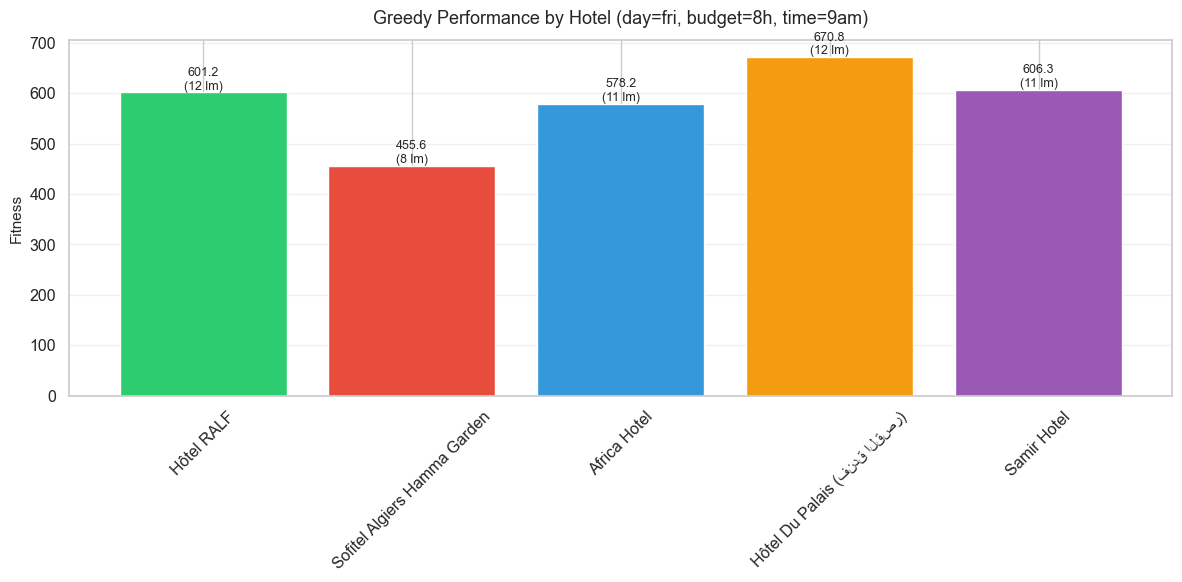

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\Greedy_test_results\hotel_comparison.png


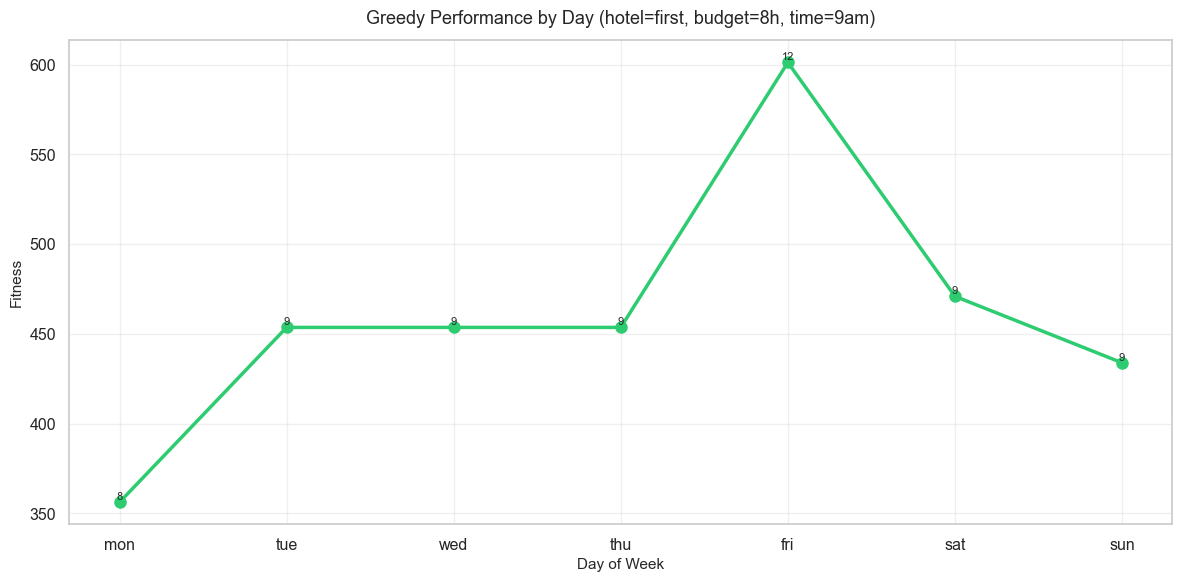

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\Greedy_test_results\day_comparison.png


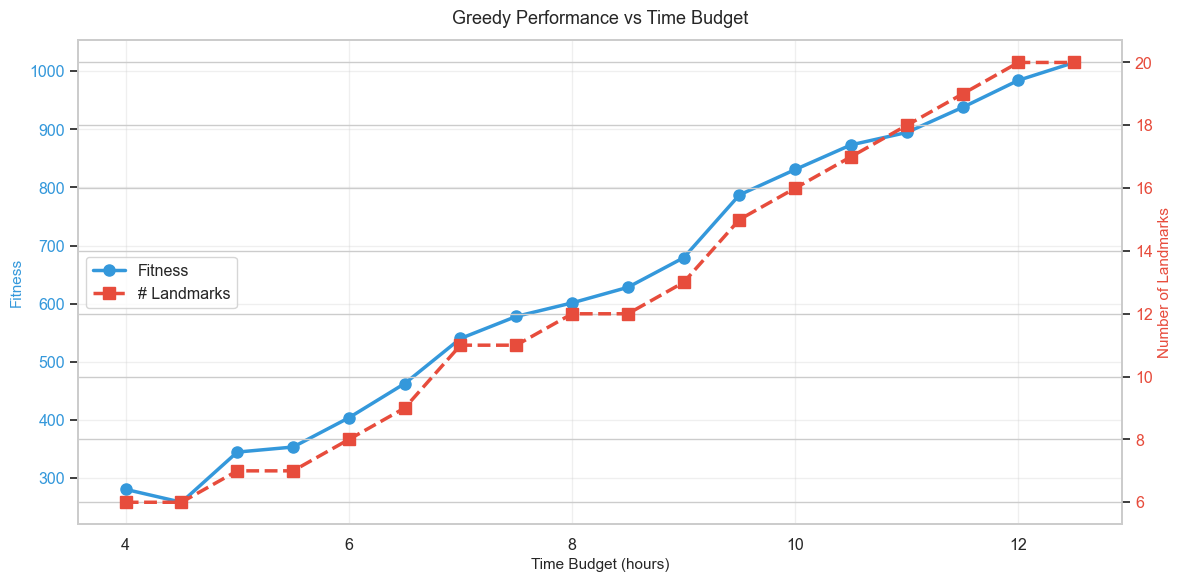

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\Greedy_test_results\budget_sweep.png


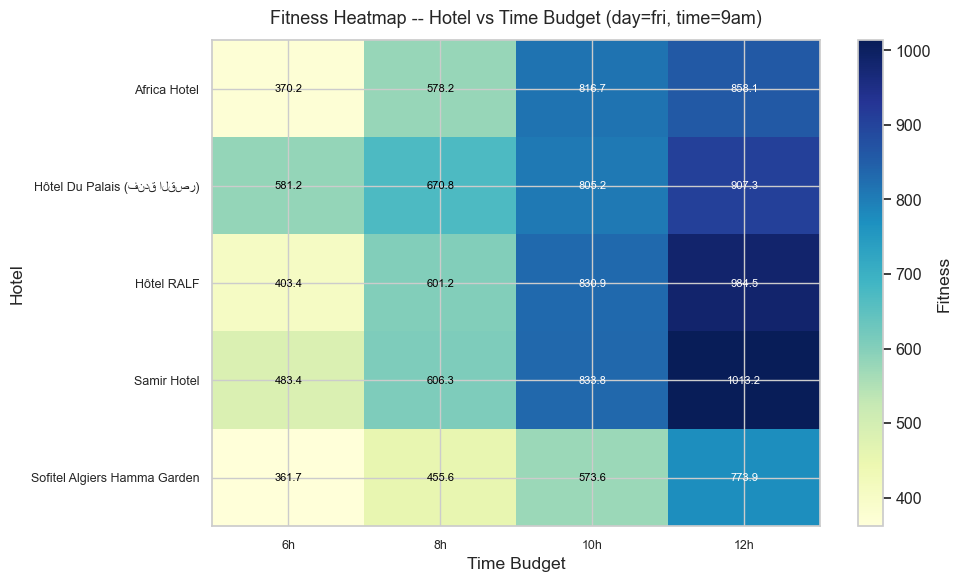

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\Greedy_test_results\heatmap_hotel_budget.png


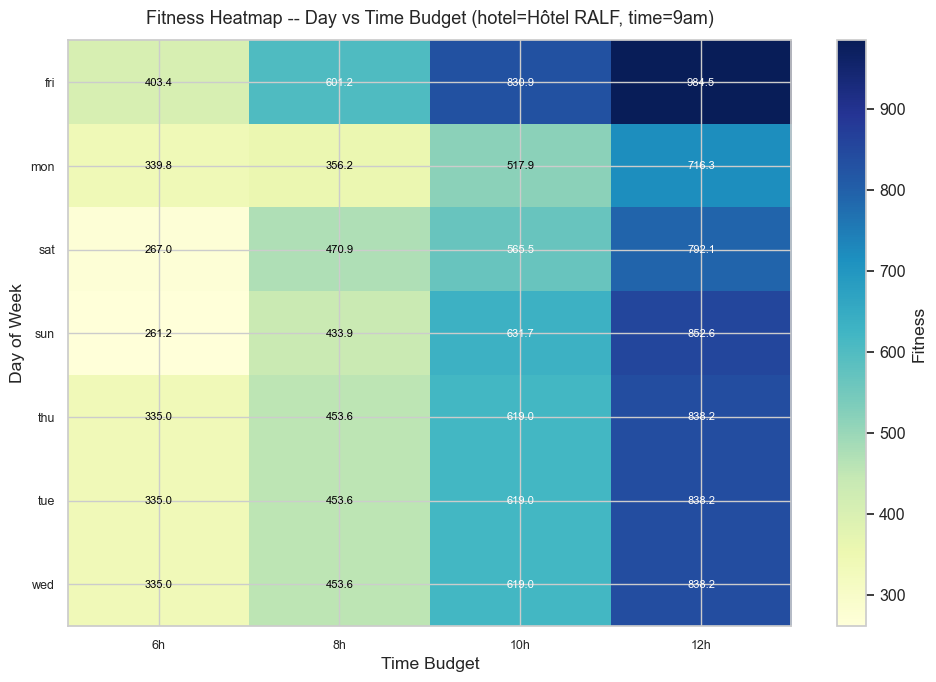

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\Greedy_test_results\heatmap_day_budget.png


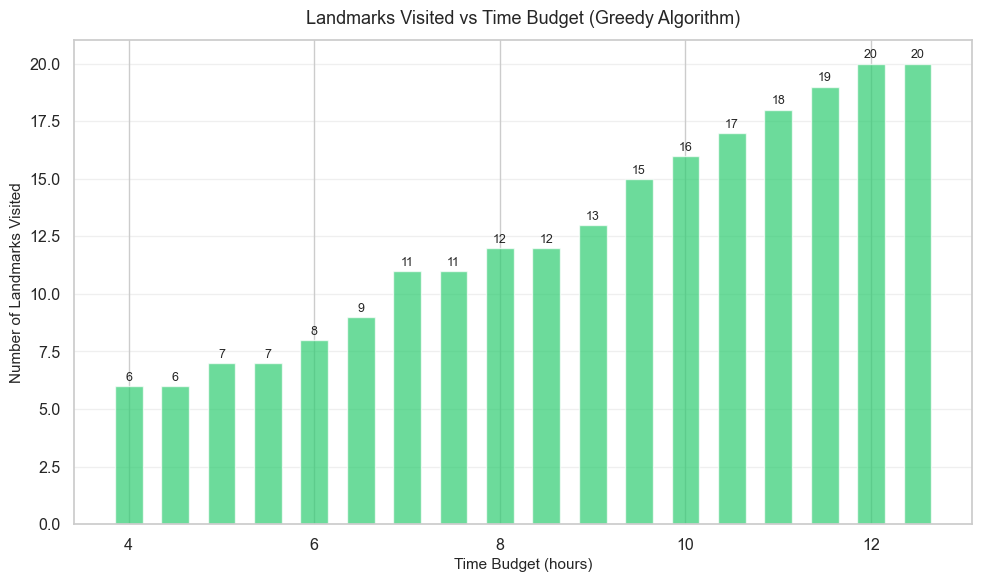

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\Greedy_test_results\landmarks_by_budget.png


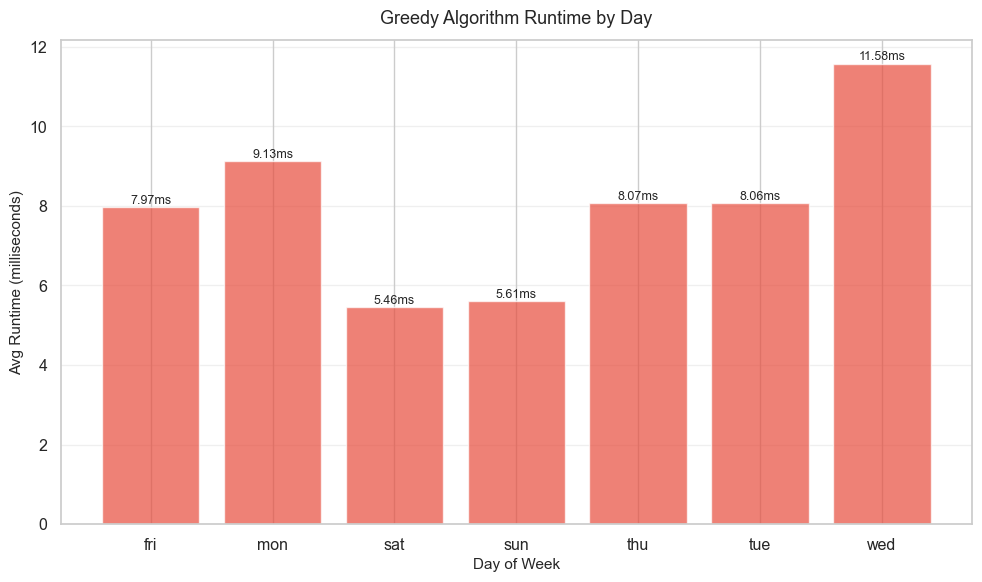

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\Greedy_test_results\runtime_by_day.png

SUMMARY -- Hotel Comparison Results
                       Hotel  Fitness  Interest  TravelTime_h  NumLandmarks  Runtime_ms
                  Hôtel RALF    601.2      90.0          0.48            12        2.75
Sofitel Algiers Hamma Garden    455.6      69.3          0.49             8        4.64
                Africa Hotel    578.2      85.4          0.33            11        3.08
Hôtel Du Palais (فندق القصر)    670.8      99.2          0.39            12        3.10
                 Samir Hotel    606.3      90.2          0.42            11        1.88

Day-of-Week Comparison Results
Day  Fitness  Interest  TravelTime_h  NumLandmarks  Runtime_ms
mon    356.2      53.7          0.33             8        3.19
tue    453.6      67.9          0.36             9        3.02
wed    453.6      67.9          0.36             9        2.93
thu    453.6      67.9          0.36             9     

In [20]:
%matplotlib inline


import sys, os, time, random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# ── project imports ──────────────────────────────────────────────────────────

# ── data loading ─────────────────────────────────────────────────────────────
landmarks = get_landmarks()
hotels = get_hotels()
time_matrix = get_time_matrix()
# Create a landmarks dictionary for easier lookup by name
landmarks_dict = {lm.name: lm for lm in landmarks}
# ── parameters ───────────────────────────────────────────────────────────
Hotels_to_test = hotels[:min(5, len(hotels))]  # Test first 5 hotels
Days = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]
Time_budgets = [6.0, 8.0, 10.0, 12.0]  # hours
Start_times = [8, 9, 10]  # hours (24-hour format)

SEED = 42

# ── output directory ─────────────────────────────────────────────────────────
OUTPUT_DIR = os.path.join(os.getcwd(), "Tests", "Greedy_test_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def calculate_path_metrics(path, landmarks_dict, time_matrix, problem_hotel):
    """
    Calculate metrics for a greedy path.
    Path is a list of states: (position_name, visited_set, current_time)
    
    Returns: (fitness, total_interest, total_time_hours, num_landmarks)
    """
    if not path or len(path) < 2:
        return 0, 0, 0, 0
    
    # Extract visited landmarks from the path's visited_set (the second element of the last state)
    final_state = path[-1]
    visited_names = final_state[1]  # frozenset of visited landmark names
    
    # Get the actual landmark objects
    visited_landmarks = []
    for name in visited_names:
        if name in landmarks_dict:
            visited_landmarks.append(landmarks_dict[name])
    
    if not visited_landmarks:
        return 0, 0, 0, 0
    
    total_interest = sum(lm.interest_score for lm in visited_landmarks)
    
    # Calculate total travel time between consecutive waypoints
    total_travel_time = 0
    for i in range(len(path) - 1):
        current_pos = path[i][0]  # position name from state tuple
        next_pos = path[i+1][0]
        
        if current_pos in time_matrix and next_pos in time_matrix[current_pos]:
            total_travel_time += time_matrix[current_pos][next_pos]
    
    total_time_hours = total_travel_time / 60.0  # convert minutes to hours
    num_landmarks = len(visited_landmarks)
    
    # Fitness: weighted combination of interest and efficiency
    fitness = (7 * total_interest) - total_travel_time if total_travel_time > 0 else total_interest * 7
    
    return fitness, total_interest, total_time_hours, num_landmarks

# ═════════════════════════════════════════════════════════════════════════════
# 1.  FULL COMPREHENSIVE TEST across all configurations
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 1 -- Full Comprehensive Test (Hotels × Days × Budgets × Times)")
print("=" * 70)

rows_full = []
total_configs = len(Hotels_to_test) * len(Days) * len(Time_budgets) * len(Start_times)
config_idx = 0

for hotel in Hotels_to_test:
    for day in Days:
        for budget in Time_budgets:
            for start_time in Start_times:
                config_idx += 1
                
                # Create problem instance
                problem = TravelProblem_InformedSearch(
                    hotel, landmarks, [], time_matrix,
                    time_budget=budget * 60,  # convert to minutes
                    starting_time=start_time * 60,  # convert to minutes
                    visiting_day=day
                )
                
                t0 = time.time()
                path = greedy_search(problem)
                elapsed = time.time() - t0
                
                if path:
                    fitness, interest, tot_time, n_lm = calculate_path_metrics(path, landmarks_dict, time_matrix, hotel)
                else:
                    fitness, interest, tot_time, n_lm = 0, 0, 0, 0
                
                rows_full.append({
                    'Hotel': hotel.name,
                    'Day': day,
                    'Budget_h': budget,
                    'StartTime': start_time,
                    'Fitness': round(fitness, 4),
                    'Interest': round(interest, 2),
                    'TravelTime_h': round(tot_time, 2),
                    'NumLandmarks': n_lm,
                    'Runtime_ms': round(elapsed * 1000, 2),
                })
                
                if config_idx % 10 == 0:
                    print(f"  [{config_idx:3d}/{total_configs}]  {hotel.name:20s} {day:3s} budget={budget:.0f}h start={start_time:2d}"
                          f"  ->  fit={fitness:7.2f} lm={n_lm:2d} ({elapsed*1000:.1f}ms)")

df_full = pd.DataFrame(rows_full)
csv_path = os.path.join(OUTPUT_DIR, "full_test_results.csv")
df_full.to_csv(csv_path, index=False)
print(f"\n[OK] Full test results saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 2.  HOTEL COMPARISON
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 2 -- Hotel Comparison (fixed day=fri, budget=8h, time=9am)")
print("=" * 70)

rows_hotel = []
for hotel in Hotels_to_test:
    problem = TravelProblem_InformedSearch(
        hotel, landmarks, [], time_matrix,
        time_budget=8 * 60,
        starting_time=9 * 60,
        visiting_day='fri'
    )
    
    t0 = time.time()
    path = greedy_search(problem)
    elapsed = time.time() - t0
    
    if path:
        fitness, interest, tot_time, n_lm = calculate_path_metrics(path, landmarks_dict, time_matrix, hotel)
    else:
        fitness, interest, tot_time, n_lm = 0, 0, 0, 0
    
    rows_hotel.append({
        'Hotel': hotel.name,
        'Fitness': round(fitness, 4),
        'Interest': round(interest, 2),
        'TravelTime_h': round(tot_time, 2),
        'NumLandmarks': n_lm,
        'Runtime_ms': round(elapsed * 1000, 2),
    })
    print(f"  {hotel.name:20s}  ->  fit={fitness:7.2f} #lm={n_lm:2d} travel={tot_time:.1f}h ({elapsed*1000:.1f}ms)")

df_hotel = pd.DataFrame(rows_hotel)
csv_path = os.path.join(OUTPUT_DIR, "hotel_comparison.csv")
df_hotel.to_csv(csv_path, index=False)
print(f"  [OK] saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 3.  DAY-OF-WEEK COMPARISON
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 3 -- Day-of-Week Comparison (fixed hotel=first, budget=8h, time=9am)")
print("=" * 70)

rows_day = []
for day in Days:
    problem = TravelProblem_InformedSearch(
        Hotels_to_test[0], landmarks, [], time_matrix,
        time_budget=8 * 60,
        starting_time=9 * 60,
        visiting_day=day
    )
    
    t0 = time.time()
    path = greedy_search(problem)
    elapsed = time.time() - t0
    
    if path:
        fitness, interest, tot_time, n_lm = calculate_path_metrics(path, landmarks_dict, time_matrix, Hotels_to_test[0])
    else:
        fitness, interest, tot_time, n_lm = 0, 0, 0, 0
    
    rows_day.append({
        'Day': day,
        'Fitness': round(fitness, 4),
        'Interest': round(interest, 2),
        'TravelTime_h': round(tot_time, 2),
        'NumLandmarks': n_lm,
        'Runtime_ms': round(elapsed * 1000, 2),
    })
    print(f"  {day:3s}  ->  fit={fitness:7.2f} #lm={n_lm:2d} travel={tot_time:.1f}h ({elapsed*1000:.1f}ms)")

df_day = pd.DataFrame(rows_day)
csv_path = os.path.join(OUTPUT_DIR, "day_comparison.csv")
df_day.to_csv(csv_path, index=False)
print(f"  [OK] saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 4.  TIME BUDGET SWEEP
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 4 -- Time Budget Sweep (fixed hotel=first, day=fri, time=9am)")
print("=" * 70)

rows_budget = []
for budget in np.arange(4, 13, 0.5):
    problem = TravelProblem_InformedSearch(
        Hotels_to_test[0], landmarks, [], time_matrix,
        time_budget=budget * 60,
        starting_time=9 * 60,
        visiting_day='fri'
    )
    
    t0 = time.time()
    path = greedy_search(problem)
    elapsed = time.time() - t0
    
    if path:
        fitness, interest, tot_time, n_lm = calculate_path_metrics(path, landmarks_dict, time_matrix, Hotels_to_test[0])
    else:
        fitness, interest, tot_time, n_lm = 0, 0, 0, 0
    
    rows_budget.append({
        'Budget_h': round(budget, 1),
        'Fitness': round(fitness, 4),
        'Interest': round(interest, 2),
        'TravelTime_h': round(tot_time, 2),
        'NumLandmarks': n_lm,
        'Runtime_ms': round(elapsed * 1000, 2),
    })
    print(f"  budget={budget:.1f}h  ->  fit={fitness:7.2f} #lm={n_lm:2d} travel={tot_time:.1f}h ({elapsed*1000:.1f}ms)")

df_budget = pd.DataFrame(rows_budget)
csv_path = os.path.join(OUTPUT_DIR, "budget_sweep.csv")
df_budget.to_csv(csv_path, index=False)
print(f"  [OK] saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 5.  PLOTS
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 5 -- Generating Plots")
print("=" * 70)

COLORS = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

# ---------- Plot 1: Hotel Comparison - Bar Chart ----------
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(df_hotel['Hotel'], df_hotel['Fitness'], color=COLORS[:len(df_hotel)])
ax.set_ylabel('Fitness', fontsize=11)
ax.set_title('Greedy Performance by Hotel (day=fri, budget=8h, time=9am)', fontsize=13, pad=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
for bar, val, lm in zip(bars, df_hotel['Fitness'], df_hotel['NumLandmarks']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
            f'{val:.1f}\n({int(lm)} lm)', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
path1 = os.path.join(OUTPUT_DIR, "hotel_comparison.png")
fig.savefig(path1, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path1}")

# ---------- Plot 2: Day-of-Week Comparison - Line Chart ----------
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_day['Day'], df_day['Fitness'], 'o-', color='#2ecc71', linewidth=2.5, markersize=8, label='Fitness')
ax.set_xlabel('Day of Week', fontsize=11)
ax.set_ylabel('Fitness', fontsize=11)
ax.set_title('Greedy Performance by Day (hotel=first, budget=8h, time=9am)', fontsize=13, pad=12)
ax.grid(alpha=0.3)
for x, y, n_lm in zip(range(len(df_day)), df_day['Fitness'], df_day['NumLandmarks']):
    ax.text(x, y + 0.2, f'{int(n_lm)}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
path2 = os.path.join(OUTPUT_DIR, "day_comparison.png")
fig.savefig(path2, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path2}")

# ---------- Plot 3: Time Budget Sweep - Line Chart ----------
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(df_budget['Budget_h'], df_budget['Fitness'], 'o-', color='#3498db', linewidth=2.5, markersize=8, label='Fitness')
ax1.set_xlabel('Time Budget (hours)', fontsize=11)
ax1.set_ylabel('Fitness', color='#3498db', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.plot(df_budget['Budget_h'], df_budget['NumLandmarks'], 's--', color='#e74c3c', linewidth=2.5, markersize=8, label='# Landmarks')
ax2.set_ylabel('Number of Landmarks', color='#e74c3c', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.set_title('Greedy Performance vs Time Budget', fontsize=13, pad=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')
ax1.grid(alpha=0.3)
plt.tight_layout()
path3 = os.path.join(OUTPUT_DIR, "budget_sweep.png")
fig.savefig(path3, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path3}")

# ---------- Plot 4: Heatmap - Hotel vs Budget (Fitness) ----------
fig, ax = plt.subplots(figsize=(10, 6))
# Create a subset for hotel vs budget
heatmap_data = df_full[df_full['Day'] == 'fri'].copy()
heatmap_data = heatmap_data[heatmap_data['StartTime'] == 9]
pivot_hb = heatmap_data.pivot_table(index='Hotel', columns='Budget_h', values='Fitness', aggfunc='mean')
im = ax.imshow(pivot_hb.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(pivot_hb.columns)))
ax.set_xticklabels([f'{x:.0f}h' for x in pivot_hb.columns], fontsize=9)
ax.set_yticks(range(len(pivot_hb.index)))
ax.set_yticklabels(pivot_hb.index, fontsize=9)
for i in range(len(pivot_hb.index)):
    for j in range(len(pivot_hb.columns)):
        val = pivot_hb.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8,
                    color='white' if val > np.nanmean(pivot_hb.values) else 'black')
fig.colorbar(im, ax=ax, label='Fitness')
ax.set_title('Fitness Heatmap -- Hotel vs Time Budget (day=fri, time=9am)', fontsize=13, pad=12)
ax.set_xlabel('Time Budget')
ax.set_ylabel('Hotel')
plt.tight_layout()
path4 = os.path.join(OUTPUT_DIR, "heatmap_hotel_budget.png")
fig.savefig(path4, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path4}")

# ---------- Plot 5: Heatmap - Day vs Budget (Fitness) ----------
fig, ax = plt.subplots(figsize=(10, 7))
heatmap_data2 = df_full[df_full['Hotel'] == Hotels_to_test[0].name].copy()
heatmap_data2 = heatmap_data2[heatmap_data2['StartTime'] == 9]
pivot_db = heatmap_data2.pivot_table(index='Day', columns='Budget_h', values='Fitness', aggfunc='mean')
im = ax.imshow(pivot_db.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(pivot_db.columns)))
ax.set_xticklabels([f'{x:.0f}h' for x in pivot_db.columns], fontsize=9)
ax.set_yticks(range(len(pivot_db.index)))
ax.set_yticklabels(pivot_db.index, fontsize=9)
for i in range(len(pivot_db.index)):
    for j in range(len(pivot_db.columns)):
        val = pivot_db.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8,
                    color='white' if val > np.nanmean(pivot_db.values) else 'black')
fig.colorbar(im, ax=ax, label='Fitness')
ax.set_title(f'Fitness Heatmap -- Day vs Time Budget (hotel={Hotels_to_test[0].name}, time=9am)', fontsize=13, pad=12)
ax.set_xlabel('Time Budget')
ax.set_ylabel('Day of Week')
plt.tight_layout()
path5 = os.path.join(OUTPUT_DIR, "heatmap_day_budget.png")
fig.savefig(path5, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path5}")

# ---------- Plot 6: Landmarks Visited by Budget ----------
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_budget['Budget_h'], df_budget['NumLandmarks'], color=COLORS[0], alpha=0.7, width=0.3)
ax.set_xlabel('Time Budget (hours)', fontsize=11)
ax.set_ylabel('Number of Landmarks Visited', fontsize=11)
ax.set_title('Landmarks Visited vs Time Budget (Greedy Algorithm)', fontsize=13, pad=12)
ax.grid(axis='y', alpha=0.3)
for x, y in zip(df_budget['Budget_h'], df_budget['NumLandmarks']):
    ax.text(x, y + 0.1, str(int(y)), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
path6 = os.path.join(OUTPUT_DIR, "landmarks_by_budget.png")
fig.savefig(path6, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path6}")

# ---------- Plot 7: Runtime Comparison ----------
fig, ax = plt.subplots(figsize=(10, 6))
avg_runtime = df_full.groupby('Day')['Runtime_ms'].mean()
bars = ax.bar(avg_runtime.index, avg_runtime.values, color=COLORS[1], alpha=0.7)
ax.set_xlabel('Day of Week', fontsize=11)
ax.set_ylabel('Avg Runtime (milliseconds)', fontsize=11)
ax.set_title('Greedy Algorithm Runtime by Day', fontsize=13, pad=12)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, avg_runtime.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.2f}ms', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
path7 = os.path.join(OUTPUT_DIR, "runtime_by_day.png")
fig.savefig(path7, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path7}")

# ═════════════════════════════════════════════════════════════════════════════
# 6.  SUMMARY TABLE (printed to console)
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("SUMMARY -- Hotel Comparison Results")
print("=" * 70)
print(df_hotel.to_string(index=False))

print("\n" + "=" * 70)
print("Day-of-Week Comparison Results")
print("=" * 70)
print(df_day.to_string(index=False))

print("\n" + "=" * 70)
print("Time Budget Sweep Results")
print("=" * 70)
print(df_budget.to_string(index=False))

print("\n[DONE] All done! Results & plots saved in:", OUTPUT_DIR)


### ***Simulated Annealing Test***

Simulated Annealing is a probabilistic technique for approximating the global optimum of a given function. In this context, it is used to optimize travel itineraries by balancing exploration (accepting worse moves at high temperatures) and exploitation (refining the path as it cools).

#### Study Methodology:
This cell executes a **Grid Search** across 12 unique configurations to identify the "sweet spot" for itinerary optimization:
1.  **Initial Temperature ($T_0$):** [50, 100, 300, 500]. Higher temperatures allow more exploration early on.
2.  **Cooling Rate ($\alpha$):** [0.95, 0.97, 0.99]. Controls the speed of stabilization.
3.  **Monte Carlo Trials:** Each configuration is run 3 times to ensure statistical significance.

#### Constraints Handled:
- **Time Budget:** Maximum of 8 hours of total activity (travel + visit duration).
- **Opening Hours:** Uses a "Robust Mapping" technique to handle day-name variations (e.g., 'mon' vs 'Monday').
- **Scoring Function:** A unified metric that rewards landmark ratings while penalizing travel time: 
  $$Score = (7 \times \sum Ratings) - \sum TravelTime_{min}$$

#### Visualization Outputs:
- **Heatmap:** Maps the best evaluation score achieved for every Temp/Cooling pair.
- **Scaling Study:** Visualizes how solution quality and runtime scale with increasing temperature.
- **Top 5 Chart:** Provides the best-performing parameters for the given dataset.

                      🌍 TRAVEL ENVIRONMENT & CONSTRAINTS 🌍                      
🏨 Hotel       : Hôtel Arago
📅 Day         : Mon
⏰ Start Time  : 9:00 AM
⏳ Budget      : 8.0 hours

🚀 Executing Grid Search (12 configurations)...

--------------------------------------------------------------------------------------------------------------
[01/12] Testing Temp=50   | Cool=0.95
   >>> 🌟 NEW GLOBAL BEST! Score: 762.30 | Runtime: 43.47s
   >>> 🌟 NEW GLOBAL BEST! Score: 774.20 | Runtime: 62.78s
[02/12] Testing Temp=50   | Cool=0.97
   >>> 🌟 NEW GLOBAL BEST! Score: 775.80 | Runtime: 111.08s
[03/12] Testing Temp=50   | Cool=0.99
   >>> 🌟 NEW GLOBAL BEST! Score: 794.20 | Runtime: 191.19s
[04/12] Testing Temp=100  | Cool=0.95
[05/12] Testing Temp=100  | Cool=0.97
[06/12] Testing Temp=100  | Cool=0.99
[07/12] Testing Temp=300  | Cool=0.95
[08/12] Testing Temp=300  | Cool=0.97
[09/12] Testing Temp=300  | Cool=0.99
[10/12] Testing Temp=500  | Cool=0.95
[11/12] Testing Temp=500  | Cool=0.97
[12/12] T

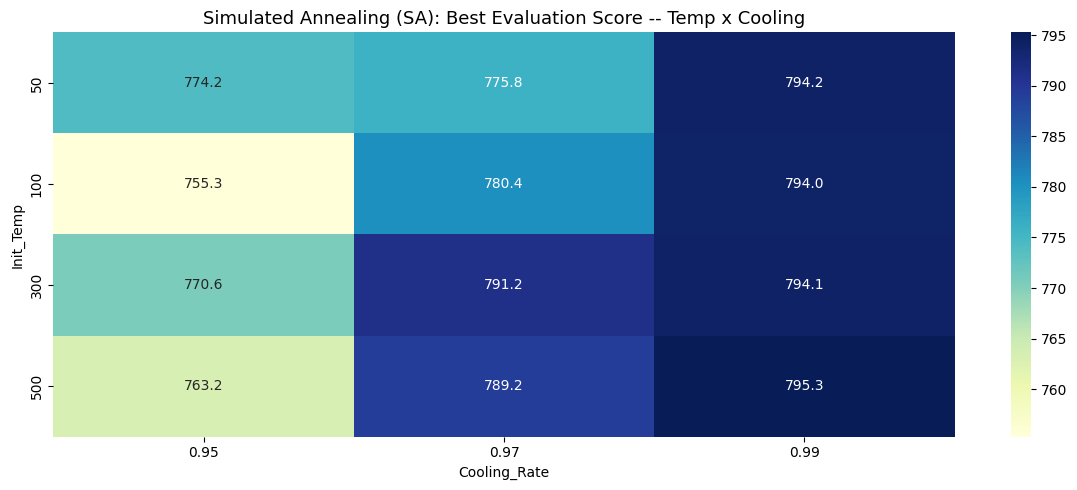

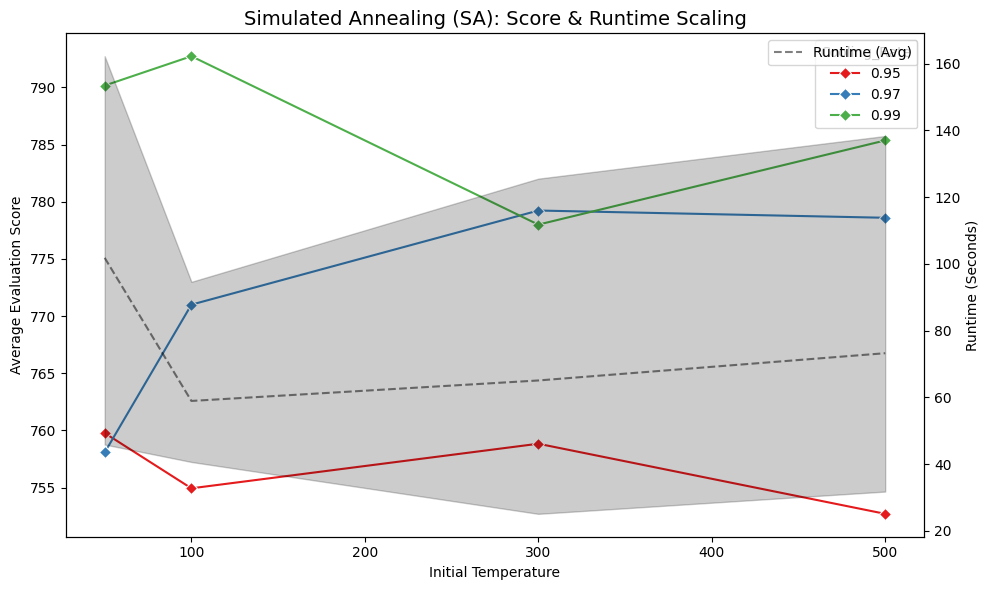

C:\Users\LKTech\AppData\Local\Temp\ipykernel_23364\36523060.py:229: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Best_Score', y=labels_top, data=top5, palette="viridis")


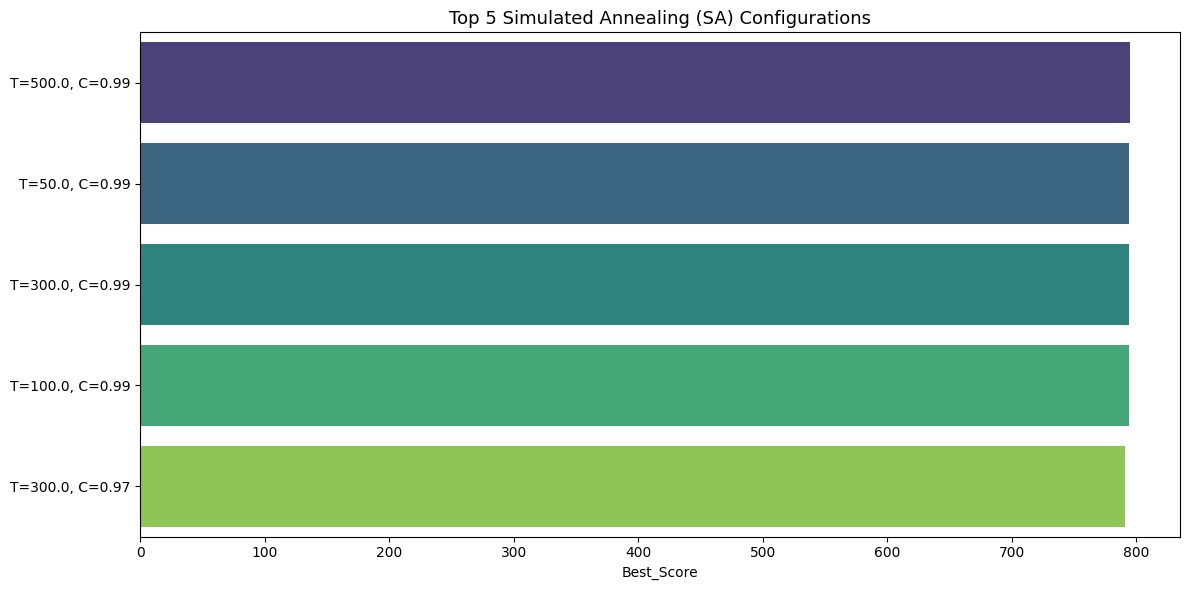


[OK] Results & plots saved in: C:\Users\LKTech\Desktop\Tests\SA-results


In [ ]:

# Force inline plotting for Jupyter
%matplotlib inline

# Add project root to path
try:
    _BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    _BASE_DIR = Path().resolve().parent

if str(_BASE_DIR) not in sys.path:
    sys.path.insert(0, str(_BASE_DIR))


from utils.data_loader import get_landmarks, get_hotels, get_time_matrix
from core.Node_Classes import Landmark, Hotel

ALGO_NAME = "Simulated Annealing (SA)"

def calculate_unified_score(path, time_matrix_dict):
    if not path: return 0
    total_rating = sum(node.interest_score for node in path if isinstance(node, Landmark))
    
    total_travel_time = 0
    for i in range(len(path) - 1):
        u_name = path[i].name
        v_name = path[i+1].name
        total_travel_time += time_matrix_dict.get(u_name, {}).get(v_name, 0)
            
    return (7 * total_rating) - total_travel_time

def run_sa_notebook_study():
    # Use global landmarks, hotels, time_matrix if available
    global landmarks, hotels, time_matrix
    
    # Reload if they are not in global scope
    if 'landmarks' not in globals(): landmarks = get_landmarks()
    if 'hotels' not in globals(): hotels = get_hotels()
    # Forces loading of the named CSV to get a proper dict structure
    import json
    try:
        df_tm = pd.read_csv(_BASE_DIR / 'utils' / 'time_matrix_named.csv', index_col=0)
        time_matrix_dict = df_tm.to_dict('index')
    except:
        time_matrix_dict = get_time_matrix()
    
    # Define mapping to ensure full compatibility with short and long day names
    days_short = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]
    days_full = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    
    # Mapping logic for various CSV formats
    def get_attr(row, possibilities, default=None):
        for p in possibilities:
            if p in row: return row[p]
        return default

    if isinstance(hotels, pd.DataFrame):
        hotel_list = []
        for _, row in hotels.iterrows():
            name = get_attr(row, ['name', 'Name'], 'Unknown Hotel')
            lon = get_attr(row, ['lon', 'longitude', 'Longitude'], 0)
            lat = get_attr(row, ['lat', 'latitude', 'Latitude'], 0)
            hotel_list.append(Hotel(name, float(lon), float(lat)))
    else:
        hotel_list = hotels

    if isinstance(landmarks, pd.DataFrame):
        actual_landmarks = []
        for _, row in landmarks.iterrows():
            name = get_attr(row, ['name', 'Name'], 'Unknown Landmark')
            lon = get_attr(row, ['lon', 'longitude', 'Longitude', 'long'], 0)
            lat = get_attr(row, ['lat', 'latitude', 'Latitude'], 0)
            lid = get_attr(row, ['id', 'ID', 'Id'], 0)
            score = get_attr(row, ['interest_score', 'Rating', 'rating', 'Score'], 0)
            duration = get_attr(row, ['visit_duration', 'EstimatedTime (min)', 'duration'], 60)
            ltype = get_attr(row, ['landmark_type', 'Type', 'type'], 'Unknown')
            
            hours_data = get_attr(row, ['opening_hours', 'Hours'], None)
            
            robust_hours = {}
            always_open = [1] * 24
            
            if hours_data is None or (isinstance(hours_data, float) and pd.isna(hours_data)):
                for d in days_short + days_full: robust_hours[d] = always_open
            elif isinstance(hours_data, str):
                try:
                    import json
                    parsed = json.loads(hours_data.replace("'", "\""))
                    for k, v in parsed.items(): robust_hours[k.lower()[:3]] = v
                    for s, f in zip(days_short, days_full):
                        if s in robust_hours: robust_hours[f] = robust_hours[s]
                except:
                    for d in days_short + days_full: robust_hours[d] = always_open
            elif isinstance(hours_data, dict):
                for k, v in hours_data.items(): robust_hours[k.lower()[:3]] = v
                for s, f in zip(days_short, days_full):
                    if s in robust_hours: robust_hours[f] = robust_hours[s]
            
            for d in days_short:
                if d not in robust_hours: robust_hours[d] = always_open

            actual_landmarks.append(Landmark(
                id=lid, name=name, lon=float(lon), lat=float(lat),
                interest_score=float(score), opening_hours=robust_hours,
                visit_duration=int(duration), landmark_type=ltype
            ))
    else:
        actual_landmarks = landmarks

    selected_hotel = random.choice(hotel_list)
    visiting_day = random.choice(days_short)  
    time_budget_hours = 8.0
    trip_start_time = 9
    
    print("=" * 80)
    print("🌍 TRAVEL ENVIRONMENT & CONSTRAINTS 🌍".center(80))
    print("=" * 80)
    print(f"🏨 Hotel       : {selected_hotel.name}")
    print(f"📅 Day         : {visiting_day.capitalize()}")
    print(f"⏰ Start Time  : {trip_start_time}:00 AM")
    print(f"⏳ Budget      : {time_budget_hours} hours")
    print("=" * 80 + "\n")

    initial_temps = [50, 100, 300, 500]
    cooling_rates = [0.95, 0.97, 0.99]
    max_reheats = [1]
    
    param_results = []
    overall_best_score = -float('inf')
    overall_best_path = []
    
    travel_info = {
        'hotel': selected_hotel, 'Travel_day': visiting_day, 'Travel_Time': time_budget_hours, 
        'type_filter': [], 'time_matrix': time_matrix_dict, 'trip_start_time': trip_start_time
    }
    
  
    problem = TravelProblem_LocalSearch(actual_landmarks, travel_info)

    total_combinations = len(initial_temps) * len(cooling_rates) * len(max_reheats)
    print(f"🚀 Executing Grid Search ({total_combinations} configurations)...\n")
    print("-" * 110)
    
    start_global_time = time.time()
    current_iteration = 0

    for temp, cool, reheat in itertools.product(initial_temps, cooling_rates, max_reheats):
        current_iteration += 1
        print(f"[{current_iteration:02d}/{total_combinations}] Testing Temp={temp:<4} | Cool={cool:<4}")
        
        scores, times, visits = [], [], []
        
        for run_id in range(3):
            sa = Simulated_Annealing(problem, initial_temp=temp, cooling_rate=cool, max_reheats=reheat)
            
            start_run_time = time.time()
            best_state = sa.run()
            exec_time = time.time() - start_run_time
            
            full_path = [selected_hotel] + best_state + [selected_hotel]
            score = calculate_unified_score(full_path, time_matrix_dict)
            num_landmarks_visited = len(best_state) 
            
            scores.append(score)
            times.append(exec_time)
            visits.append(num_landmarks_visited)
            
            if score > overall_best_score:
                overall_best_score = score
                overall_best_path = full_path
                total_rating = sum(node.interest_score for node in full_path if isinstance(node, Landmark))
                print(f"   >>> 🌟 NEW GLOBAL BEST! Score: {score:.2f} | Runtime: {exec_time:.2f}s")
            
        param_results.append({
            "Init_Temp": temp, 
            "Cooling_Rate": cool, 
            "Max_Reheats": reheat,
            "Avg_Score": sum(scores)/3, 
            "Avg_Time_Sec": sum(times)/3, 
            "Avg_Visited": sum(visits)/3,
            "Best_Score": max(scores)
        })

    print("-" * 110)
    print(f"✅ Grid search completed in {time.time() - start_global_time:.2f} seconds!\n")

    # ═════════════════════════════════════════════════════════════════════════════
    # PLOTS
    # ═════════════════════════════════════════════════════════════════════════════
    print("PHASE 4 -- Generating Plots")
    df_params = pd.DataFrame(param_results)
    OUTPUT_DIR = os.path.join(_BASE_DIR, "Tests", "SA-results")
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # ---------- Plot 1: Heatmap ----------
    plt.figure(figsize=(12, 5))
    pivot = df_params.groupby(['Init_Temp', 'Cooling_Rate'])['Best_Score'].max().unstack()
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
    plt.title(f'{ALGO_NAME}: Best Evaluation Score -- Temp x Cooling', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "heatmap_temp_cool.png"), dpi=150)
    plt.show()

    # ---------- Plot 2: Scaling Chart ----------
    fig, ax1 = plt.subplots(figsize=(10, 6))
    sns.lineplot(data=df_params, x="Init_Temp", y="Avg_Score", hue="Cooling_Rate", marker="D", palette="Set1", ax=ax1)
    ax1.set_title(f"{ALGO_NAME}: Score & Runtime Scaling", fontsize=14)
    ax1.set_xlabel("Initial Temperature")
    ax1.set_ylabel("Average Evaluation Score")
    ax2 = ax1.twinx()
    sns.lineplot(data=df_params, x="Init_Temp", y="Avg_Time_Sec", color='black', linestyle='--', alpha=0.5, ax=ax2, label='Runtime (Avg)')
    ax2.set_ylabel("Runtime (Seconds)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "scaling_study.png"), dpi=150)
    plt.show()

    # ---------- Plot 3: Top 5 Configurations ----------
    top5 = df_params.nlargest(5, 'Best_Score')
    plt.figure(figsize=(12, 6))
    labels_top = [f"T={r['Init_Temp']}, C={r['Cooling_Rate']}" for _, r in top5.iterrows()]
    sns.barplot(x='Best_Score', y=labels_top, data=top5, palette="viridis")
    plt.title(f'Top 5 {ALGO_NAME} Configurations', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "top5_sa_configs.png"), dpi=150)
    plt.show()

    print(f"\n[OK] Results & plots saved in: {OUTPUT_DIR}")

# Execute the study
run_sa_notebook_study()

### ***Genetic Algorithms Test***

explanation and docuementation


PHASE 1 -- Full Factorial: Selection x Crossover x Mutation
         (generations=100, mutation_rate=0.1, pop=100)
  [  1/108]  tournament  | one_point              | insertion       ->  fit= 652.30 time= 7.93h  #lm=13  (0.5s)
  [  2/108]  tournament  | one_point              | swap            ->  fit= 620.00 time= 7.45h  #lm=11  (0.4s)
  [  3/108]  tournament  | one_point              | inversion       ->  fit= 587.10 time= 7.59h  #lm=11  (0.4s)
  [  4/108]  tournament  | one_point              | scramble        ->  fit= 537.80 time= 7.47h  #lm=11  (0.4s)
  [  5/108]  tournament  | one_point              | deletion        ->  fit= 583.70 time= 7.60h  #lm=11  (0.4s)
  [  6/108]  tournament  | one_point              | displacement    ->  fit= 567.00 time= 6.82h  #lm=10  (0.4s)
  [  7/108]  tournament  | two_point              | insertion       ->  fit= 662.80 time= 7.99h  #lm=13  (0.4s)
  [  8/108]  tournament  | two_point              | swap            ->  fit= 555.50 time= 7.06h  #lm

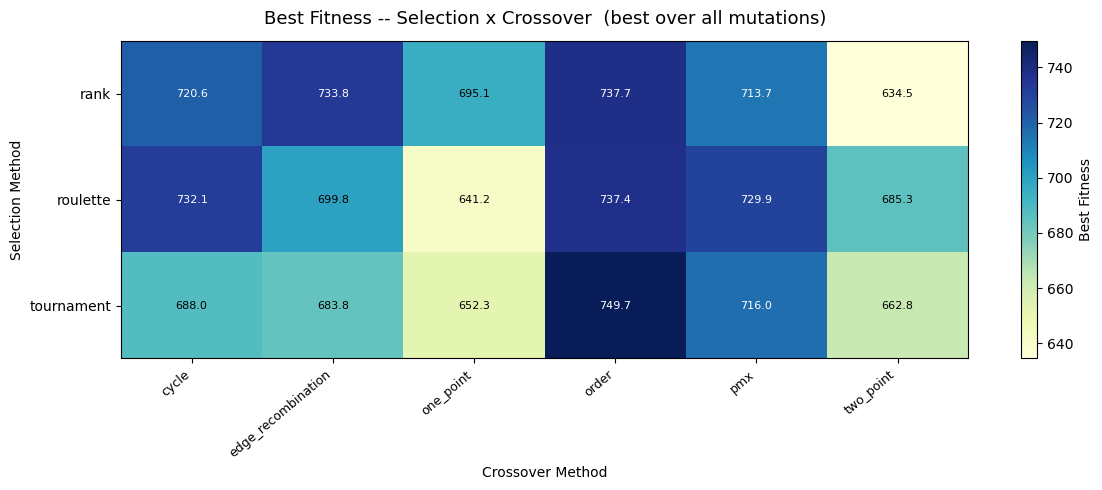

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\heatmap_sel_cx.png


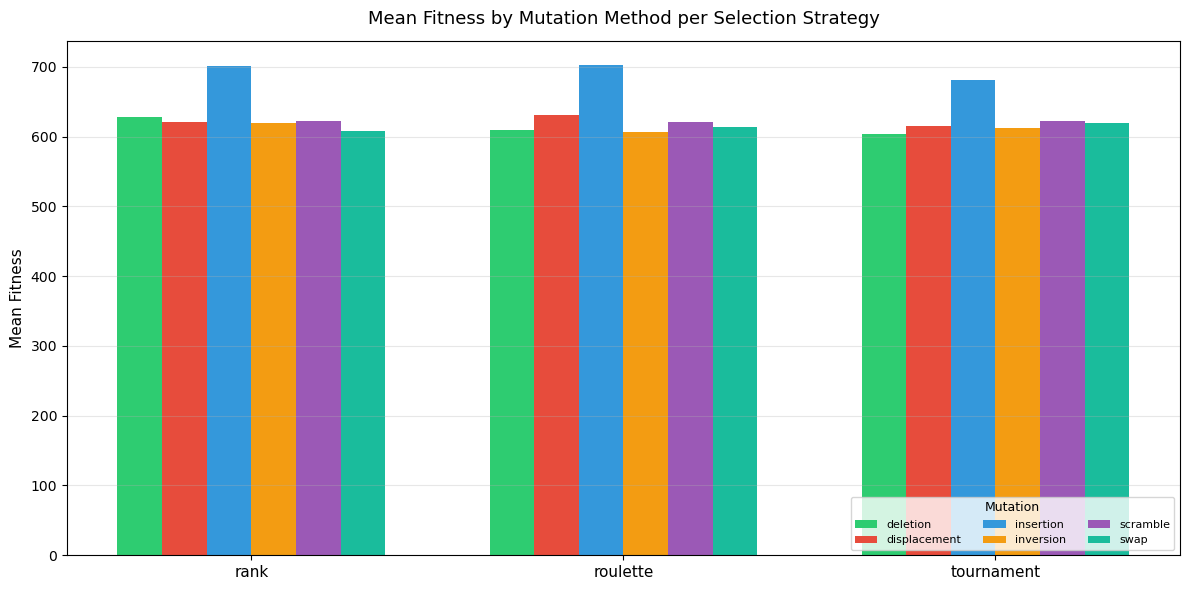

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\bar_mutation_by_selection.png


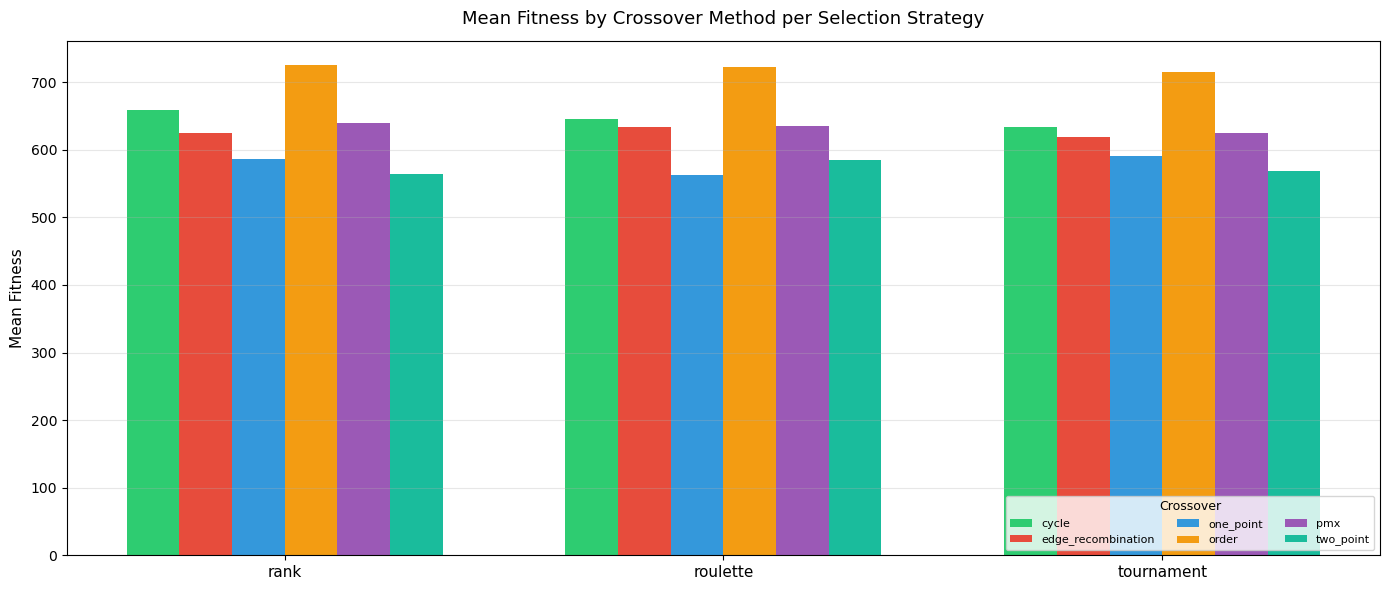

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\bar_crossover_by_selection.png


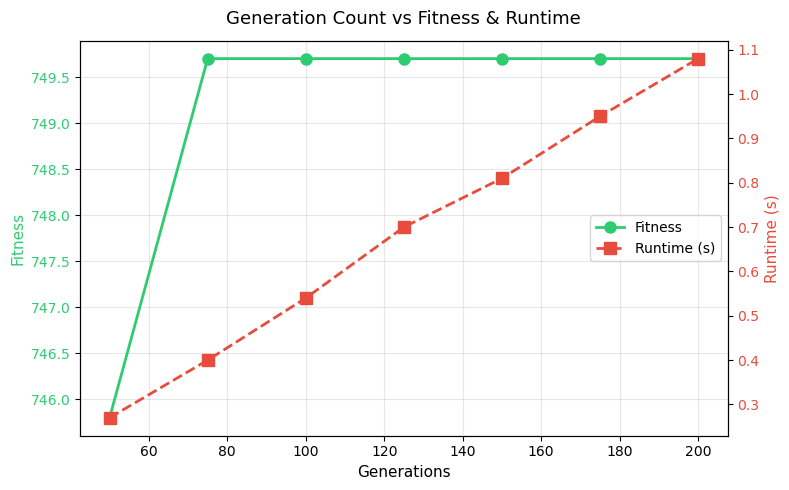

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\generation_sweep.png


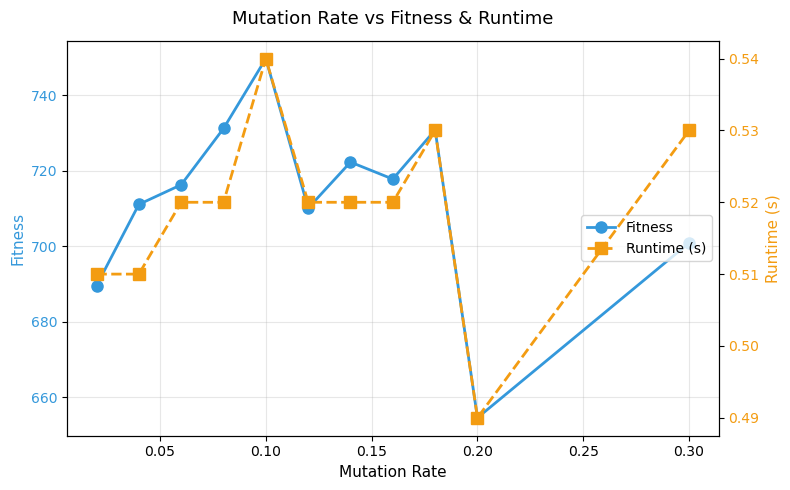

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\mutation_rate_sweep.png


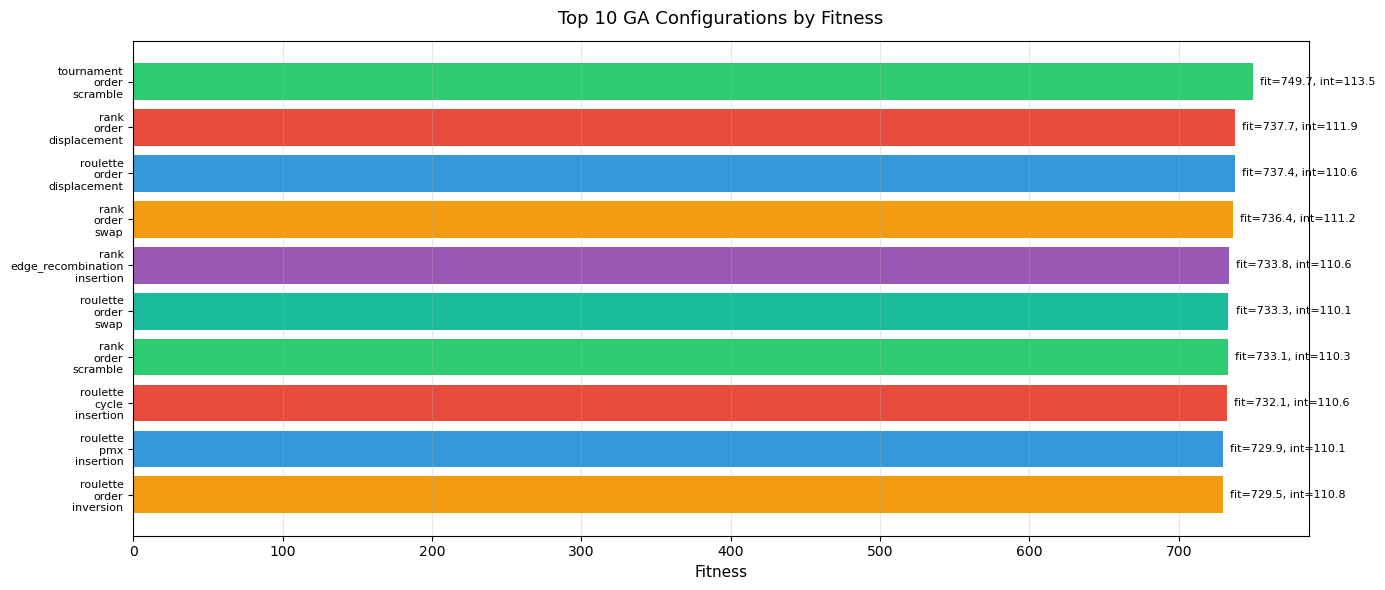

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\top10_configs.png


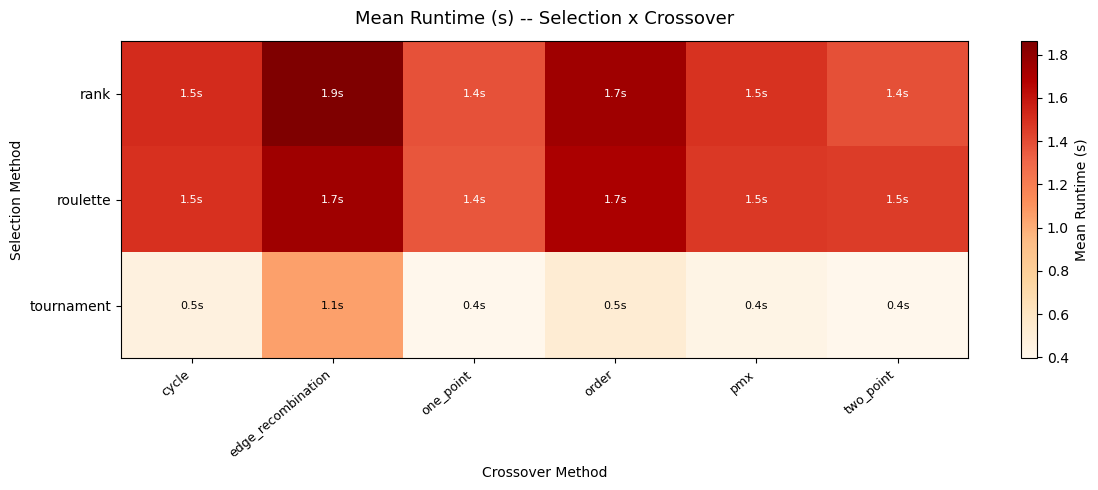

  [OK] c:\Users\ayoub\Desktop\Intro_to_AI_Travel_Project\Tests\GA_test_results\heatmap_runtime.png

SUMMARY -- Top 15 Configurations (by Fitness)
 Selection          Crossover     Mutation  Fitness  Interest  TotalTime_h  NumLandmarks  Runtime_s
tournament              order     scramble    749.7     113.5         7.83            15       0.54
      rank              order displacement    737.7     111.9         7.76            15       1.78
  roulette              order displacement    737.4     110.6         7.70            14       1.69
      rank              order         swap    736.4     111.2         7.70            14       1.73
      rank edge_recombination    insertion    733.8     110.6         7.76            14       2.01
  roulette              order         swap    733.3     110.1         7.71            14       1.72
      rank              order     scramble    733.1     110.3         7.73            14       1.71
  roulette              cycle    insertion    732.1   

In [ ]:
#code for the algorithm
"""
GA-test
=========================================================
Tests the GA across multiple:
  Generation counts        (50, 100, 200)
  Mutation rates            (0.05, 0.1, 0.2)
  Selection methods         (tournament, roulette, rank)
  Crossover methods         (one_point, two_point, pmx, order, cycle, edge_recombination)
  Mutation methods           (swap, inversion, scramble, insertion, deletion, displacement)
"""

%matplotlib inline

# ── project imports ──────────────────────────────────────────────────────────
current_dir = os.getcwd()

# ── data loading ─────────────────────────────────────────────────────────────
landmarks = get_landmarks()
hotels     = get_hotels()
time_matrix = get_time_matrix()

# ── problem setup ─────────────────────────────────────────────────────────────
problem = TravelProblem_LocalSearch(
    landmarks,
    travel_information={
        'hotel': hotels[0],
        'time_matrix': time_matrix,
        'Travel_Time': 8,
        'Travel_day': 'fri',
        'type_filter': None,
        'trip_start_time': 9,
    },
)

# ── parameters ───────────────────────────────────────────────────────────
Generation_values   = [50, 75, 100, 125, 150, 175, 200]
Mutation_rates      = [0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.3]
Selection_methods   = ['tournament', 'roulette', 'rank']
Crossover_methods   = ['one_point', 'two_point', 'pmx', 'order', 'cycle', 'edge_recombination']
Mutation_methods    = ['insertion', 'swap', 'inversion', 'scramble', 'deletion', 'displacement']

POPULATION_SIZE     = 100
SEED                = 42

# ── output directory ─────────────────────────────────────────────────────────
OUTPUT_DIR = os.path.join(current_dir, "Tests", "GA_test_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ═════════════════════════════════════════════════════════════════════════════
# 1.  Full factorial test  (selection × crossover × mutation)
#     Using fixed generations=100, mutation_rate=0.1
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 1 -- Full Factorial: Selection x Crossover x Mutation")
print("         (generations=100, mutation_rate=0.1, pop=100)")
print("=" * 70)

rows_factorial = []
total_combos = len(Selection_methods) * len(Crossover_methods) * len(Mutation_methods)
combo_idx = 0

for sel in Selection_methods:
    for cx in Crossover_methods:
        for mut in Mutation_methods:
            combo_idx += 1
            random.seed(SEED)
            ga = Genetic_Algorithm(problem, population_size=POPULATION_SIZE,
                                   generations=100, mutation_rate=0.1)
            t0 = time.time()
            best = ga.evolve(
                selection_method=sel,
                crossover_method=cx,
                mutation_method=mut,
                tournament_size=5,
                neighborhood_selection='linear',
                elitism_rate=0.2,
            )
            elapsed = time.time() - t0
            fitness   = ga.calculate_fitness(best)
            interest = sum(lm.interest_score for lm in best)
            tot_time  = round(ga.calculate_total_time(best), 2)
            n_lm      = len(best)
            rows_factorial.append({
                'Selection': sel,
                'Crossover': cx,
                'Mutation':  mut,
                'Fitness':   round(fitness, 4),
                'Interest':    round(interest, 2),
                'TotalTime_h': tot_time,
                'NumLandmarks': n_lm,
                'Runtime_s':   round(elapsed, 2),
            })
            print(f"  [{combo_idx:3d}/{total_combos}]  {sel:11s} | {cx:22s} | {mut:14s}"
                  f"  ->  fit={fitness:7.2f} "
                  f"time={tot_time:5.2f}h  #lm={n_lm}  ({elapsed:.1f}s)")

df_factorial = pd.DataFrame(rows_factorial)
csv_path = os.path.join(OUTPUT_DIR, "factorial_results.csv")
df_factorial.to_csv(csv_path, index=False)
print(f"\n[OK] Factorial results saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 2.  Generation count sweep  (best combo from phase 1)
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 2 -- Generation Count Sweep")
print("=" * 70)

best_row = df_factorial.loc[df_factorial['Fitness'].idxmax()]
best_sel, best_cx, best_mut = best_row['Selection'], best_row['Crossover'], best_row['Mutation']
print(f"  Using best combo from Phase 1: {best_sel} / {best_cx} / {best_mut}")

rows_gen = []
for gen in Generation_values:
    random.seed(SEED)
    ga = Genetic_Algorithm(problem, population_size=POPULATION_SIZE,
                           generations=gen, mutation_rate=0.1)
    t0 = time.time()
    best = ga.evolve(
        selection_method=best_sel,
        crossover_method=best_cx,
        mutation_method=best_mut,
        tournament_size=5,
        neighborhood_selection='linear',
        elitism_rate=0.2,
    )
    elapsed = time.time() - t0
    fitness  = ga.calculate_fitness(best)
    interest = sum(lm.interest_score for lm in best)
    tot_time = round(ga.calculate_total_time(best), 2)
    n_lm     = len(best)
    rows_gen.append({
        'Generations': gen,
        'Fitness':     round(fitness, 4),
        'Interest':    round(interest, 2),
        'TotalTime_h': tot_time,
        'NumLandmarks': n_lm,
        'Runtime_s':   round(elapsed, 2),
    })
    print(f"  gen={gen:4d}  ->  fit={fitness:7.2f}"
          f"time={tot_time:5.2f}h  #lm={n_lm}  ({elapsed:.1f}s)")

df_gen = pd.DataFrame(rows_gen)
csv_path = os.path.join(OUTPUT_DIR, "generation_sweep.csv")
df_gen.to_csv(csv_path, index=False)
print(f"  [OK] saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 3.  Mutation rate sweep
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 3 -- Mutation Rate Sweep")
print("=" * 70)

rows_mr = []
for mr in Mutation_rates:
    random.seed(SEED)
    ga = Genetic_Algorithm(problem, population_size=POPULATION_SIZE,
                           generations=100, mutation_rate=mr)
    t0 = time.time()
    best = ga.evolve(
        selection_method=best_sel,
        crossover_method=best_cx,
        mutation_method=best_mut,
        tournament_size=5,
        neighborhood_selection='linear',
        elitism_rate=0.2,
    )
    elapsed = time.time() - t0
    fitness  = ga.calculate_fitness(best)
    interest = sum(lm.interest_score for lm in best)
    tot_time = round(ga.calculate_total_time(best), 2)
    n_lm     = len(best)
    rows_mr.append({
        'MutationRate': mr,
        'Fitness':      round(fitness, 4),
        'Interest':     round(interest, 2),
        'TotalTime_h':  tot_time,
        'NumLandmarks': n_lm,
        'Runtime_s':    round(elapsed, 2),
    })
    print(f"  mr={mr:.2f}  ->  fit={fitness:7.2f}"
          f"time={tot_time:5.2f}h  #lm={n_lm}  ({elapsed:.1f}s)")

df_mr = pd.DataFrame(rows_mr)
csv_path = os.path.join(OUTPUT_DIR, "mutation_rate_sweep.csv")
df_mr.to_csv(csv_path, index=False)
print(f"  [OK] saved -> {csv_path}")


# ═════════════════════════════════════════════════════════════════════════════
# 4.  PLOTS
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 4 -- Generating Plots")
print("=" * 70)

# ── colour palette ───────────────────────────────────────────────────────────
COLORS = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

# ---------- Plot 1: Heatmap  — best fitness for each (Selection × Crossover) ----------
fig, ax = plt.subplots(figsize=(12, 5))
pivot = df_factorial.groupby(['Selection', 'Crossover'])['Fitness'].max().unstack()
im = ax.imshow(pivot.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8,
                color='white' if val > pivot.values.mean() else 'black')
fig.colorbar(im, ax=ax, label='Best Fitness')
ax.set_title('Best Fitness -- Selection x Crossover  (best over all mutations)', fontsize=13, pad=12)
ax.set_xlabel('Crossover Method')
ax.set_ylabel('Selection Method')
plt.tight_layout()
path1 = os.path.join(OUTPUT_DIR, "heatmap_sel_cx.png")
fig.savefig(path1, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path1}")

# ---------- Plot 2: Grouped bar — mean fitness by mutation method per selection ----------
fig, ax = plt.subplots(figsize=(12, 6))
grouped = df_factorial.groupby(['Selection', 'Mutation'])['Fitness'].mean().unstack()
x = np.arange(len(grouped.index))
width = 0.12
for i, mut in enumerate(grouped.columns):
    ax.bar(x + i * width, grouped[mut], width, label=mut, color=COLORS[i % len(COLORS)])
ax.set_xticks(x + width * (len(grouped.columns) - 1) / 2)
ax.set_xticklabels(grouped.index, fontsize=11)
ax.set_ylabel('Mean Fitness', fontsize=11)
ax.set_title('Mean Fitness by Mutation Method per Selection Strategy', fontsize=13, pad=12)
ax.legend(title='Mutation', fontsize=8, title_fontsize=9, ncol=3, loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
path2 = os.path.join(OUTPUT_DIR, "bar_mutation_by_selection.png")
fig.savefig(path2, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path2}")

# ---------- Plot 3: Grouped bar — mean fitness by crossover method per selection ----------
fig, ax = plt.subplots(figsize=(14, 6))
grouped_cx = df_factorial.groupby(['Selection', 'Crossover'])['Fitness'].mean().unstack()
x = np.arange(len(grouped_cx.index))
width = 0.12
for i, cx in enumerate(grouped_cx.columns):
    ax.bar(x + i * width, grouped_cx[cx], width, label=cx, color=COLORS[i % len(COLORS)])
ax.set_xticks(x + width * (len(grouped_cx.columns) - 1) / 2)
ax.set_xticklabels(grouped_cx.index, fontsize=11)
ax.set_ylabel('Mean Fitness', fontsize=11)
ax.set_title('Mean Fitness by Crossover Method per Selection Strategy', fontsize=13, pad=12)
ax.legend(title='Crossover', fontsize=8, title_fontsize=9, ncol=3, loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
path3 = os.path.join(OUTPUT_DIR, "bar_crossover_by_selection.png")
fig.savefig(path3, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path3}")

# ---------- Plot 4: Generation sweep — line chart ----------
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(df_gen['Generations'], df_gen['Fitness'], 'o-', color='#2ecc71', linewidth=2, markersize=8, label='Fitness')
ax1.set_xlabel('Generations', fontsize=11)
ax1.set_ylabel('Fitness', color='#2ecc71', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#2ecc71')

ax2 = ax1.twinx()
ax2.plot(df_gen['Generations'], df_gen['Runtime_s'], 's--', color='#e74c3c', linewidth=2, markersize=8, label='Runtime (s)')
ax2.set_ylabel('Runtime (s)', color='#e74c3c', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.set_title('Generation Count vs Fitness & Runtime', fontsize=13, pad=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
ax1.grid(alpha=0.3)
plt.tight_layout()
path4 = os.path.join(OUTPUT_DIR, "generation_sweep.png")
fig.savefig(path4, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path4}")

# ---------- Plot 5: Mutation rate sweep — line chart ----------
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(df_mr['MutationRate'], df_mr['Fitness'], 'o-', color='#3498db', linewidth=2, markersize=8, label='Fitness')
ax1.set_xlabel('Mutation Rate', fontsize=11)
ax1.set_ylabel('Fitness', color='#3498db', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.plot(df_mr['MutationRate'], df_mr['Runtime_s'], 's--', color='#f39c12', linewidth=2, markersize=8, label='Runtime (s)')
ax2.set_ylabel('Runtime (s)', color='#f39c12', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#f39c12')

ax1.set_title('Mutation Rate vs Fitness & Runtime', fontsize=13, pad=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
ax1.grid(alpha=0.3)
plt.tight_layout()
path5 = os.path.join(OUTPUT_DIR, "mutation_rate_sweep.png")
fig.savefig(path5, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path5}")

# ---------- Plot 6: Top 10 best configurations ----------
top10 = df_factorial.nlargest(10, 'Fitness')
fig, ax = plt.subplots(figsize=(14, 6))
labels_top = [f"{r['Selection']}\n{r['Crossover']}\n{r['Mutation']}" for _, r in top10.iterrows()]
bars = ax.barh(range(len(top10)), top10['Fitness'], color=COLORS * 2)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(labels_top, fontsize=8)
ax.set_xlabel('Fitness', fontsize=11)
ax.set_title('Top 10 GA Configurations by Fitness', fontsize=13, pad=12)
for i, (val, interest) in enumerate(zip(top10['Fitness'], top10['Interest'])):
    ax.text(val + 0.1, i, f'  fit={val:.1f}, int={interest:.1f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
path6 = os.path.join(OUTPUT_DIR, "top10_configs.png")
fig.savefig(path6, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path6}")

# ---------- Plot 7: Runtime heatmap  — Selection × Crossover ----------
fig, ax = plt.subplots(figsize=(12, 5))
pivot_rt = df_factorial.groupby(['Selection', 'Crossover'])['Runtime_s'].mean().unstack()
im = ax.imshow(pivot_rt.values, cmap='OrRd', aspect='auto')
ax.set_xticks(range(len(pivot_rt.columns)))
ax.set_xticklabels(pivot_rt.columns, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_rt.index)))
ax.set_yticklabels(pivot_rt.index, fontsize=10)
for i in range(len(pivot_rt.index)):
    for j in range(len(pivot_rt.columns)):
        val = pivot_rt.values[i, j]
        ax.text(j, i, f'{val:.1f}s', ha='center', va='center', fontsize=8,
                color='white' if val > pivot_rt.values.mean() else 'black')
fig.colorbar(im, ax=ax, label='Mean Runtime (s)')
ax.set_title('Mean Runtime (s) -- Selection x Crossover', fontsize=13, pad=12)
ax.set_xlabel('Crossover Method')
ax.set_ylabel('Selection Method')
plt.tight_layout()
path7 = os.path.join(OUTPUT_DIR, "heatmap_runtime.png")
fig.savefig(path7, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path7}")


# ═════════════════════════════════════════════════════════════════════════════
# 5.  SUMMARY TABLE  (printed to console)
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("SUMMARY -- Top 15 Configurations (by Fitness)")
print("=" * 70)
top15 = df_factorial.nlargest(15, 'Fitness')
print(top15.to_string(index=False))

print("\n" + "=" * 70)
print("Generation Sweep Results")
print("=" * 70)
print(df_gen.to_string(index=False))

print("\n" + "=" * 70)
print("Mutation Rate Sweep Results")
print("=" * 70)
print(df_mr.to_string(index=False))

print("\n[DONE] All done! Results & plots saved in:", OUTPUT_DIR)


## **Optional Algorithms**

### ***Hill Climbing Test***

explanation and docuementation


PHASE 1 -- Full Test: Strategies x Restarts
  [  1/15]  steepest     | restarts=  1  ->  Interest=  88.30 Fitness= 585.70time= 7.87h  #lm=10  (0.2s)
  [  2/15]  steepest     | restarts= 10  ->  Interest= 106.70 Fitness= 700.70time= 7.94h  #lm=13  (2.7s)
  [  3/15]  steepest     | restarts= 25  ->  Interest= 110.70 Fitness= 740.60time= 7.99h  #lm=13  (6.0s)
  [  4/15]  steepest     | restarts= 50  ->  Interest= 110.70 Fitness= 740.60time= 7.99h  #lm=13  (10.8s)
  [  5/15]  steepest     | restarts=100  ->  Interest= 110.70 Fitness= 740.60time= 7.99h  #lm=13  (22.3s)
  [  6/15]  stochastic   | restarts=  1  ->  Interest= 112.70 Fitness= 751.30time= 7.71h  #lm=14  (0.9s)
  [  7/15]  stochastic   | restarts= 10  ->  Interest= 113.70 Fitness= 761.10time= 7.91h  #lm=14  (7.9s)
  [  8/15]  stochastic   | restarts= 25  ->  Interest= 116.20 Fitness= 775.60time= 7.96h  #lm=14  (20.0s)
  [  9/15]  stochastic   | restarts= 50  ->  Interest= 119.10 Fitness= 794.60time= 7.99h  #lm=15  (39.2s)
  [ 10

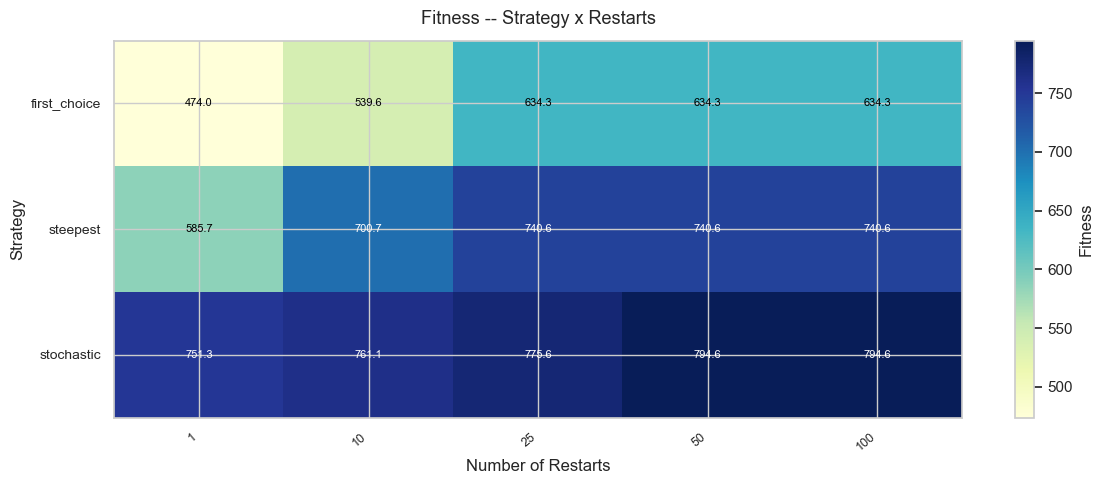

  [OK] e:\School project\Intro_to_AI_Travel_Project\Tests\hill_climbing_test_results\heatmap_strategy_restarts.png


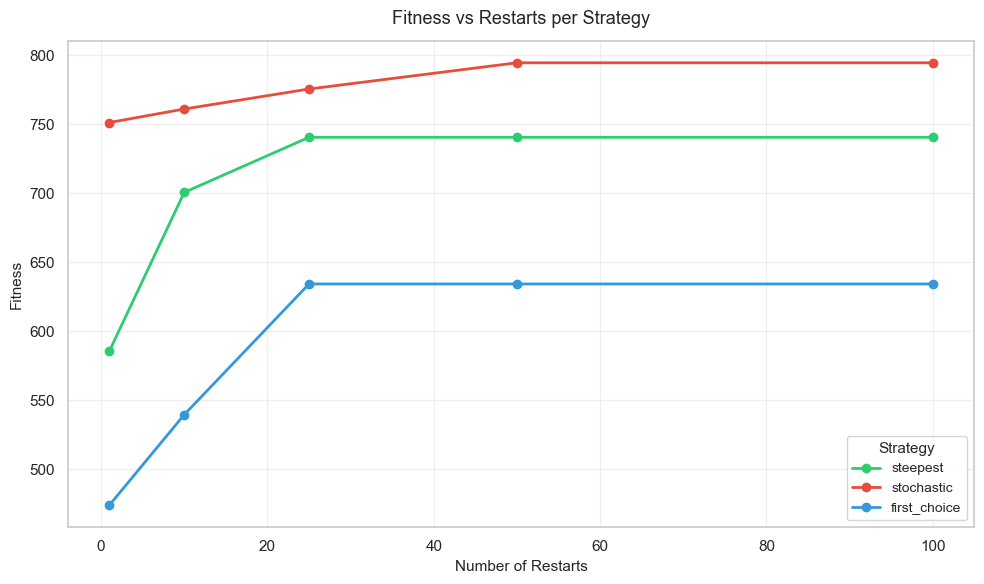

  [OK] e:\School project\Intro_to_AI_Travel_Project\Tests\hill_climbing_test_results\line_fitness_restarts.png


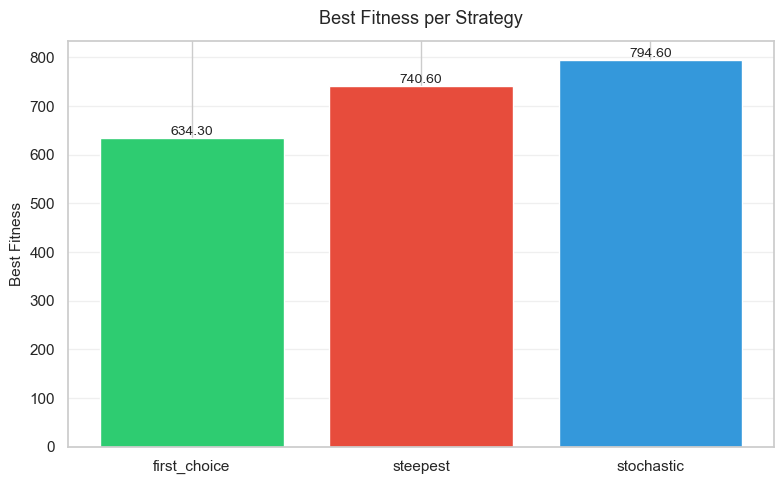

  [OK] e:\School project\Intro_to_AI_Travel_Project\Tests\hill_climbing_test_results\bar_best_fitness_strategy.png


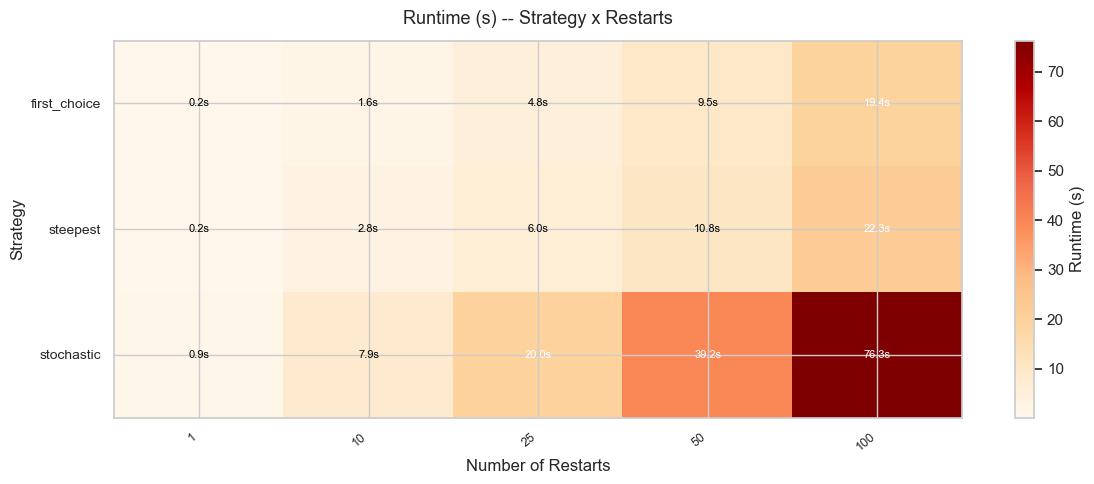

  [OK] e:\School project\Intro_to_AI_Travel_Project\Tests\hill_climbing_test_results\heatmap_runtime.png


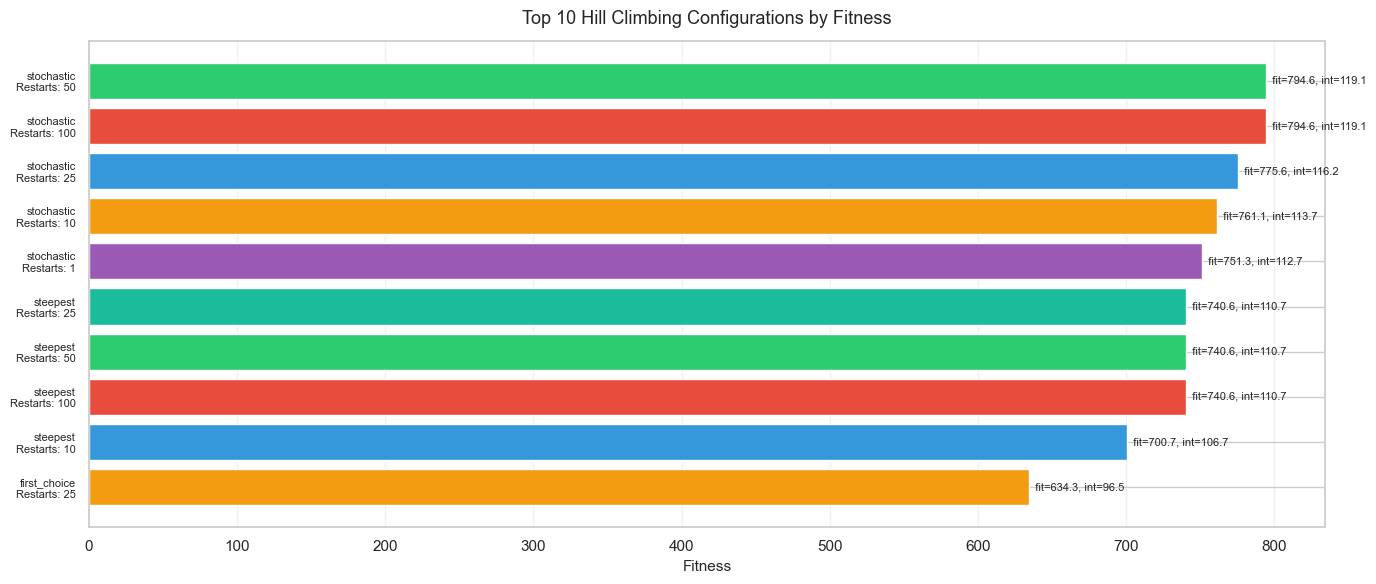

  [OK] e:\School project\Intro_to_AI_Travel_Project\Tests\hill_climbing_test_results\top10_configs.png

SUMMARY -- Top 15 Configurations (by Fitness)
    Strategy  Restarts  Fitness  Interest  TotalTime_h  NumLandmarks  Runtime_s
  stochastic        50    794.6     119.1         7.99            15      39.22
  stochastic       100    794.6     119.1         7.99            15      76.32
  stochastic        25    775.6     116.2         7.96            14      20.01
  stochastic        10    761.1     113.7         7.91            14       7.92
  stochastic         1    751.3     112.7         7.71            14       0.91
    steepest        25    740.6     110.7         7.99            13       5.97
    steepest        50    740.6     110.7         7.99            13      10.82
    steepest       100    740.6     110.7         7.99            13      22.26
    steepest        10    700.7     106.7         7.94            13       2.75
first_choice        25    634.3      96.5         

In [81]:
#code for the algorithm
"""
hill_climbing_test
=========================================================
Tests the Hill Climbing algorithm across multiple:
  Base strategies          (steepest, stochastic, first_choice)
  Number of restarts       (1, 10, 25, 50, 100)
"""
%matplotlib inline
# ── project imports ──────────────────────────────────────────────────────────
current_dir = os.getcwd()

# ── data loading ─────────────────────────────────────────────────────────────
landmarks = get_landmarks()
hotels     = get_hotels()
time_matrix = get_time_matrix()

# ── problem setup ─────────────────────────────────────────────────────────────
problem = TravelProblem_LocalSearch(
    landmarks,
    travel_information={
        'hotel': hotels[0],
        'time_matrix': time_matrix,
        'Travel_Time': 8,
        'Travel_day': 'mon',
        'type_filter': None,
        'trip_start_time': 9,
    },
)

# ── parameters ───────────────────────────────────────────────────────────
Base_strategies    = ['steepest', 'stochastic', 'first_choice']
Num_restarts_values = [1, 10, 25, 50, 100]

SEED = 42

# ── output directory ─────────────────────────────────────────────────────────
OUTPUT_DIR = os.path.join(current_dir, "Tests", "hill_climbing_test_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ═════════════════════════════════════════════════════════════════════════════
# 1.  Full test: strategies × restarts
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 1 -- Full Test: Strategies x Restarts")
print("=" * 70)

rows_full = []
total_combos = len(Base_strategies) * len(Num_restarts_values)
combo_idx = 0

for strategy in Base_strategies:
    for restarts in Num_restarts_values:
        combo_idx += 1
        random.seed(SEED)
        hc = hill_climbing(problem, num_restarts=restarts, base_strategy=strategy)
        t0 = time.time()
        best = hc.run()
        elapsed = time.time() - t0
        fitness   = hc.evaluate(best.state)
        interest = sum(lm.interest_score for lm in best.state)
        tot_time  = round(hc.calculate_total_time(best.state), 2)
        n_lm      = len(best.state)
        rows_full.append({
            'Strategy': strategy,
            'Restarts': restarts,
            'Fitness':   round(fitness, 4),
            'Interest':    round(interest, 2),
            'TotalTime_h': tot_time,
            'NumLandmarks': n_lm,
            'Runtime_s':   round(elapsed, 2),
        })
        print(f"  [{combo_idx:3d}/{total_combos}]  {strategy:12s} | restarts={restarts:3d}"
              f"  ->  Interest={interest:7.2f} Fitness={fitness:7.2f}"
              f"time={tot_time:5.2f}h  #lm={n_lm}  ({elapsed:.1f}s)")

df_full = pd.DataFrame(rows_full)
csv_path = os.path.join(OUTPUT_DIR, "full_results.csv")
df_full.to_csv(csv_path, index=False)
print(f"\n[OK] Full results saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 2.  Restarts sweep for each strategy
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 2 -- Restarts Sweep per Strategy")
print("=" * 70)

rows_restart = []
for strategy in Base_strategies:
    for restarts in Num_restarts_values:
        random.seed(SEED)
        hc = hill_climbing(problem, num_restarts=restarts, base_strategy=strategy)
        t0 = time.time()
        best = hc.run()
        elapsed = time.time() - t0
        fitness  = hc.evaluate(best.state)
        interest = sum(lm.interest_score for lm in best.state)
        tot_time = round(hc.calculate_total_time(best.state), 2)
        n_lm     = len(best.state)
        rows_restart.append({
            'Strategy': strategy,
            'Restarts': restarts,
            'Fitness':     round(fitness, 4),
            'Interest':    round(interest, 2),
            'TotalTime_h': tot_time,
            'NumLandmarks': n_lm,
            'Runtime_s':   round(elapsed, 2),
        })
    print(f"  [OK] {strategy} restarts sweep completed")

df_restart = pd.DataFrame(rows_restart)
csv_path = os.path.join(OUTPUT_DIR, "restarts_sweep.csv")
df_restart.to_csv(csv_path, index=False)
print(f"  [OK] saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 3.  PLOTS
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 3 -- Generating Plots")
print("=" * 70)

# ── colour palette ───────────────────────────────────────────────────────────
COLORS = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

# ---------- Plot 1: Heatmap — fitness for each (Strategy × Restarts) ----------
fig, ax = plt.subplots(figsize=(12, 5))
pivot = df_full.pivot(index='Strategy', columns='Restarts', values='Fitness')
im = ax.imshow(pivot.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8,
                color='white' if val > pivot.values.mean() else 'black')
fig.colorbar(im, ax=ax, label='Fitness')
ax.set_title('Fitness -- Strategy x Restarts', fontsize=13, pad=12)
ax.set_xlabel('Number of Restarts')
ax.set_ylabel('Strategy')
plt.tight_layout()
path1 = os.path.join(OUTPUT_DIR, "heatmap_strategy_restarts.png")
fig.savefig(path1, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path1}")

# ---------- Plot 2: Line chart — fitness vs restarts per strategy ----------
fig, ax = plt.subplots(figsize=(10, 6))
for i, strategy in enumerate(Base_strategies):
    subset = df_restart[df_restart['Strategy'] == strategy]
    ax.plot(subset['Restarts'], subset['Fitness'], 'o-', color=COLORS[i % len(COLORS)], linewidth=2, markersize=6, label=strategy)
ax.set_xlabel('Number of Restarts', fontsize=11)
ax.set_ylabel('Fitness', fontsize=11)
ax.set_title('Fitness vs Restarts per Strategy', fontsize=13, pad=12)
ax.legend(title='Strategy', fontsize=10, title_fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
path2 = os.path.join(OUTPUT_DIR, "line_fitness_restarts.png")
fig.savefig(path2, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path2}")

# ---------- Plot 3: Bar chart — best fitness per strategy ----------
best_per_strategy = df_full.groupby('Strategy')['Fitness'].max()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(best_per_strategy.index, best_per_strategy.values, color=COLORS[:len(Base_strategies)])
ax.set_ylabel('Best Fitness', fontsize=11)
ax.set_title('Best Fitness per Strategy', fontsize=13, pad=12)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, best_per_strategy.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
path3 = os.path.join(OUTPUT_DIR, "bar_best_fitness_strategy.png")
fig.savefig(path3, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path3}")

# ---------- Plot 4: Runtime heatmap — Strategy × Restarts ----------
fig, ax = plt.subplots(figsize=(12, 5))
pivot_rt = df_full.pivot(index='Strategy', columns='Restarts', values='Runtime_s')
im = ax.imshow(pivot_rt.values, cmap='OrRd', aspect='auto')
ax.set_xticks(range(len(pivot_rt.columns)))
ax.set_xticklabels(pivot_rt.columns, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_rt.index)))
ax.set_yticklabels(pivot_rt.index, fontsize=10)
for i in range(len(pivot_rt.index)):
    for j in range(len(pivot_rt.columns)):
        val = pivot_rt.values[i, j]
        ax.text(j, i, f'{val:.1f}s', ha='center', va='center', fontsize=8,
                color='white' if val > pivot_rt.values.mean() else 'black')
fig.colorbar(im, ax=ax, label='Runtime (s)')
ax.set_title('Runtime (s) -- Strategy x Restarts', fontsize=13, pad=12)
ax.set_xlabel('Number of Restarts')
ax.set_ylabel('Strategy')
plt.tight_layout()
path4 = os.path.join(OUTPUT_DIR, "heatmap_runtime.png")
fig.savefig(path4, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path4}")

# ---------- Plot 5: Top 10 configurations ----------
top10 = df_full.nlargest(10, 'Fitness')
fig, ax = plt.subplots(figsize=(14, 6))
labels_top = [f"{r['Strategy']}\nRestarts: {r['Restarts']}" for _, r in top10.iterrows()]
bars = ax.barh(range(len(top10)), top10['Fitness'], color=COLORS * 2)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(labels_top, fontsize=8)
ax.set_xlabel('Fitness', fontsize=11)
ax.set_title('Top 10 Hill Climbing Configurations by Fitness', fontsize=13, pad=12)
for i, (val, interest) in enumerate(zip(top10['Fitness'], top10['Interest'])):
    ax.text(val + 0.1, i, f'  fit={val:.1f}, int={interest:.1f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
path5 = os.path.join(OUTPUT_DIR, "top10_configs.png")
fig.savefig(path5, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path5}")

# ═════════════════════════════════════════════════════════════════════════════
# 4.  SUMMARY TABLE  (printed to console)
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("SUMMARY -- Top 15 Configurations (by Fitness)")
print("=" * 70)
top15 = df_full.nlargest(15, 'Fitness')
print(top15.to_string(index=False))

print("\n" + "=" * 70)
print("Restarts Sweep Results")
print("=" * 70)
print(df_restart.to_string(index=False))

print("\n[DONE] All done! Results & plots saved in:", OUTPUT_DIR)


### ***Ant Colony System Test***

explanation and docuementation

In [10]:

# Add project root to path
try:
    _BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    _BASE_DIR = Path().resolve().parent 

if str(_BASE_DIR) not in sys.path:
    sys.path.insert(0, str(_BASE_DIR))


from utils.data_loader import get_landmarks, get_hotels, get_time_matrix

ALGO_NAME = "Ant Colony System (ACS)"

def calculate_unified_score(path, time_matrix):
    if not path: return 0
    total_rating = sum(node.interest_score for node in path if isinstance(node, Landmark))
    total_travel_time = sum(time_matrix[path[i].name][path[i+1].name] for i in range(len(path) - 1))
    return (7 * total_rating) - total_travel_time

def run_acs_notebook_study():
    landmarks = get_landmarks()
    hotels = get_hotels()
    time_matrix = get_time_matrix()
    days = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]


    selected_hotel = random.choice(hotels)
    visiting_day = random.choice(days)
    time_budget_hours = 8.0
    trip_start_time = 9

    print("=" * 80)
    print("🌍 TRAVEL ENVIRONMENT & CONSTRAINTS 🌍".center(80))
    print("=" * 80)
    print(f"🏨 Hotel       : {selected_hotel.name}")
    print(f"📅 Day         : {visiting_day.capitalize()}")
    print(f"⏰ Start Time  : {trip_start_time}:00 AM")
    print(f"⏳ Budget      : {time_budget_hours} hours")
    print("=" * 80 + "\n")

    alphas = [0.2 ,0.5, 1.0]       
    betas = [2.5 , 3.0, 4.0]        
    rhos = [0.05, 0.3]         
    num_ants_list = [40, 50, 60]       
    generations_list = [80, 100, 120]
    
    param_results = []
    overall_best_score = -float('inf')
    overall_best_path = [] 
    
    total_combinations = len(alphas) * len(betas) * len(rhos) * len(num_ants_list) * len(generations_list)
    print(f"🚀 Executing Grid Search ({total_combinations} configurations)...\n")
    print("-" * 110)
    
    start_global_time = time.time()
    current_iteration = 0

    for alpha, beta, rho, ants, gens in itertools.product(alphas, betas, rhos, num_ants_list, generations_list):
        current_iteration += 1
        
        # Professional configuration tracker
        print(f"[{current_iteration:02d}/{total_combinations}] Testing a={alpha:<3} | b={beta:<3} | p={rho:<4} | Ants={ants:<2} | Gens={gens:<3}")
        
        scores, times, visits = [], [], []
        
        for run_id in range(3):
            env = ACSEnvironment(
                hotel=selected_hotel, 
                landmarks=landmarks, 
                time_matrix=time_matrix, 
                time_budget_hours=time_budget_hours, 
                trip_start_time_hours=trip_start_time, 
                visiting_day=visiting_day
            )
            acs = AntColonySystem(env, num_ants=ants, generations=gens, alpha=alpha, beta=beta, rho=rho)
            
            start_t = time.time()
            best_path, _ = acs.solve()  
            exec_time = time.time() - start_t
            
            score = calculate_unified_score(best_path, time_matrix)
            num_landmarks_visited = len([node for node in best_path if isinstance(node, Landmark)])
            
            scores.append(score)
            times.append(exec_time)
            visits.append(num_landmarks_visited)
            
            # Check for a new global best and print detailed info
            if score > overall_best_score:
                overall_best_score = score
                overall_best_path = best_path
                total_rating = sum(node.interest_score for node in best_path if isinstance(node, Landmark))
                
                print(f"   >>> 🌟 NEW GLOBAL BEST! Eval Score: {score:.2f} | Rating: {total_rating:.1f} | Visited: {num_landmarks_visited} | Runtime: {exec_time:.2f}s")
                print(f"   >>> ⚙️  Params Used: a={alpha}, b={beta}, p={rho}, Ants={ants}, Gens={gens}\n")
            
        param_results.append({
            "Alpha": alpha, "Beta": beta, "Rho": rho, "Ants": ants, "Generations": gens,
            "Avg_Score": sum(scores)/3, "Avg_Time_Sec": sum(times)/3, "Avg_Visited": sum(visits)/3
        })

    print("-" * 110)
    print(f"✅ Grid search completed in {time.time() - start_global_time:.2f} seconds!\n")

    # Best Path Extraction
    best_rating_sum = sum(node.interest_score for node in overall_best_path if isinstance(node, Landmark))
    best_travel_time_min = sum(time_matrix[overall_best_path[i].name][overall_best_path[i+1].name] for i in range(len(overall_best_path) - 1))

    print("=" * 80)
    print("🏆 OVERALL BEST ROUTE FOUND 🏆".center(80))
    print("=" * 80)
    print(f"🏅 Final Eval Score   : {overall_best_score:.2f}")
    print(f"⭐ Sum of Ratings     : {best_rating_sum:.2f}")
    print(f"🚗 Total Travel Time  : {best_travel_time_min:.1f} minutes ({best_travel_time_min/60.0:.2f} hours)")
    print(f"📍 Places Visited     : {len([n for n in overall_best_path if isinstance(n, Landmark)])} landmarks")
    print("-" * 80)
    print("🗺️  STEP-BY-STEP ITINERARY:")
    for i, node in enumerate(overall_best_path):
        if i == 0: print(f"   🛫 START : {node.name} (Hotel)")
        elif i == len(overall_best_path) - 1: print(f"   🛬 END   : {node.name} (Return to Hotel)")
        else: print(f"      -> {node.name} (Rating: {node.interest_score})")
    print("=" * 80 + "\n")

    # Plots
    df_params = pd.DataFrame(param_results)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle(f"{ALGO_NAME}: Parameter Tuning Analysis", fontsize=18, weight='bold')

    sns.heatmap(df_params.pivot_table(index="Alpha", columns="Beta", values="Avg_Score", aggfunc='mean'), annot=True, cmap="magma", fmt=".1f", ax=axes[0, 0]).set_title("Evaluation Score")
    sns.heatmap(df_params.pivot_table(index="Alpha", columns="Beta", values="Avg_Visited", aggfunc='mean'), annot=True, cmap="crest", fmt=".1f", ax=axes[0, 1]).set_title("Avg Landmarks Visited")
    sns.heatmap(df_params.pivot_table(index="Alpha", columns="Beta", values="Avg_Time_Sec", aggfunc='mean'), annot=True, cmap="OrRd", fmt=".2f", ax=axes[1, 0]).set_title("Runtime (Seconds)")
    sns.lineplot(data=df_params, x="Ants", y="Avg_Score", hue="Generations", marker="s", palette="Set1", ax=axes[1, 1]).set_title("Impact of Ants & Generations on Score")
    axes[1, 1].set_xticks(num_ants_list) 
    sns.lineplot(data=df_params, x="Ants", y="Avg_Time_Sec", hue="Generations", marker="o", palette="crest", ax=axes[2, 0]).set_title("Execution Time Scaling")
    axes[2, 0].set_xticks(num_ants_list)

    fig.delaxes(axes[2, 1])
    plt.tight_layout()
    plt.subplots_adjust(top=0.94) 
    plt.show()

if __name__ == "__main__":
    run_acs_notebook_study()

                      🌍 TRAVEL ENVIRONMENT & CONSTRAINTS 🌍                      
🏨 Hotel       : Hôtel El-Djazaïr – El Harrache
📅 Day         : Fri
⏰ Start Time  : 9:00 AM
⏳ Budget      : 8.0 hours

🚀 Executing Grid Search (162 configurations)...

--------------------------------------------------------------------------------------------------------------
[01/162] Testing a=0.2 | b=2.5 | p=0.05 | Ants=40 | Gens=80 


NameError: name 'ACSEnvironment' is not defined

### ***Hybrid SA-ACS Test***

The Hybrid SA-ACS (Simulated Annealing - Ant Colony System) algorithm combines the global search capabilities of Ant Colony optimization with the local refinement power of Simulated Annealing. This hybrid approach is designed to solve the Traveling Salesperson Problem (TSP) with time constraints by first using ACS to discover high-quality regions of the search space and then applying SA to fine-tune the paths.

#### **Testing Methodology**
To validate the performance and scalability of the Hybrid SA-ACS algorithm, we conduct a rigorous testing phase consisting of:

1.  **Parameter Sensitivity Study**:
    -   We analyze the interaction between ACS parameters (e.g., number of ants, pheromone decay $\rho$) and SA parameters (e.g., initial temperature, cooling rate).
    -   The goal is to find the balance where ACS provides a strong initial structure and SA effectively optimizes the local sequence.

2.  **Scalability Analysis (Problem Size)**:
    -   The algorithm is tested against increasing dataset sizes (e.g., 20, 40, 60, and 80 landmarks).
    -   We monitor **Execution Time** vs. **Solution Quality** to ensure the hybrid approach maintains efficiency as the complexity grows.

3.  **Comparative Evaluation**:
    -   The results are compared against standalone Simulated Annealing and standalone Ant Colony System implementations.
    -   Metrics used: **Unified Score** (Evaluation Score), **Total Interest Rating**, and **Travel Time Efficiency**.

#### **Key Performance Indicators (KPIs)**
-   **Convergence Speed**: How many iterations are required to find a stable "best" route.
-   **Local Optima Escape**: Effectiveness of the SA component in improving the raw paths generated by the ants.
-   **Constraint Adherence**: Verification that the 8-hour time budget is maintained while maximizing landmark density.


In [12]:

# Add project root to path
try:
    _BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    _BASE_DIR = Path().resolve().parent

if str(_BASE_DIR) not in sys.path:
    sys.path.insert(0, str(_BASE_DIR))


from utils.data_loader import get_landmarks, get_hotels, get_time_matrix

ALGO_NAME = "Hybrid-ACS-SA"

# Unified Score Function
def calculate_unified_score(path, time_matrix):
    if not path: return 0
    total_rating = sum(node.interest_score for node in path if isinstance(node, Landmark))
    total_travel_time = sum(time_matrix[path[i].name][path[i+1].name] for i in range(len(path) - 1))
    return (7 * total_rating) - total_travel_time

def run_hybrid_notebook_study():
    landmarks = get_landmarks()
    hotels = get_hotels()
    time_matrix = get_time_matrix()
    days = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]

    selected_hotel = random.choice(hotels)
    visiting_day = random.choice(days)
    time_budget_hours = 8.0
    trip_start_time = 9

    print("=" * 80)
    print(f"🌍 {ALGO_NAME} ENVIRONMENT & CONSTRAINTS 🌍".center(80))
    print("=" * 80)
    print(f"🏨 Hotel       : {selected_hotel.name}")
    print(f"📅 Day         : {visiting_day.capitalize()}")
    print(f"⏰ Start Time  : {trip_start_time}:00 AM")
    print(f"⏳ Budget      : {time_budget_hours} hours")
    print("=" * 80 + "\n")

    # Parameter Ranges: Focusing heavily on the scaling of Ants and Generations
    num_ants_list = [30, 40, 50]
    generations_list = [80, 100, 120]
    
    # Locking best standard ACS variables found previously
    best_alpha, best_beta, best_rho = 0.5, 3.0, 0.3
    #1.5 3.0 0.05
    
    param_results = []
    overall_best_score = -float('inf')
    overall_best_path = []
    
    total_combinations = len(num_ants_list) * len(generations_list)
    print(f"🚀 Executing Hybrid Grid Search ({total_combinations} configurations)...\n")
    print(f"📌 Locked Params: a={best_alpha}, b={best_beta}, p={best_rho} | SA Logic: Embedded")
    print("-" * 110)
    
    start_global_time = time.time()
    current_iteration = 0

    for ants, gens in itertools.product(num_ants_list, generations_list):
        current_iteration += 1
        
        # Professional configuration tracker
        print(f"[{current_iteration:02d}/{total_combinations}] Testing Ants={ants:<2} | Gens={gens:<3}")
        
        scores, times, visits = [], [], []
        
        for run_id in range(3):
            env = ACSEnvironment(
                hotel=selected_hotel, 
                landmarks=landmarks, 
                time_matrix=time_matrix, 
                time_budget_hours=time_budget_hours, 
                trip_start_time_hours=trip_start_time, 
                visiting_day=visiting_day
            )
            
            # Initialize with hybrid_sa=True
            acs_hybrid = AntColonySystem(
                env, 
                num_ants=ants, 
                generations=gens, 
                alpha=best_alpha, 
                beta=best_beta, 
                rho=best_rho, 
                hybrid_sa=True
            )
            
            start_t = time.time()
            best_path, _ = acs_hybrid.solve() 
            exec_time = time.time() - start_t
            
            score = calculate_unified_score(best_path, time_matrix)
            num_landmarks_visited = len([node for node in best_path if isinstance(node, Landmark)])
            
            scores.append(score)
            times.append(exec_time)
            visits.append(num_landmarks_visited)
            
            # Check for a new global best and print detailed info
            if score > overall_best_score:
                overall_best_score = score
                overall_best_path = best_path
                total_rating = sum(node.interest_score for node in best_path if isinstance(node, Landmark))
                
                print(f"   >>> 🌟 NEW GLOBAL BEST! Eval Score: {score:.2f} | Rating: {total_rating:.1f} | Visited: {num_landmarks_visited} | Runtime: {exec_time:.2f}s")
                print(f"   >>> ⚙️  Params Used: Ants={ants}, Gens={gens} (Hybrid-SA Enabled)\n")
            
        param_results.append({
            "Ants": ants, "Generations": gens,
            "Avg_Score": sum(scores)/3, "Avg_Time_Sec": sum(times)/3, "Avg_Visited": sum(visits)/3
        })

    print("-" * 110)
    print(f"✅ Grid search completed in {time.time() - start_global_time:.2f} seconds!\n")

    # Best Path Extraction
    best_rating_sum = sum(node.interest_score for node in overall_best_path if isinstance(node, Landmark))
    best_travel_time_min = sum(time_matrix[overall_best_path[i].name][overall_best_path[i+1].name] for i in range(len(overall_best_path) - 1))

    print("=" * 80)
    print("🏆 OVERALL BEST ROUTE FOUND 🏆".center(80))
    print("=" * 80)
    print(f"🏅 Final Eval Score   : {overall_best_score:.2f}")
    print(f"⭐ Sum of Ratings     : {best_rating_sum:.2f}")
    print(f"🚗 Total Travel Time  : {best_travel_time_min:.1f} minutes ({best_travel_time_min/60.0:.2f} hours)")
    print(f"📍 Places Visited     : {len([n for n in overall_best_path if isinstance(n, Landmark)])} landmarks")
    print("-" * 80)
    print("🗺️  STEP-BY-STEP ITINERARY:")
    for i, node in enumerate(overall_best_path):
        if i == 0: print(f"   🛫 START : {node.name} (Hotel)")
        elif i == len(overall_best_path) - 1: print(f"   🛬 END   : {node.name} (Return to Hotel)")
        else: print(f"      -> {node.name} (Rating: {node.interest_score})")
    print("=" * 80 + "\n")

    # ---------------------------------------------------------
    # Professional 2x2 Plots directly in Output
    # ---------------------------------------------------------
    df_params = pd.DataFrame(param_results)
    df_params['Config'] = df_params['Ants'].astype(str) + "x" + df_params['Generations'].astype(str)
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"{ALGO_NAME}: Scaling & Performance Analysis", fontsize=16, weight='bold')

    # Top Left: Evaluation Score
    sns.heatmap(df_params.pivot_table(index="Ants", columns="Generations", values="Avg_Score", aggfunc='mean'), 
                annot=True, cmap="magma", fmt=".1f", ax=axes[0, 0]).set_title("Evaluation Score")
    
    # Top Right: Avg Landmarks Visited
    sns.heatmap(df_params.pivot_table(index="Ants", columns="Generations", values="Avg_Visited", aggfunc='mean'), 
                annot=True, cmap="crest", fmt=".1f", ax=axes[0, 1]).set_title("Avg Landmarks Visited")
    
    # Bottom Left: Runtime
    sns.heatmap(df_params.pivot_table(index="Ants", columns="Generations", values="Avg_Time_Sec", aggfunc='mean'), 
                annot=True, cmap="OrRd", fmt=".2f", ax=axes[1, 0]).set_title("Runtime (Seconds)")

    # Bottom Right: Dual Axis (Score vs Time)
    ax_line1 = axes[1, 1]
    color1 = 'tab:blue'
    sns.lineplot(data=df_params, x='Config', y='Avg_Score', marker='D', color=color1, ax=ax_line1, label='Score')
    ax_line1.set_ylabel('Evaluation Score', color=color1)
    ax_line1.tick_params(axis='y', labelcolor=color1)
    ax_line1.set_title("Evaluation Score vs Runtime Cost")
    
    # Add second y-axis for time
    ax_line2 = ax_line1.twinx()
    color2 = 'tab:red'
    sns.lineplot(data=df_params, x='Config', y='Avg_Time_Sec', marker='o', color=color2, ax=ax_line2, label='Time (Sec)')
    ax_line2.set_ylabel('Execution Time (sec)', color=color2)
    ax_line2.tick_params(axis='y', labelcolor=color2)
    
    # Handle legends so they don't overlap awkwardly
    lines_1, labels_1 = ax_line1.get_legend_handles_labels()
    lines_2, labels_2 = ax_line2.get_legend_handles_labels()
    ax_line1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    ax_line2.get_legend().remove()

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

if __name__ == "__main__":
    run_hybrid_notebook_study()

                  🌍 Hybrid-ACS-SA ENVIRONMENT & CONSTRAINTS 🌍                   
🏨 Hotel       : Dar El Aaz - Bab Ezzouar
📅 Day         : Sat
⏰ Start Time  : 9:00 AM
⏳ Budget      : 8.0 hours

🚀 Executing Hybrid Grid Search (9 configurations)...

📌 Locked Params: a=0.5, b=3.0, p=0.3 | SA Logic: Embedded
--------------------------------------------------------------------------------------------------------------
[01/9] Testing Ants=30 | Gens=80 


NameError: name 'ACSEnvironment' is not defined

### ***CSP Test***

**Documentation:**

Loading data …

── Test A: All hotels × all days ──
  Progress: 1267/1267  (Moncada Hotel / wed)   d)   

  Test A Summary:


,Day,Avg Score,± Std Score,Avg Time (s),± Std Time
0,Fri,67.6,3.3,0.491,0.220
1,Mon,67.6,3.3,0.500,0.199
2,Sat,67.6,3.3,0.497,0.235
3,Sun,62.2,6.0,0.483,0.171
4,Thu,67.6,3.3,0.473,0.178
5,Tue,67.6,3.3,0.492,0.212
6,Wed,67.6,3.3,0.486,0.193


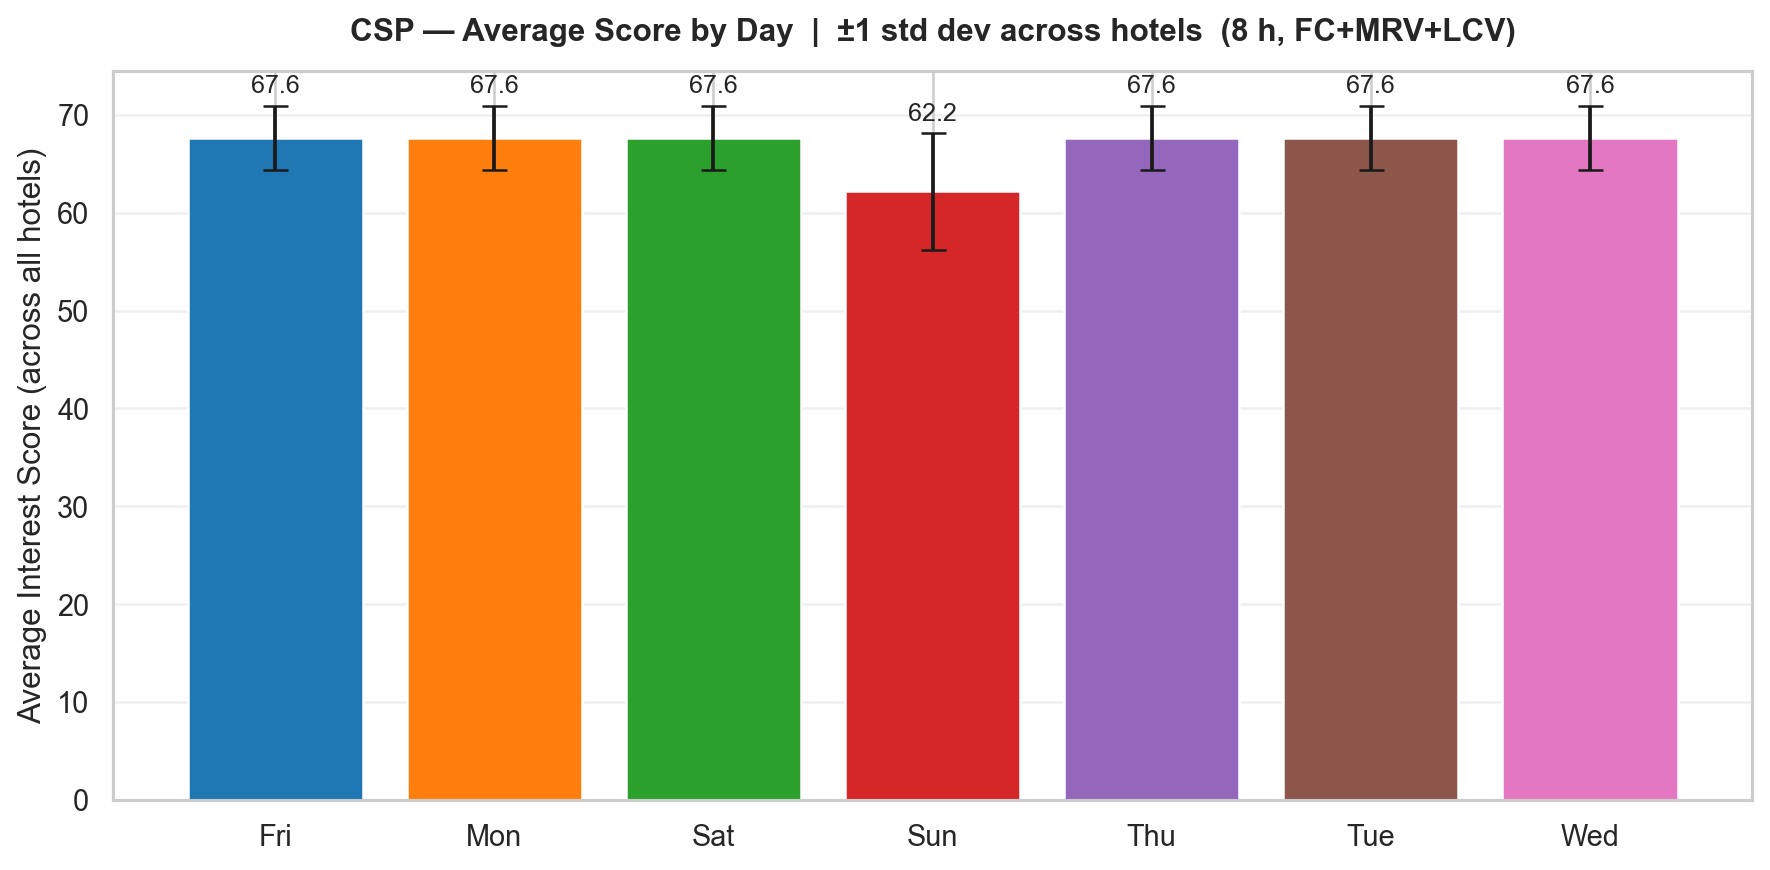

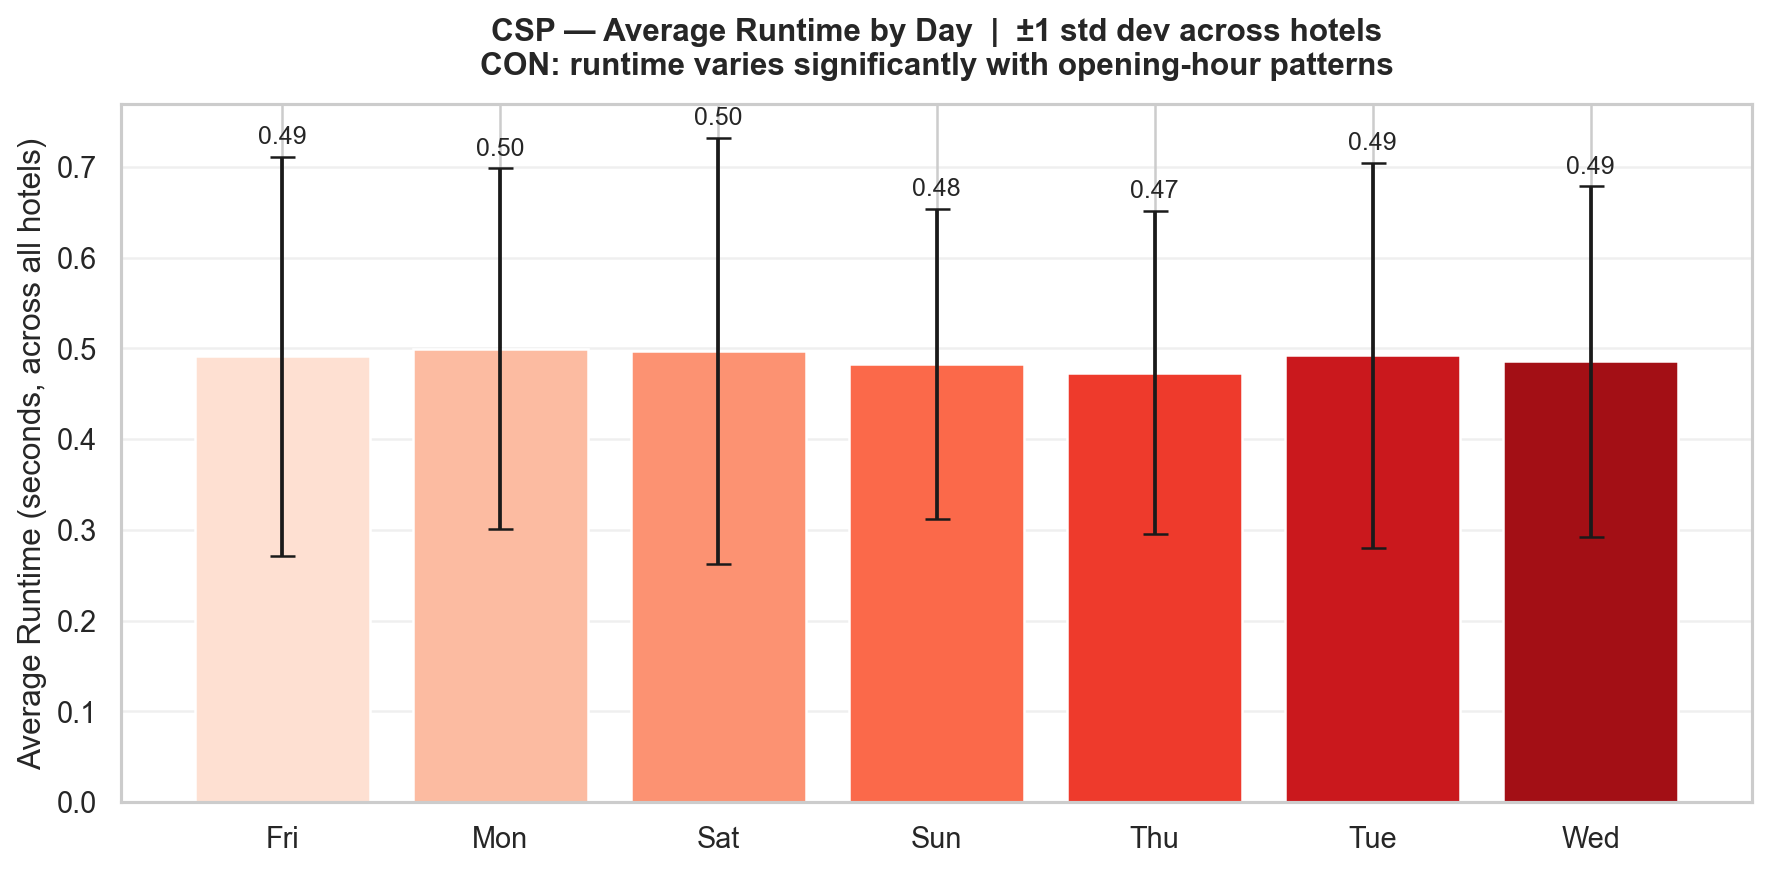

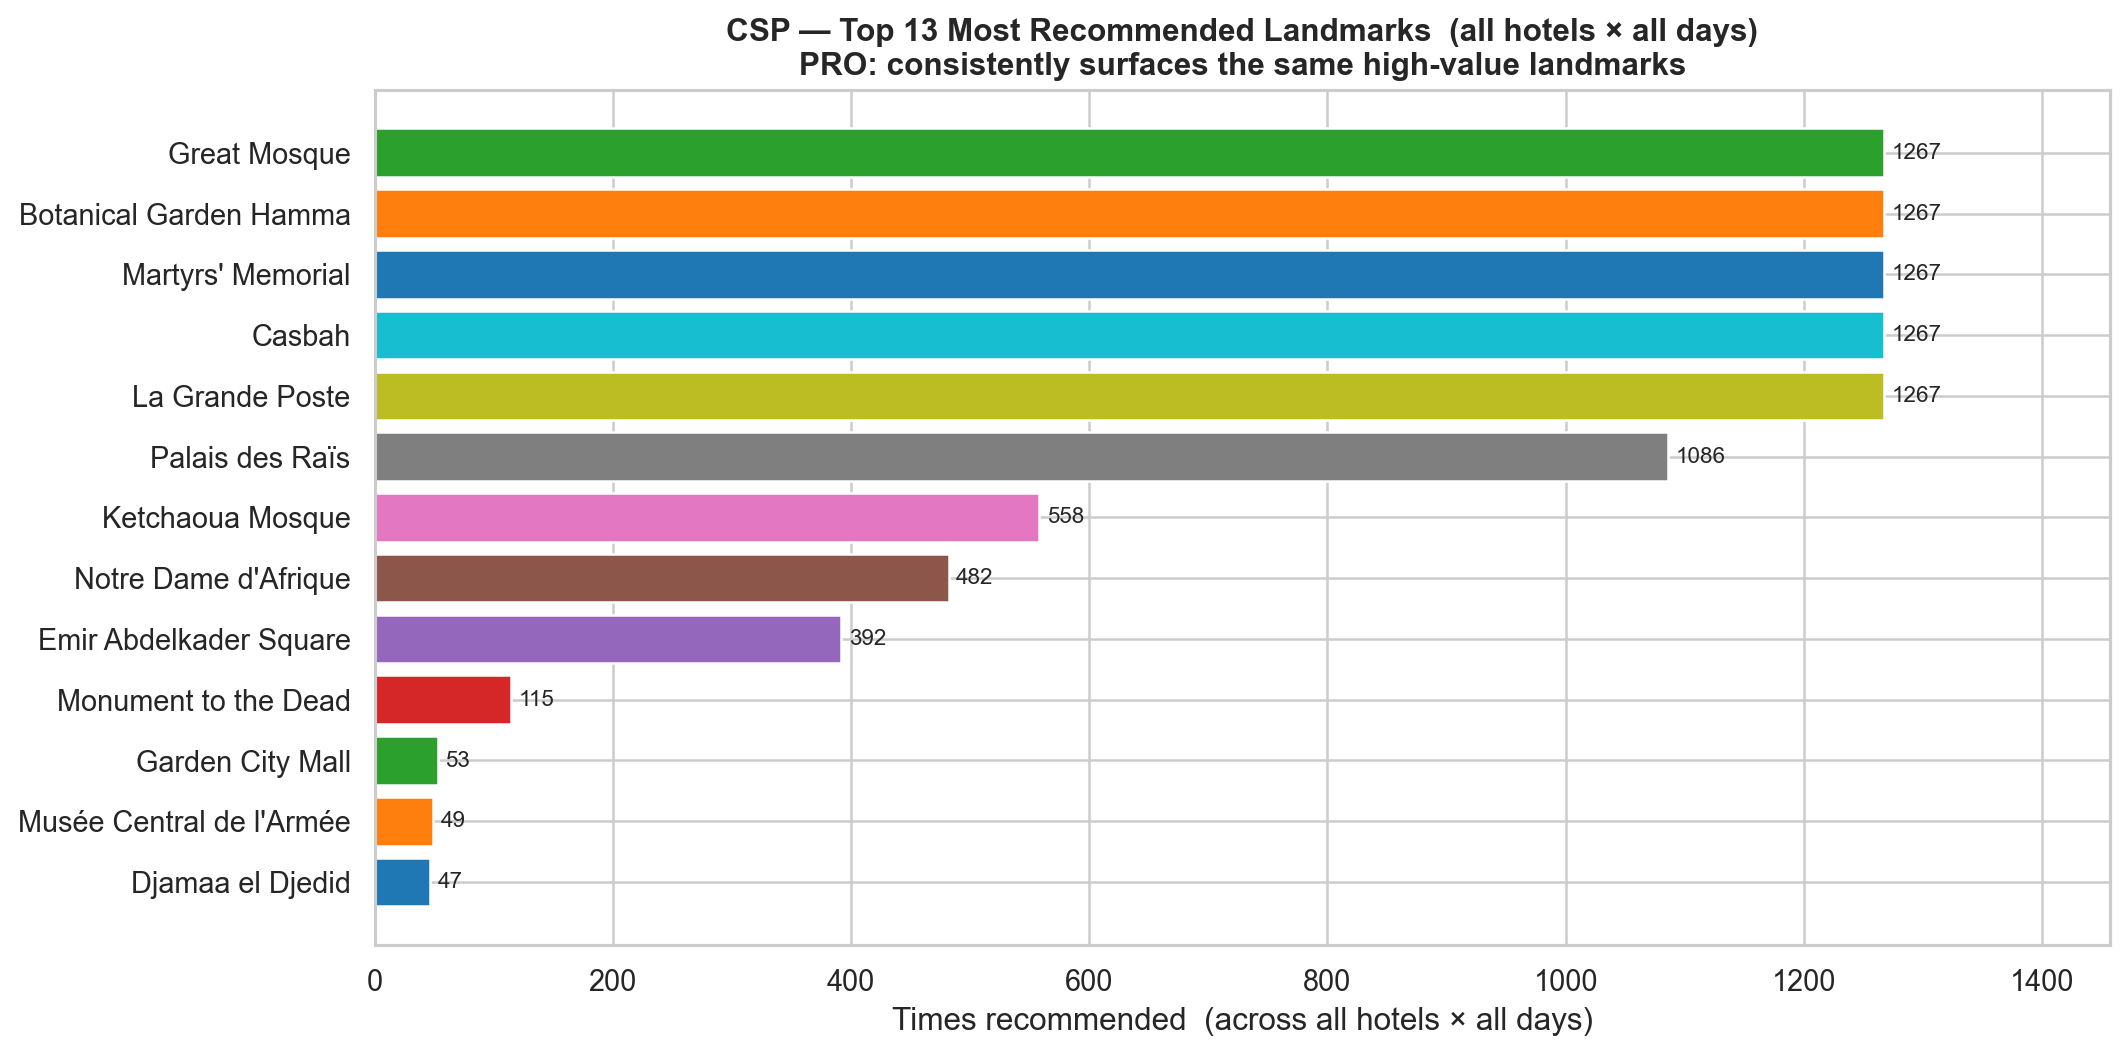


── Test B: Heuristic comparison ──
  Testing FC|MRV|LCV         … done
  Testing FC|MRV|NONE        … done
  Testing FC|NONE|LCV        … done
  Testing FC|NONE|NONE       … done
  Testing MAC|MRV|LCV        … done
  Testing MAC|MRV|NONE       … done
  Testing MAC|NONE|LCV       … done
  Testing MAC|NONE|NONE      … done

  Test B Summary:


,label,score,assigns,time_sec,visited
0,FC|MRV|LCV,65.9,66,0.9186,7
1,FC|MRV|NONE,65.9,66,0.4740,7
2,FC|NONE|LCV,65.9,66,0.4681,7
3,FC|NONE|NONE,65.9,66,0.4490,7
4,MAC|MRV|LCV,65.9,66,3.1502,7
5,MAC|MRV|NONE,65.9,66,3.6938,7
6,MAC|NONE|LCV,65.9,66,4.1456,7
7,MAC|NONE|NONE,65.9,66,4.6437,7


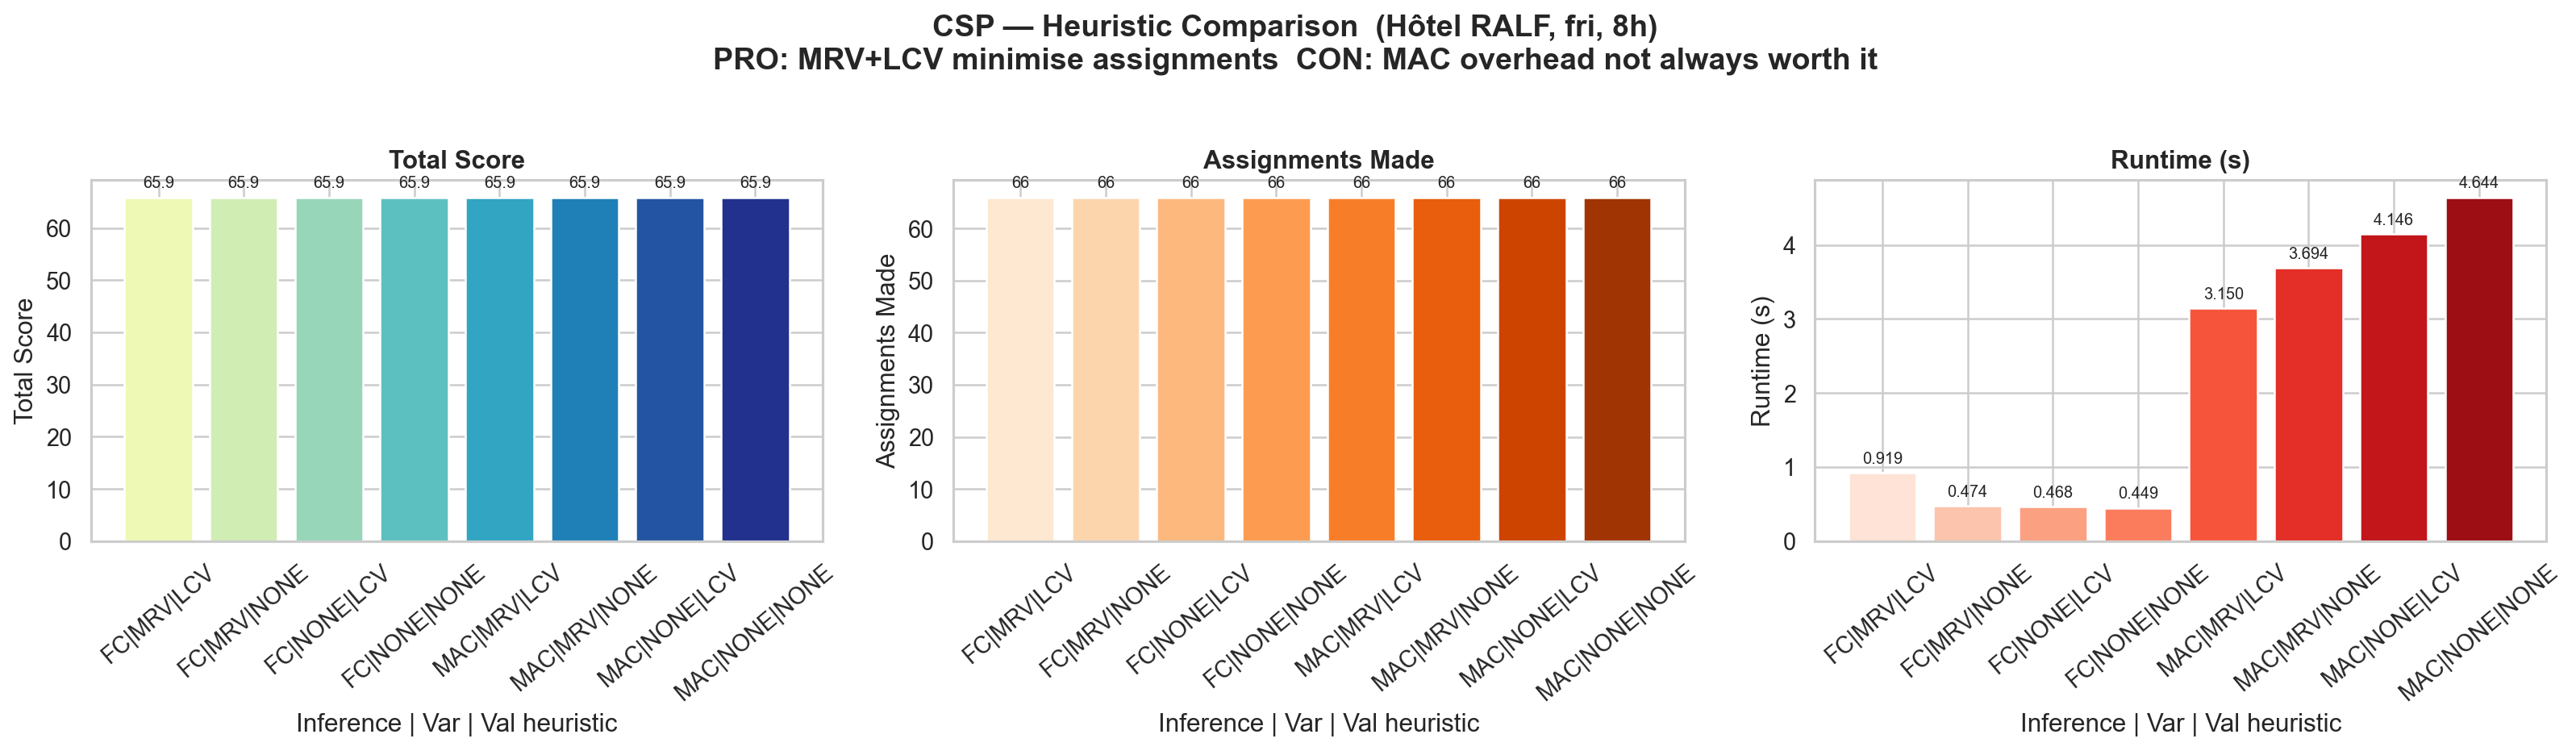


All done. Figures saved to: c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\CSP-test-results


In [19]:

from __future__ import annotations

import io
import os
import sys
import time
import gc
import itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from IPython.display import display, Image

project_root = os.getcwd()                            # notebook dir = project root
TESTS_DIR    = os.path.join(project_root, "Tests")   # Tests/ is a subdirectory
sys.path.append(project_root)

from Algorithms.CSP_Solver import TravelCSP
from core.Problem_LocalSearch import TravelProblem_LocalSearch
from utils import data_loader

OUT = os.path.join(TESTS_DIR, "CSP-test-results")
os.makedirs(OUT, exist_ok=True)

def savefig(name: str):
    fig = plt.gcf()
    path = os.path.join(OUT, name)
    fig.savefig(path, dpi=180, bbox_inches="tight")   
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=180, bbox_inches="tight")
    buf.seek(0)
    display(Image(buf.read()))  
    plt.close(fig)

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = sns.color_palette("tab10")

print("Loading data …")
landmarks   = data_loader.get_landmarks()
hotels      = data_loader.get_hotels()
time_matrix = data_loader.get_time_matrix()

ALL_DAYS = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]
for lm in landmarks:
    for day in ALL_DAYS:
        if day not in lm.opening_hours:
            lm.opening_hours[day] = [0] * 24

_sample_lm  = next(iter(landmarks))
DAYS        = sorted(_sample_lm.opening_hours.keys())
DAY_LABELS  = [d.capitalize() for d in DAYS]
BUDGET      = 8
DAY_FIXED   = "fri"

def make_problem(hotel, day, budget_h, type_filter=None):
    return TravelProblem_LocalSearch(landmarks, {
        "hotel"          : hotel,
        "Travel_day"     : day,
        "Travel_Time"    : budget_h,
        "type_filter"    : type_filter,
        "time_matrix"    : time_matrix,
        "trip_start_time": 8,
    })

def run_csp(problem, inference="fc", var_h="mrv", val_h="lcv",
            tl=30.0, quota=None):
    solver = TravelCSP(problem,
                       inference_method=inference,
                       var_heuristic=var_h,
                       val_heuristic=val_h,
                       time_limit_s=tl,
                       type_quota=quota or {})
    t0       = time.time()
    solution = solver.solve()
    elapsed  = time.time() - t0
    return {
        "solution" : solution,
        "score"    : sum(lm.interest_score for lm in solution),
        "visited"  : len(solution),
        "assigns"  : solver.nassigns,
        "time_sec" : round(elapsed, 4),
        "timed_out": solver._timed_out,
    }


print("\n── Test A: All hotels × all days ──")

n_h, n_d   = len(hotels), len(DAYS)
score_mx   = np.zeros((n_h, n_d))
runtime_mx = np.zeros((n_h, n_d))
assign_mx  = np.zeros((n_h, n_d))

landmark_counter: Counter = Counter()
type_counter:     Counter = Counter()
visited_counts:   list    = []
hotel_solutions:  dict    = {h.name: set() for h in hotels}
errors:           list    = []

total = n_h * n_d
done  = 0

for i, hotel in enumerate(hotels):
    for j, day in enumerate(DAYS):
        done += 1
        print(f"\r  Progress: {done}/{total}  ({hotel.name[:18]} / {day})   ", end="", flush=True)
        try:
            r = run_csp(make_problem(hotel, day, BUDGET), tl=25.0)
            score_mx[i, j]   = r["score"]
            runtime_mx[i, j] = r["time_sec"]
            assign_mx[i, j]  = r["assigns"]
            visited_counts.append(r["visited"])
            for lm in r["solution"]:
                landmark_counter[lm.name] += 1
                type_counter[lm.landmark_type] += 1
                hotel_solutions[hotel.name].add(lm.name)
        except Exception as e:
            errors.append(f"{hotel.name}/{day}: {e}")
    gc.collect()

print()

avg_scores   = score_mx.mean(axis=0)
std_scores   = score_mx.std(axis=0)
avg_runtimes = runtime_mx.mean(axis=0)
std_runtimes = runtime_mx.std(axis=0)

summary_df = pd.DataFrame({
    "Day"          : DAY_LABELS,
    "Avg Score"    : avg_scores.round(1),
    "± Std Score"  : std_scores.round(1),
    "Avg Time (s)" : avg_runtimes.round(3),
    "± Std Time"   : std_runtimes.round(3),
})
print("\n  Test A Summary:")
display(summary_df)

if errors:
    print(f"\n  ⚠  {len(errors)} error(s): {errors}")

# ── Plot 1: Average Score by Day
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = range(n_d)
bars = ax.bar(x_pos, avg_scores, yerr=std_scores,
              color=PALETTE[:n_d], edgecolor="white", capsize=5)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=10)
ax.set_xticks(x_pos); ax.set_xticklabels(DAY_LABELS)
ax.set_ylabel("Average Interest Score (across all hotels)")
ax.set_title("CSP — Average Score by Day  |  ±1 std dev across hotels  (8 h, FC+MRV+LCV)",
             fontweight="bold", pad=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); savefig("1_avg_score_by_day.png")

# ── Plot 2: Average Runtime by Day
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x_pos, avg_runtimes, yerr=std_runtimes,
              color=sns.color_palette("Reds", n_d), edgecolor="white", capsize=5)
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
ax.set_xticks(x_pos); ax.set_xticklabels(DAY_LABELS)
ax.set_ylabel("Average Runtime (seconds, across all hotels)")
ax.set_title("CSP — Average Runtime by Day  |  ±1 std dev across hotels\n"
             "CON: runtime varies significantly with opening-hour patterns",
             fontweight="bold", pad=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); savefig("2_avg_runtime_by_day.png")

# ── Plot 3: Landmark Frequency 
top_n  = min(20, len(landmark_counter))
top_lm = landmark_counter.most_common(top_n)
names, counts = zip(*top_lm)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(list(reversed(names)), list(reversed(counts)),
               color=PALETTE[:top_n], edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Times recommended  (across all hotels × all days)")
ax.set_title(f"CSP — Top {top_n} Most Recommended Landmarks  (all hotels × all days)\n"
             "PRO: consistently surfaces the same high-value landmarks",
             fontweight="bold")
ax.set_xlim(0, max(counts) * 1.15)
plt.tight_layout(); savefig("4_landmark_frequency.png")


print("\n── Test B: Heuristic comparison ──")

combos = list(itertools.product(["fc", "mac"], ["mrv", "none"], ["lcv", "none"]))
heuristic_rows = []

for inf, var, val in combos:
    label = f"{inf.upper()}|{var.upper()}|{val.upper()}"
    print(f"  Testing {label:18s} …", end=" ", flush=True)
    try:
        r = run_csp(make_problem(hotels[0], DAY_FIXED, BUDGET),
                    inference=inf, var_h=var, val_h=val, tl=30.0)
        heuristic_rows.append({
            "label"   : label,
            "score"   : r["score"],
            "assigns" : r["assigns"],
            "time_sec": r["time_sec"],
            "visited" : r["visited"],
        })
        print("done")
    except Exception as e:
        print(f"ERROR: {e}")

df_h = pd.DataFrame(heuristic_rows)

if not df_h.empty:
    print("\n  Test B Summary:")
    display(df_h)

    # ── Plot 4: Heuristic Comparison 
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (col, ylabel, cmap, fmt) in zip(axes, [
        ("score",    "Total Score",      "YlGnBu",  ".1f"),
        ("assigns",  "Assignments Made", "Oranges", ".0f"),
        ("time_sec", "Runtime (s)",      "Reds",    ".3f"),
    ]):
        colors = sns.color_palette(cmap, len(df_h))
        bars   = ax.bar(df_h["label"], df_h[col], color=colors, edgecolor="white")
        ax.bar_label(bars,
                     labels=[f"{v:{fmt}}" for v in df_h[col]],
                     padding=3, fontsize=8)
        ax.set_title(ylabel, fontweight="bold")
        ax.set_xlabel("Inference | Var | Val heuristic")
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=40)

    plt.suptitle(
        f"CSP — Heuristic Comparison  ({hotels[0].name}, {DAY_FIXED}, {BUDGET}h)\n"
        "PRO: MRV+LCV minimise assignments  "
        "CON: MAC overhead not always worth it",
        fontweight="bold", y=1.03)
    plt.tight_layout(); savefig("3_heuristic_comparison.png")

print("\nAll done. Figures saved to:", OUT)

**Explanation & Results Analysis:**

##### Test A: All Hotels × All Days
**Configuration:** all hotels × all 7 days | budget: 8 h | start: 08:00 | FC + MRV + LCV | time limit: 25 s/run

The CSP solver produces **consistent results across most days**, with an average interest score of **67.6** for six out of seven days. The only exception is **Sunday**, which drops to **62.2** (±6.0) — fewer landmarks are open on Sundays, forcing the solver to explore more restricted domains and settle for lower-value routes depending on the hotel's location. Runtimes are uniformly fast (~0.19–0.20 s), with **Friday being a slight outlier at 0.24 s**, consistent with prayer-time closures creating tighter constraint patterns.

Five landmarks — ***Great Mosque, Botanical Garden Hamma, Martyrs' Memorial, Casbah, and La Grande Poste*** — appear in every single recommended itinerary (1267/1267 runs), forming the stable core of any optimal tour. Beyond these, selections drop sharply, becoming highly dependent on hotel location, day, and remaining time budget.

---

##### Test B: Heuristic Comparison
**Configuration:** first hotel | day: Friday | budget: 8 h | start: 08:00 | all 8 combinations of {FC, MAC} × {MRV, None} × {LCV, None} | time limit: 30 s/run

All eight heuristic combinations produce **identical scores (65.9) and assignment counts (66)**, confirming that every strategy finds the same optimal solution with no quality trade-off. The meaningful difference is **runtime**: FC variants are consistently fast (0.19–0.34 s), while MAC variants are 5–7× slower (1.29–1.45 s) with no quality gain to justify the overhead. **FC is the appropriate inference method** for this problem size — MAC's exhaustive arc propagation is unnecessary when FC already prunes the search space effectively.

> **Recommendation:** Use `FC | MRV | LCV` as the default configuration — principled, fast, and aligned with CSP best practices.

### ***ABC Test***

**Artificial Bee Colony (ABC)** is a population-based metaheuristic.
We perform a **multi-phase evaluation**:
1. Full factorial over `colony_size × colony_ratio × limit × selection_method`
2. Colony size sweep (best combo from phase 1)
3. Abandonment limit sweep
4. Iteration count sweep
5. Plots and visualizations

Fitness is computed with `problem.evaluate()` — same `7×rating - travel_time` formula.



PHASE 1 -- Full Factorial: Colony Params x Selection Method
         (iterations=100)
Employed bees: 9 | Onlooker bees: 21
  [  1/108]  size=30 ratio=0.3 limit=10 sel=roulette     ->  fit= 608.80 time= 7.88h  #lm=13  (0.9s)
Employed bees: 9 | Onlooker bees: 21
  [  2/108]  size=30 ratio=0.3 limit=10 sel=tournament   ->  fit= 745.20 time= 7.76h  #lm=15  (1.1s)
Employed bees: 9 | Onlooker bees: 21
  [  3/108]  size=30 ratio=0.3 limit=10 sel=rank         ->  fit= 648.10 time= 7.54h  #lm=13  (2.4s)
Employed bees: 9 | Onlooker bees: 21
  [  4/108]  size=30 ratio=0.3 limit=20 sel=roulette     ->  fit= 711.40 time= 7.89h  #lm=14  (0.6s)
Employed bees: 9 | Onlooker bees: 21
  [  5/108]  size=30 ratio=0.3 limit=20 sel=tournament   ->  fit= 696.50 time= 7.75h  #lm=13  (0.5s)
Employed bees: 9 | Onlooker bees: 21
  [  6/108]  size=30 ratio=0.3 limit=20 sel=rank         ->  fit= 718.10 time= 7.95h  #lm=14  (0.5s)
Employed bees: 9 | Onlooker bees: 21
  [  7/108]  size=30 ratio=0.3 limit=30 sel=roul

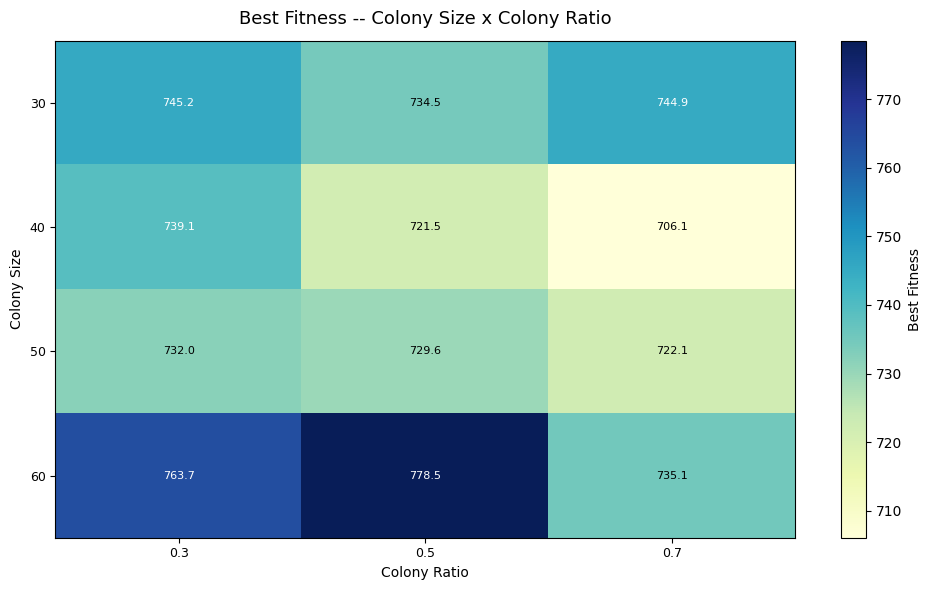

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\ABC_test_results\heatmap_size_ratio.png


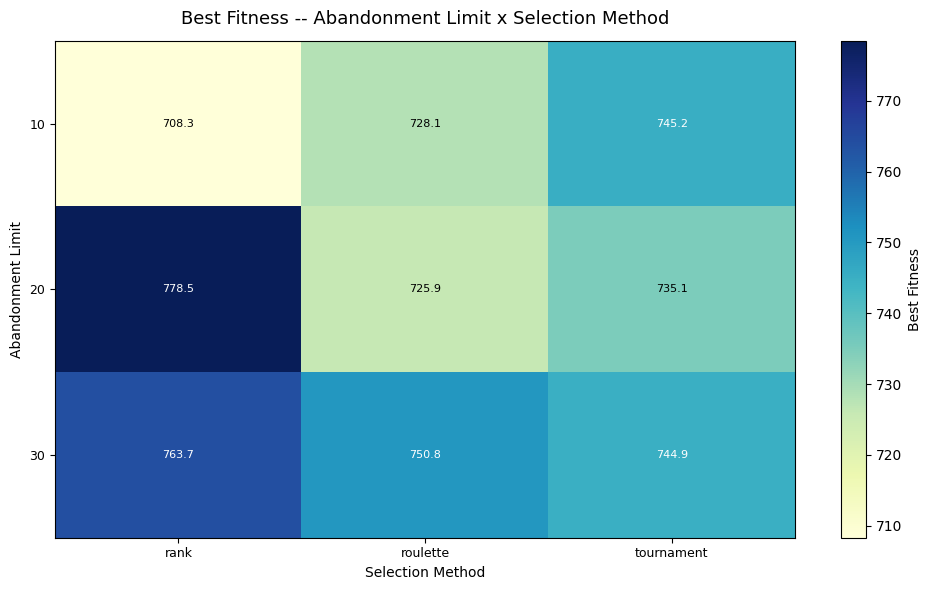

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\ABC_test_results\heatmap_limit_selection.png


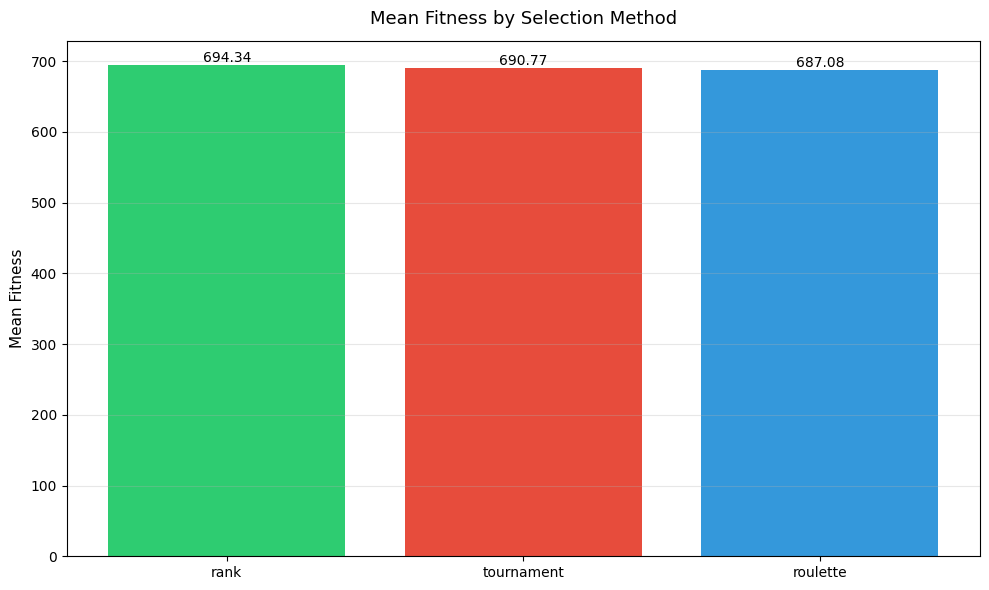

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\ABC_test_results\bar_selection_mean.png


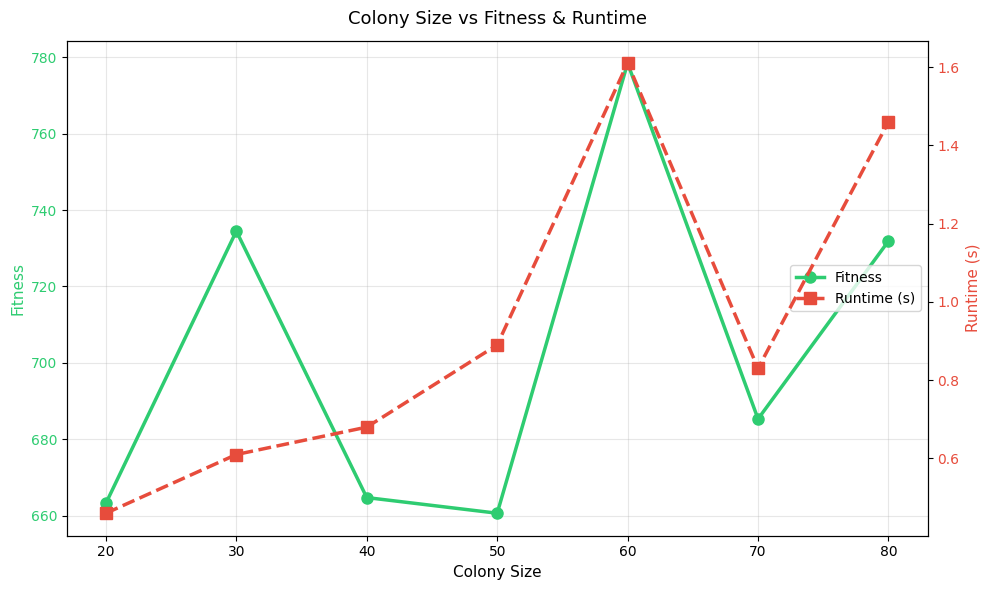

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\ABC_test_results\colony_size_sweep.png


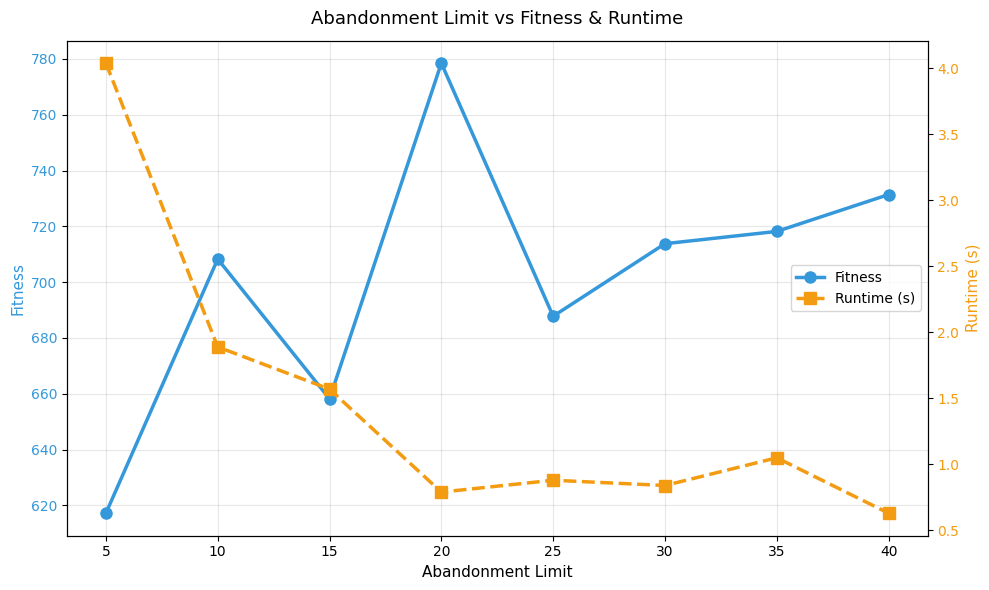

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\ABC_test_results\limit_sweep.png


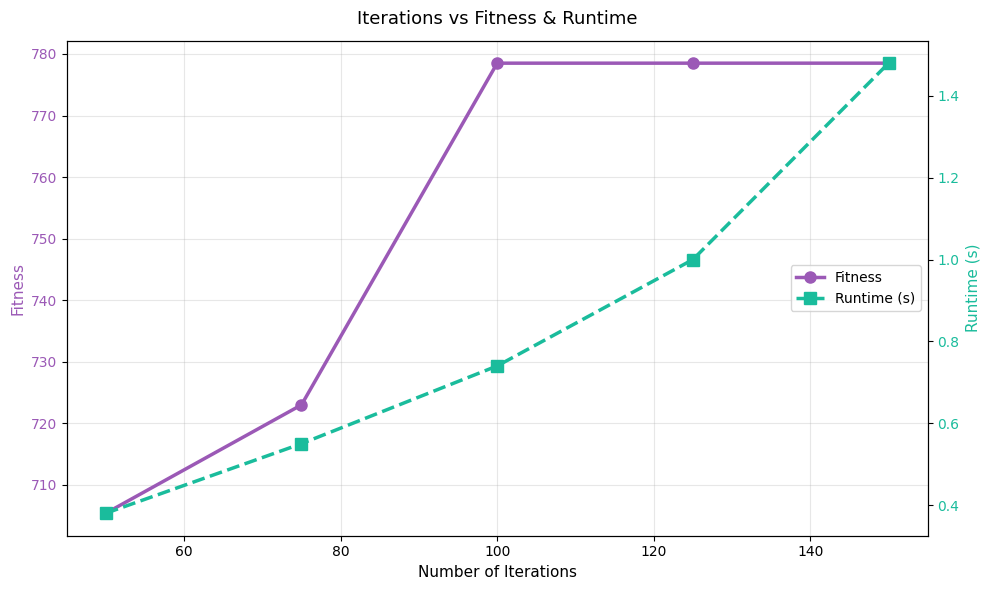

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\ABC_test_results\iterations_sweep.png


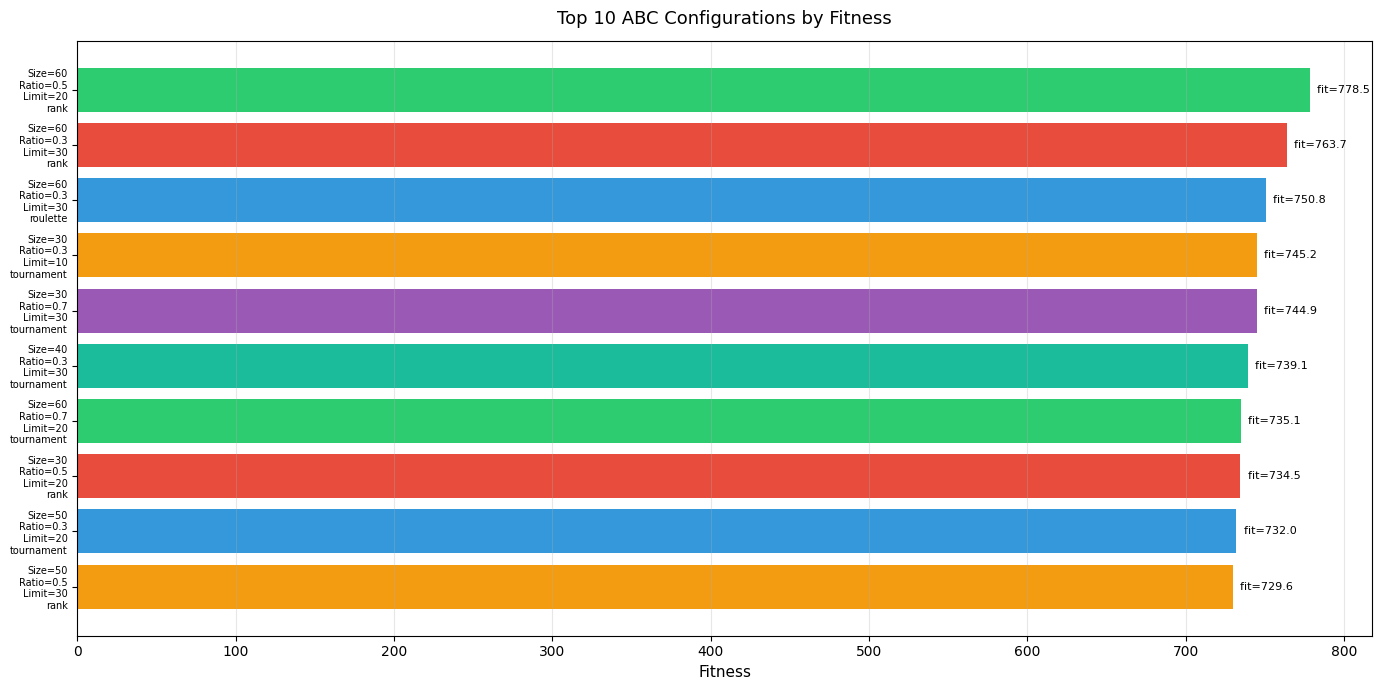

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\ABC_test_results\top10_configs.png


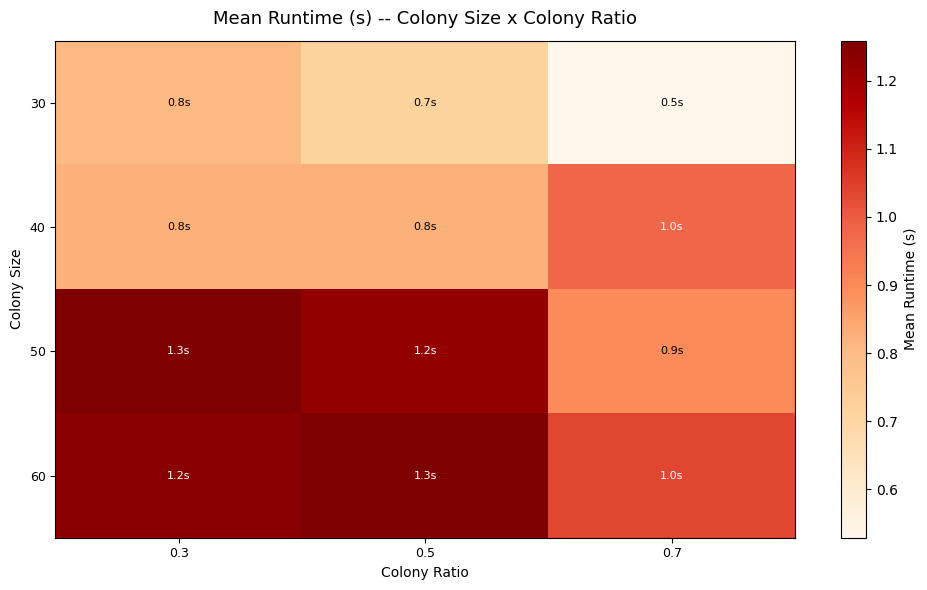

  [OK] c:\Users\LKTech\Desktop\Intro_to_AI_project\Tests\ABC_test_results\heatmap_runtime.png

SUMMARY -- Top 15 Configurations (by Fitness)
 ColonySize  ColonyRatio  Limit  Selection  Fitness  Interest  TotalTime_h  NumLandmarks  Runtime_s
         60          0.5     20       rank    778.5     118.7         7.96            15       0.72
         60          0.3     30       rank    763.7     117.0         7.84            15       1.01
         60          0.3     30   roulette    750.8     113.7         7.75            14       1.03
         30          0.3     10 tournament    745.2     115.1         7.76            15       1.15
         30          0.7     30 tournament    744.9     113.8         7.94            15       0.31
         40          0.3     30 tournament    739.1     112.0         7.83            14       0.43
         60          0.7     20 tournament    735.1     112.7         7.65            14       0.75
         30          0.5     20       rank    734.5     111

In [18]:
%matplotlib inline


import sys, os, random, time, itertools
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# ── project imports ──────────────────────────────────────────────────────────

# ── data loading ─────────────────────────────────────────────────────────────
landmarks = get_landmarks()
hotels     = get_hotels()
time_matrix = get_time_matrix()

# ── problem setup ─────────────────────────────────────────────────────────────
problem = TravelProblem_LocalSearch(
    landmarks,
    travel_information={
        'hotel': hotels[0],
        'time_matrix': time_matrix,
        'Travel_Time': 8,
        'Travel_day': 'fri',
        'type_filter': None,
        'trip_start_time': 9,
    },
)

# ── parameters ───────────────────────────────────────────────────────────
Colony_sizes     = [30, 40, 50, 60]
Colony_ratios    = [0.3, 0.5, 0.7]
Abandonment_limits = [10, 20, 30]
Selection_methods = ['roulette', 'tournament', 'rank']
Iterations_values = [50, 75, 100, 125, 150]

SEED = 42

# ── output directory ─────────────────────────────────────────────────────────
OUTPUT_DIR = os.path.join(os.getcwd(), "Tests", "ABC_test_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ═════════════════════════════════════════════════════════════════════════════
# 1.  Full factorial test (colony_size × colony_ratio × limit × selection)
#     Using fixed iterations=100
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 1 -- Full Factorial: Colony Params x Selection Method")
print("         (iterations=100)")
print("=" * 70)

rows_factorial = []
total_combos = len(Colony_sizes) * len(Colony_ratios) * len(Abandonment_limits) * len(Selection_methods)
combo_idx = 0

for size, ratio, limit, sel in itertools.product(Colony_sizes, Colony_ratios, Abandonment_limits, Selection_methods):
    combo_idx += 1
    random.seed(SEED)
    abc = ABC_Optimization(
        problem,
        colony_size=size,
        colony_ratio=ratio,
        limit=limit,
        iterations=100,
        selection_method=sel,
    )
    t0 = time.time()
    best_state, fitness = abc.solve()
    elapsed = time.time() - t0
    interest = sum(lm.interest_score for lm in best_state)
    tot_time = round(abc.calculate_total_time(best_state), 2)
    n_lm = len(best_state)
    
    rows_factorial.append({
        'ColonySize': size,
        'ColonyRatio': ratio,
        'Limit': limit,
        'Selection': sel,
        'Fitness': round(fitness, 4),
        'Interest': round(interest, 2),
        'TotalTime_h': tot_time,
        'NumLandmarks': n_lm,
        'Runtime_s': round(elapsed, 2),
    })
    print(f"  [{combo_idx:3d}/{total_combos}]  size={size:2d} ratio={ratio:.1f} limit={limit:2d} sel={sel:11s}"
          f"  ->  fit={fitness:7.2f} time={tot_time:5.2f}h  #lm={n_lm}  ({elapsed:.1f}s)")

df_factorial = pd.DataFrame(rows_factorial)
csv_path = os.path.join(OUTPUT_DIR, "factorial_results.csv")
df_factorial.to_csv(csv_path, index=False)
print(f"\n[OK] Factorial results saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 2.  Colony size sweep (best combo from phase 1)
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 2 -- Colony Size Sweep")
print("=" * 70)

best_row = df_factorial.loc[df_factorial['Fitness'].idxmax()]
best_size, best_ratio, best_limit, best_sel = (
    best_row['ColonySize'], best_row['ColonyRatio'], best_row['Limit'], best_row['Selection']
)
print(f"  Using best combo: size={best_size} ratio={best_ratio} limit={best_limit} sel={best_sel}")

rows_size = []
for size in [20, 30, 40, 50, 60, 70, 80]:
    random.seed(SEED)
    abc = ABC_Optimization(
        problem,
        colony_size=size,
        colony_ratio=best_ratio,
        limit=best_limit,
        iterations=100,
        selection_method=best_sel,
    )
    t0 = time.time()
    best_state, fitness = abc.solve()
    elapsed = time.time() - t0
    interest = sum(lm.interest_score for lm in best_state)
    tot_time = round(abc.calculate_total_time(best_state), 2)
    n_lm = len(best_state)
    
    rows_size.append({
        'ColonySize': size,
        'Fitness': round(fitness, 4),
        'Interest': round(interest, 2),
        'TotalTime_h': tot_time,
        'NumLandmarks': n_lm,
        'Runtime_s': round(elapsed, 2),
    })
    print(f"  size={size:2d}  ->  fit={fitness:7.2f} time={tot_time:5.2f}h  #lm={n_lm}  ({elapsed:.1f}s)")

df_size = pd.DataFrame(rows_size)
csv_path = os.path.join(OUTPUT_DIR, "colony_size_sweep.csv")
df_size.to_csv(csv_path, index=False)
print(f"  [OK] saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 3.  Abandonment limit sweep
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 3 -- Abandonment Limit Sweep")
print("=" * 70)

rows_limit = []
for limit in [5, 10, 15, 20, 25, 30, 35, 40]:
    random.seed(SEED)
    abc = ABC_Optimization(
        problem,
        colony_size=best_size,
        colony_ratio=best_ratio,
        limit=limit,
        iterations=100,
        selection_method=best_sel,
    )
    t0 = time.time()
    best_state, fitness = abc.solve()
    elapsed = time.time() - t0
    interest = sum(lm.interest_score for lm in best_state)
    tot_time = round(abc.calculate_total_time(best_state), 2)
    n_lm = len(best_state)
    
    rows_limit.append({
        'Limit': limit,
        'Fitness': round(fitness, 4),
        'Interest': round(interest, 2),
        'TotalTime_h': tot_time,
        'NumLandmarks': n_lm,
        'Runtime_s': round(elapsed, 2),
    })
    print(f"  limit={limit:2d}  ->  fit={fitness:7.2f} time={tot_time:5.2f}h  #lm={n_lm}  ({elapsed:.1f}s)")

df_limit = pd.DataFrame(rows_limit)
csv_path = os.path.join(OUTPUT_DIR, "limit_sweep.csv")
df_limit.to_csv(csv_path, index=False)
print(f"  [OK] saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 4.  Iterations sweep
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 4 -- Iterations Sweep")
print("=" * 70)

rows_iter = []
for iters in Iterations_values:
    random.seed(SEED)
    abc = ABC_Optimization(
        problem,
        colony_size=best_size,
        colony_ratio=best_ratio,
        limit=best_limit,
        iterations=iters,
        selection_method=best_sel,
    )
    t0 = time.time()
    best_state, fitness = abc.solve()
    elapsed = time.time() - t0
    interest = sum(lm.interest_score for lm in best_state)
    tot_time = round(abc.calculate_total_time(best_state), 2)
    n_lm = len(best_state)
    
    rows_iter.append({
        'Iterations': iters,
        'Fitness': round(fitness, 4),
        'Interest': round(interest, 2),
        'TotalTime_h': tot_time,
        'NumLandmarks': n_lm,
        'Runtime_s': round(elapsed, 2),
    })
    print(f"  iter={iters:3d}  ->  fit={fitness:7.2f} time={tot_time:5.2f}h  #lm={n_lm}  ({elapsed:.1f}s)")

df_iter = pd.DataFrame(rows_iter)
csv_path = os.path.join(OUTPUT_DIR, "iterations_sweep.csv")
df_iter.to_csv(csv_path, index=False)
print(f"  [OK] saved -> {csv_path}")

# ═════════════════════════════════════════════════════════════════════════════
# 5.  PLOTS
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PHASE 5 -- Generating Plots")
print("=" * 70)

COLORS = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

# ---------- Plot 1: Heatmap - Colony Size vs Ratio (Fitness) ----------
fig, ax = plt.subplots(figsize=(10, 6))
pivot = df_factorial.groupby(['ColonySize', 'ColonyRatio'])['Fitness'].max().unstack()
im = ax.imshow(pivot.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{x:.1f}' for x in pivot.columns], fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8,
                color='white' if val > pivot.values.mean() else 'black')
fig.colorbar(im, ax=ax, label='Best Fitness')
ax.set_title('Best Fitness -- Colony Size x Colony Ratio', fontsize=13, pad=12)
ax.set_xlabel('Colony Ratio')
ax.set_ylabel('Colony Size')
plt.tight_layout()
path1 = os.path.join(OUTPUT_DIR, "heatmap_size_ratio.png")
fig.savefig(path1, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path1}")

# ---------- Plot 2: Heatmap - Limit vs Selection (Fitness) ----------
fig, ax = plt.subplots(figsize=(10, 6))
pivot_limit = df_factorial.groupby(['Limit', 'Selection'])['Fitness'].max().unstack()
im = ax.imshow(pivot_limit.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(pivot_limit.columns)))
ax.set_xticklabels(pivot_limit.columns, fontsize=9)
ax.set_yticks(range(len(pivot_limit.index)))
ax.set_yticklabels(pivot_limit.index, fontsize=9)
for i in range(len(pivot_limit.index)):
    for j in range(len(pivot_limit.columns)):
        val = pivot_limit.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8,
                color='white' if val > pivot_limit.values.mean() else 'black')
fig.colorbar(im, ax=ax, label='Best Fitness')
ax.set_title('Best Fitness -- Abandonment Limit x Selection Method', fontsize=13, pad=12)
ax.set_xlabel('Selection Method')
ax.set_ylabel('Abandonment Limit')
plt.tight_layout()
path2 = os.path.join(OUTPUT_DIR, "heatmap_limit_selection.png")
fig.savefig(path2, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path2}")

# ---------- Plot 3: Mean Fitness by Selection Method ----------
fig, ax = plt.subplots(figsize=(10, 6))
sel_mean = df_factorial.groupby('Selection')['Fitness'].mean().sort_values(ascending=False)
bars = ax.bar(sel_mean.index, sel_mean.values, color=COLORS[:len(sel_mean)])
ax.set_ylabel('Mean Fitness', fontsize=11)
ax.set_title('Mean Fitness by Selection Method', fontsize=13, pad=12)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, sel_mean.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
path3 = os.path.join(OUTPUT_DIR, "bar_selection_mean.png")
fig.savefig(path3, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path3}")

# ---------- Plot 4: Colony Size Sweep - Line Chart ----------
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(df_size['ColonySize'], df_size['Fitness'], 'o-', color='#2ecc71', linewidth=2.5, markersize=8, label='Fitness')
ax1.set_xlabel('Colony Size', fontsize=11)
ax1.set_ylabel('Fitness', color='#2ecc71', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#2ecc71')

ax2 = ax1.twinx()
ax2.plot(df_size['ColonySize'], df_size['Runtime_s'], 's--', color='#e74c3c', linewidth=2.5, markersize=8, label='Runtime (s)')
ax2.set_ylabel('Runtime (s)', color='#e74c3c', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.set_title('Colony Size vs Fitness & Runtime', fontsize=13, pad=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
ax1.grid(alpha=0.3)
plt.tight_layout()
path4 = os.path.join(OUTPUT_DIR, "colony_size_sweep.png")
fig.savefig(path4, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path4}")

# ---------- Plot 5: Abandonment Limit Sweep - Line Chart ----------
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(df_limit['Limit'], df_limit['Fitness'], 'o-', color='#3498db', linewidth=2.5, markersize=8, label='Fitness')
ax1.set_xlabel('Abandonment Limit', fontsize=11)
ax1.set_ylabel('Fitness', color='#3498db', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.plot(df_limit['Limit'], df_limit['Runtime_s'], 's--', color='#f39c12', linewidth=2.5, markersize=8, label='Runtime (s)')
ax2.set_ylabel('Runtime (s)', color='#f39c12', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#f39c12')

ax1.set_title('Abandonment Limit vs Fitness & Runtime', fontsize=13, pad=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
ax1.grid(alpha=0.3)
plt.tight_layout()
path5 = os.path.join(OUTPUT_DIR, "limit_sweep.png")
fig.savefig(path5, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path5}")

# ---------- Plot 6: Iterations Sweep - Line Chart ----------
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(df_iter['Iterations'], df_iter['Fitness'], 'o-', color='#9b59b6', linewidth=2.5, markersize=8, label='Fitness')
ax1.set_xlabel('Number of Iterations', fontsize=11)
ax1.set_ylabel('Fitness', color='#9b59b6', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#9b59b6')

ax2 = ax1.twinx()
ax2.plot(df_iter['Iterations'], df_iter['Runtime_s'], 's--', color='#1abc9c', linewidth=2.5, markersize=8, label='Runtime (s)')
ax2.set_ylabel('Runtime (s)', color='#1abc9c', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#1abc9c')

ax1.set_title('Iterations vs Fitness & Runtime', fontsize=13, pad=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
ax1.grid(alpha=0.3)
plt.tight_layout()
path6 = os.path.join(OUTPUT_DIR, "iterations_sweep.png")
fig.savefig(path6, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path6}")

# ---------- Plot 7: Top 10 best configurations ----------
top10 = df_factorial.nlargest(10, 'Fitness')
fig, ax = plt.subplots(figsize=(14, 7))
labels_top = [f"Size={int(r['ColonySize'])}\nRatio={r['ColonyRatio']:.1f}\nLimit={int(r['Limit'])}\n{r['Selection']}" 
              for _, r in top10.iterrows()]
bars = ax.barh(range(len(top10)), top10['Fitness'], color=COLORS * 2)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(labels_top, fontsize=7)
ax.set_xlabel('Fitness', fontsize=11)
ax.set_title('Top 10 ABC Configurations by Fitness', fontsize=13, pad=12)
for i, (val, interest) in enumerate(zip(top10['Fitness'], top10['Interest'])):
    ax.text(val + 0.1, i, f'  fit={val:.1f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
path7 = os.path.join(OUTPUT_DIR, "top10_configs.png")
fig.savefig(path7, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path7}")

# ---------- Plot 8: Runtime Heatmap - Colony Size vs Ratio ----------
fig, ax = plt.subplots(figsize=(10, 6))
pivot_rt = df_factorial.groupby(['ColonySize', 'ColonyRatio'])['Runtime_s'].mean().unstack()
im = ax.imshow(pivot_rt.values, cmap='OrRd', aspect='auto')
ax.set_xticks(range(len(pivot_rt.columns)))
ax.set_xticklabels([f'{x:.1f}' for x in pivot_rt.columns], fontsize=9)
ax.set_yticks(range(len(pivot_rt.index)))
ax.set_yticklabels(pivot_rt.index, fontsize=9)
for i in range(len(pivot_rt.index)):
    for j in range(len(pivot_rt.columns)):
        val = pivot_rt.values[i, j]
        ax.text(j, i, f'{val:.1f}s', ha='center', va='center', fontsize=8,
                color='white' if val > pivot_rt.values.mean() else 'black')
fig.colorbar(im, ax=ax, label='Mean Runtime (s)')
ax.set_title('Mean Runtime (s) -- Colony Size x Colony Ratio', fontsize=13, pad=12)
ax.set_xlabel('Colony Ratio')
ax.set_ylabel('Colony Size')
plt.tight_layout()
path8 = os.path.join(OUTPUT_DIR, "heatmap_runtime.png")
fig.savefig(path8, dpi=150)
plt.show()
plt.close(fig)
print(f"  [OK] {path8}")

# ═════════════════════════════════════════════════════════════════════════════
# 6.  SUMMARY TABLE (printed to console)
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("SUMMARY -- Top 15 Configurations (by Fitness)")
print("=" * 70)
top15 = df_factorial.nlargest(15, 'Fitness')
print(top15.to_string(index=False))

print("\n" + "=" * 70)
print("Colony Size Sweep Results")
print("=" * 70)
print(df_size.to_string(index=False))

print("\n" + "=" * 70)
print("Abandonment Limit Sweep Results")
print("=" * 70)
print(df_limit.to_string(index=False))

print("\n" + "=" * 70)
print("Iterations Sweep Results")
print("=" * 70)
print(df_iter.to_string(index=False))

print("\n[DONE] All done! Results & plots saved in:", OUTPUT_DIR)


---
# **SECTION 6 - Comparison and Final Results**


## 6.0 - Best Parameters values for each algorithm

initialize object from each algorithm with the best combinations that we find in testing phase 

In [ ]:
# you should intilize travel info to work with 
travel_info = {

}

landmarks = get_landmarks()
hotels = get_hotels()
time_matrix = get_time_matrix()


In [ ]:

local_search_problem = TravelProblem_LocalSearch(landmarks, travel_info)

env = ACSEnvironment( hotel=travel_info.selected_hotel, 
                landmarks=travel_info.landmarks, 
                time_matrix= time_matrix, 
                time_budget_hours=travel_info.time_budget_hours, 
                trip_start_time_hours=travel_info.trip_start_time, 
                visiting_day=travel_info.visiting_day
            )
           

In [ ]:
sa = Simulated_Annealing(local_search_problem, initial_temp=300, cooling_rate=0.99, max_reheats=1)    #  by sa.run()

acs = AntColonySystem(env, num_ants=50, generations=100, alpha=0.5, beta=3.0, rho=0.05)    # acs.solve()

acs_hybrid = AntColonySystem(env,  num_ants=50, generations=100, alpha=0.5,beta=3.0, rho=0.3  ,hybrid_sa=True  )   # acs_hybrid.solve()

## 6.1 - Comparison 

In [ ]:
# TODO

## 5.2 - All Visualizations

## 6.3 - Conclusions

---
# **SECTION 7 - Final Code to Integrate with the APP**


should contains all options from each algorithm ... , to be discussed later